In [1]:
import matplotlib as mpl

# Increase global text/tick/legend sizing for all plots
mpl.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

  IC3392: 27159 valid spaxels (flux+SFR+EW mask)
  NGC4064: 50910 valid spaxels (flux+SFR+EW mask)
  NGC4192: 405348 valid spaxels (flux+SFR+EW mask)
  NGC4293: 66563 valid spaxels (flux+SFR+EW mask)
  NGC4298: 213272 valid spaxels (flux+SFR+EW mask)
  NGC4330: 76190 valid spaxels (flux+SFR+EW mask)
  NGC4383: 123180 valid spaxels (flux+SFR+EW mask)
  NGC4396: 143503 valid spaxels (flux+SFR+EW mask)
  NGC4419: 82764 valid spaxels (flux+SFR+EW mask)
  NGC4457: 145713 valid spaxels (flux+SFR+EW mask)
  NGC4501: 524403 valid spaxels (flux+SFR+EW mask)
  NGC4522: 71660 valid spaxels (flux+SFR+EW mask)
  NGC4694: 30644 valid spaxels (flux+SFR+EW mask)
  NGC4698: 133041 valid spaxels (flux+SFR+EW mask)

Total combined valid spaxels (flux+SFR+EW mask): 2094350

SFR component counts (finite spaxels, all galaxies combined):
  HII: 841242 (39.886%)
  NONHII: 672736 (31.896%)
  UNCLASSIFIED2: 595152 (28.218%)

SF component counts (finite spaxels, all galaxies combined):
  SF: 1138391 (53.974%)
  

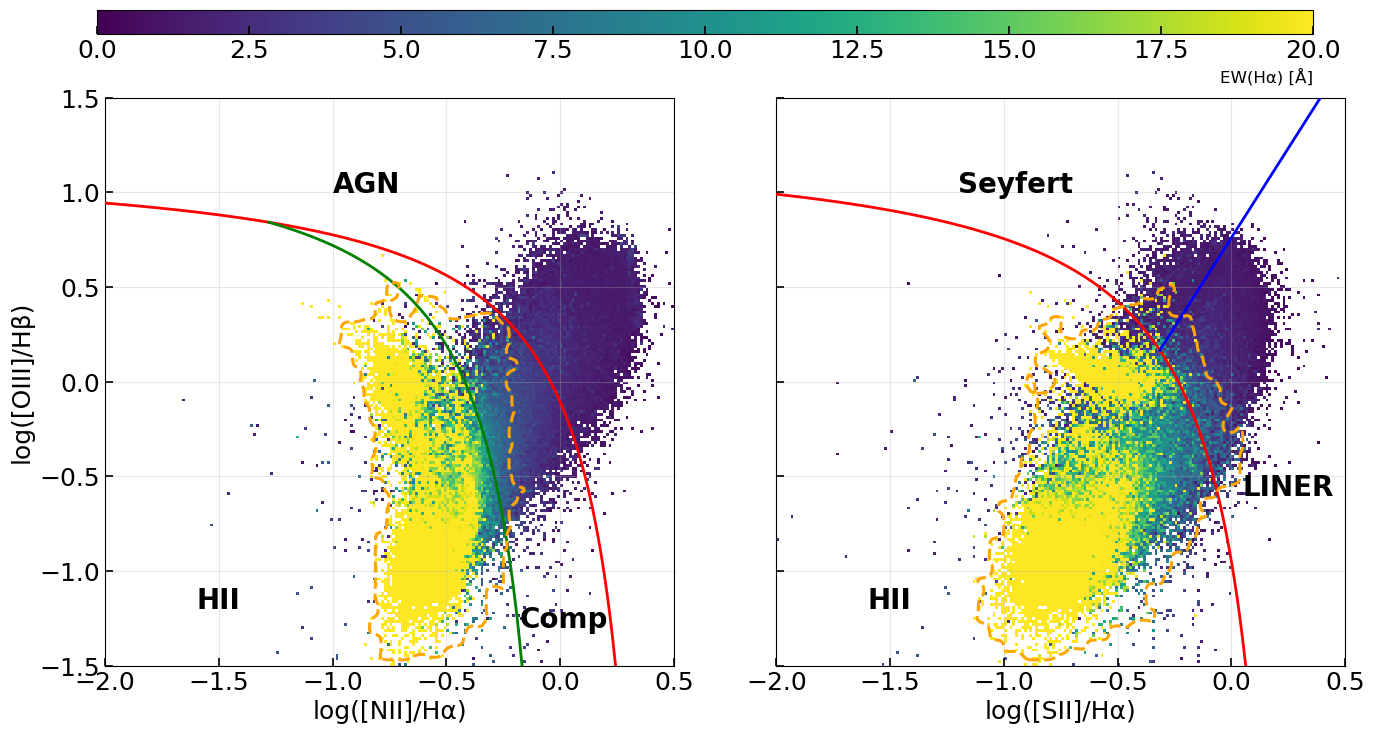


Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Orange dashed contour marks boundary of EW(Hα) > 6 Å


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color by EW(Halpha)
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import binary_closing, binary_fill_holes, gaussian_filter, label


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Error propagation for BPT ratios (log10 numerator/denominator)
def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
        return log_ratio_err


def plot_closed_ew_boundary(ax, ew_grid, xedges, yedges, ew_threshold):
    finite_mask = np.isfinite(ew_grid)
    if not np.any(finite_mask):
        return

    gt_mask = finite_mask & (ew_grid > ew_threshold)
    if np.count_nonzero(gt_mask) < 10:
        return

    # Clean up isolated cells and fill small holes to form a closed boundary.
    cleaned = binary_closing(gt_mask, structure=np.ones((3, 3), dtype=bool), iterations=2)
    cleaned = binary_fill_holes(cleaned)

    labeled, n_regions = label(cleaned)
    if n_regions == 0:
        return

    region_sizes = np.bincount(labeled.ravel())
    region_sizes[0] = 0
    largest_region = labeled == np.argmax(region_sizes)

    smooth_region = gaussian_filter(largest_region.astype(float), sigma=1.2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        smooth_region.T,
        levels=[0.5],
        colors='orange',
        linestyles='--',
        linewidths=2.2,
        zorder=11,
    )


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_CONTOUR = 6.0


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_ew = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if gas_file.exists() and bin_file.exists() and ew_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
            HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
            OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
            NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
            SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
            SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
            logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
            logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
            logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data

        with fits.open(ew_file) as h_ew:
            if EW_HDU not in h_ew:
                print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                continue
            ew_ha = h_ew[EW_HDU].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            print(f'  {gal}: shape mismatch EW {ew_ha.shape} vs gas {HA6562_FLUX_corr.shape}')
            continue

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
            np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
            np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
            np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
            np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
            np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # EW mask
        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask & ew_mask
        n_pixels = np.sum(valid_mask)
        print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())
        all_ew.extend(EW_common.flatten())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
            np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
            np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
            np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
            np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
            np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not bin_file.exists():
            missing_parts.append(bin_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_ew = np.array(all_ew)

if len(all_logN2) == 0:
    raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
if len(all_ew) != len(all_logN2):
    raise RuntimeError('EW array length mismatch with BPT arrays.')

# Report SFR component stats
print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
if count_union > 0:
    print('\nSFR component counts (finite spaxels, all galaxies combined):')
    print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
    print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

if count_union > 0:
    print('\nSF component counts (finite spaxels, all galaxies combined):')
    print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
    print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
    print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
    print(f'  Max |Δ|: {max_abs_diff:.3e}')

# Mean log-errors for requested subsets

def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan

print('\nMean log-error (spaxel subsets):')
print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

# Create diagrams for all spaxels (2D EW color)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

# Binning and ranges
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3
vmin_ew = 0.0
vmax_ew = 20.0

# NII panel EW grid
hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_N2, _, _ = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_N2 = np.divide(
    sum_ew_N2,
    hist_N2,
    out=np.full_like(sum_ew_N2, np.nan, dtype=float),
    where=hist_N2 > 0,
)
mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

# SII panel EW grid
hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_S2, _, _ = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_S2 = np.divide(
    sum_ew_S2,
    hist_S2,
    out=np.full_like(sum_ew_S2, np.nan, dtype=float),
    where=hist_S2 > 0,
)
mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

# NII diagram
ax = axes[0]
img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_invalid(mean_ew_N2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_N2, xedges_N2, yedges_N2, EW_CONTOUR)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_invalid(mean_ew_S2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_S2, xedges_S2, yedges_S2, EW_CONTOUR)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# Shared colorbar (top, spanning both panels)
cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal')
cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
cbar.ax.tick_params(labelsize=18)

# Save figures
output_dir = Path('Plot_Paper_1_referee')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
plt.show()

print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
print('Galaxies included: ' + ', '.join(galaxies))
print(f'Orange dashed contour marks boundary of EW(Hα) > {EW_CONTOUR:g} Å')

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): NGC4396, NGC4501
Galaxies used in this analysis: NGC4396, NGC4501

Processing NGC4396 ...
  Σ* range (95%): 6.908 to 7.826
  Global Δlog(Σ_SFR) axis limits: ±0.979
  Global Δ[O/H] axis limits: ±0.079
  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):
    Bin 01 (7.06): n=76823, r=-0.381 (p=0)
    Bin 02 (7.37): n=29604, r=-0.186 (p=4.38e-229)
    Bin 03 (7.67): n=11433, r=-0.004 (p=0.705)

Processing NGC4501 ...
  Σ* range (95%): 7.766 to 8.941
  Global Δlog(Σ_SFR) axis limits: ±1.182
  Global Δ[O/H] axis limits: ±0.141
  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):
    Bin 01 (7.86): n=43659, r=0.440 (p=0)
    Bin 02 (8.06): n=67069, r=0.568 (p=0)
    Bin 03 (8.26): n=59356, r=0.518 (p=0)
    Bin 04 (8.45): n=45566, r=0.679 (p=0)
    Bin 05 (8.65): n=40673, r=0.468 (p=0)
    Bin 06 (8.84): n=28623, r=0.395 (p=0)

Summary: number of Σ_* bi

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32712/2310984408.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


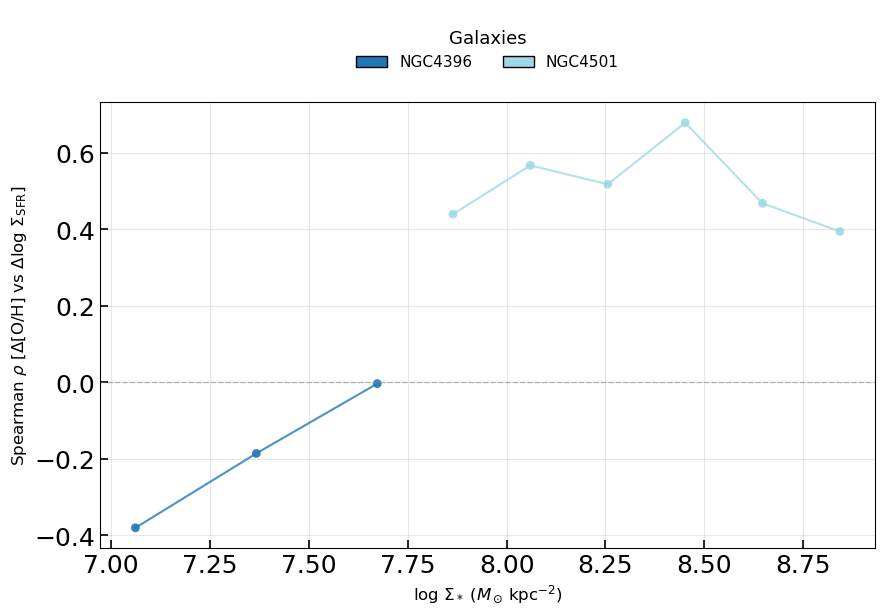

In [3]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'SNR200/{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'SNR200/{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('SNR200/').glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 3 if gal == 'NGC4396' else 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using all valid points (per galaxy)
    print("  Spearman rho in each Σ_* bin (no 3σ clip, no trend gate, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # Spearman rho from all valid points in this Σ_* bin (no trend gate)
        x_corr = sfr_offset[valid_corr]
        y_corr = oh_offset[valid_corr]

        if np.unique(x_corr).size < 2 or np.unique(y_corr).size < 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient dynamic range)")
        else:
            try:
                spearman_rho, spearman_p = spearmanr(x_corr, y_corr)
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        x_corr_g = sfr_off_g[valid_corr_g]
        y_corr_g = oh_off_g[valid_corr_g]

        if np.unique(x_corr_g).size < 2 or np.unique(y_corr_g).size < 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient dynamic range)")
            continue

        try:
            rho_g, p_g = spearmanr(x_corr_g, y_corr_g)
            global_bin_centers.append(sigmaM_centers_g[i])
            global_rho_values.append(rho_g)
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
        except Exception:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Skip only empty series; keep single-point series as scatter
        if len(x_vals) == 0:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        if len(x_sorted) > 1:
            ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SpearmanRho_vs_SigmaM_SNR200.png',
                dpi=600, bbox_inches='tight')
    plt.savefig('Plot_Paper_1_referee/MAUVE_MUSE_SpearmanRho_vs_SigmaM_SNR200.pdf',
                bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

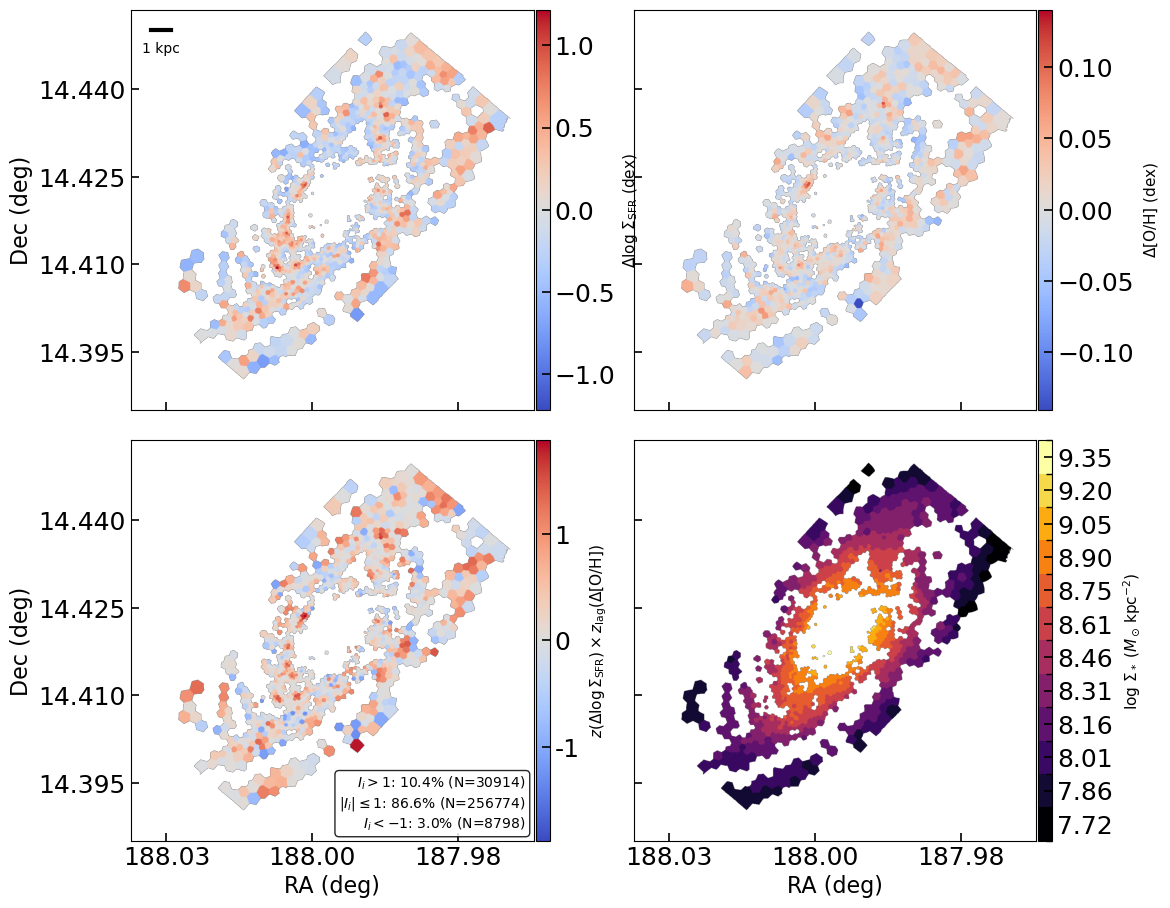

In [4]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'SNR200/{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'SNR200/{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

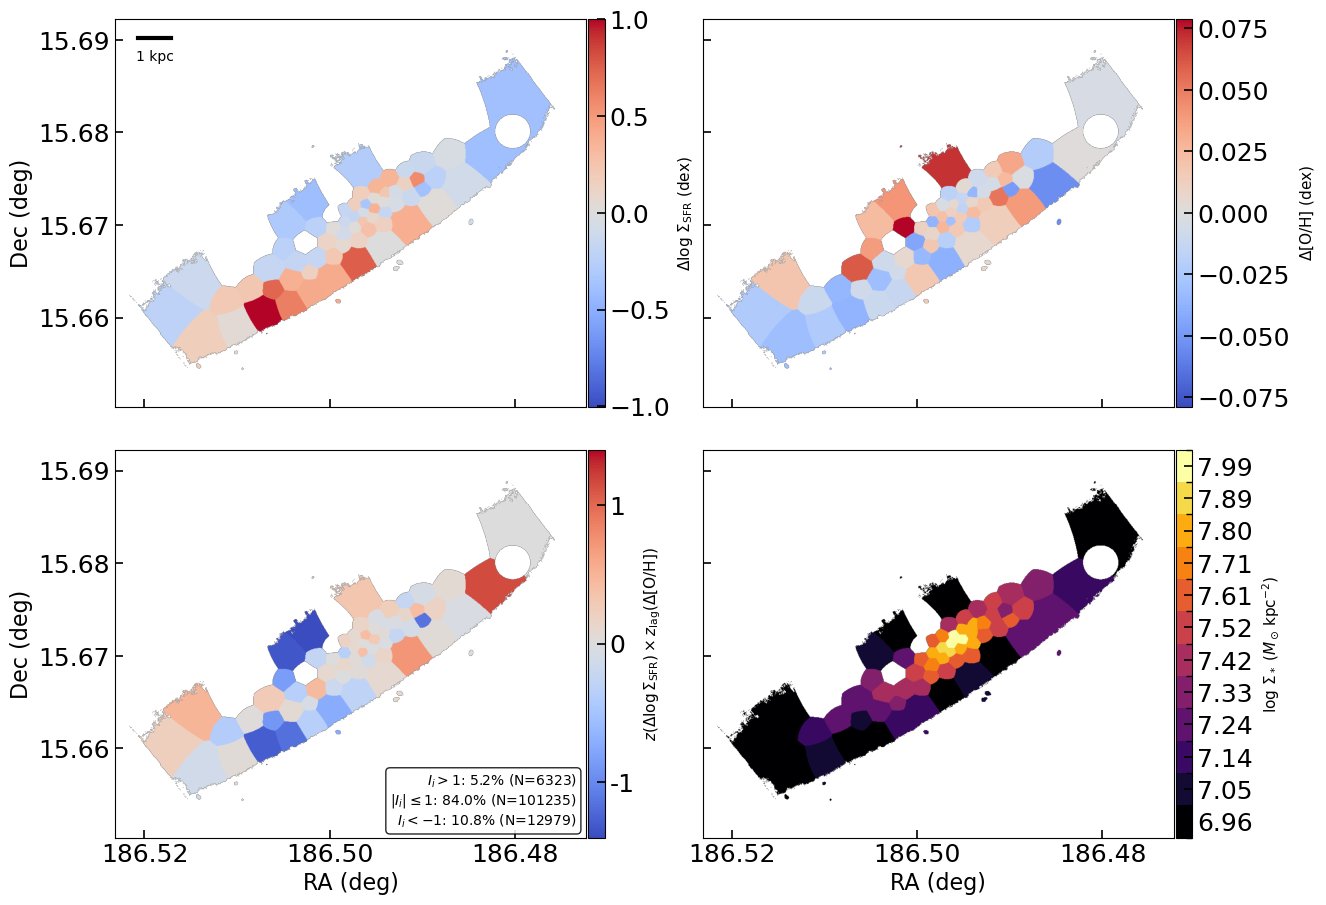

In [5]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'SNR200/{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    gas_path = f'SNR200/{gal}_v3tk_SNR200_gas_bin_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f'Plot_Paper_1_referee/{gal}_v3tk_SNR200_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

Loaded MAUVE integrated properties from mauve_master_wiki.fits:
  IC3392: logM*=9.824 [mauve_master_wiki.fits]; logSFR=-0.986 [mauve_master_wiki.fits]
  NGC4064: logM*=10.046 [mauve_master_wiki.fits]; logSFR=-0.494 [mauve_master_wiki.fits]
  NGC4192: logM*=10.764 [mauve_master_wiki.fits]; logSFR=0.114 [mauve_master_wiki.fits]
  NGC4293: logM*=10.527 [mauve_master_wiki.fits]; logSFR=-0.243 [mauve_master_wiki.fits]
  NGC4298: logM*=10.094 [mauve_master_wiki.fits]; logSFR=-0.276 [mauve_master_wiki.fits]
  NGC4330: logM*=9.614 [mauve_master_wiki.fits]; logSFR=-0.856 [mauve_master_wiki.fits]
  NGC4383: logM*=9.424 [mauve_master_wiki.fits]; logSFR=-0.006 [mauve_master_wiki.fits]
  NGC4396: logM*=9.344 [mauve_master_wiki.fits]; logSFR=-0.686 [mauve_master_wiki.fits]
  NGC4419: logM*=10.234 [mauve_master_wiki.fits]; logSFR=0.054 [mauve_master_wiki.fits]
  NGC4457: logM*=10.469 [mauve_master_wiki.fits]; logSFR=-0.441 [mauve_master_wiki.fits]
  NGC4501: logM*=10.984 [mauve_master_wiki.fits]; log

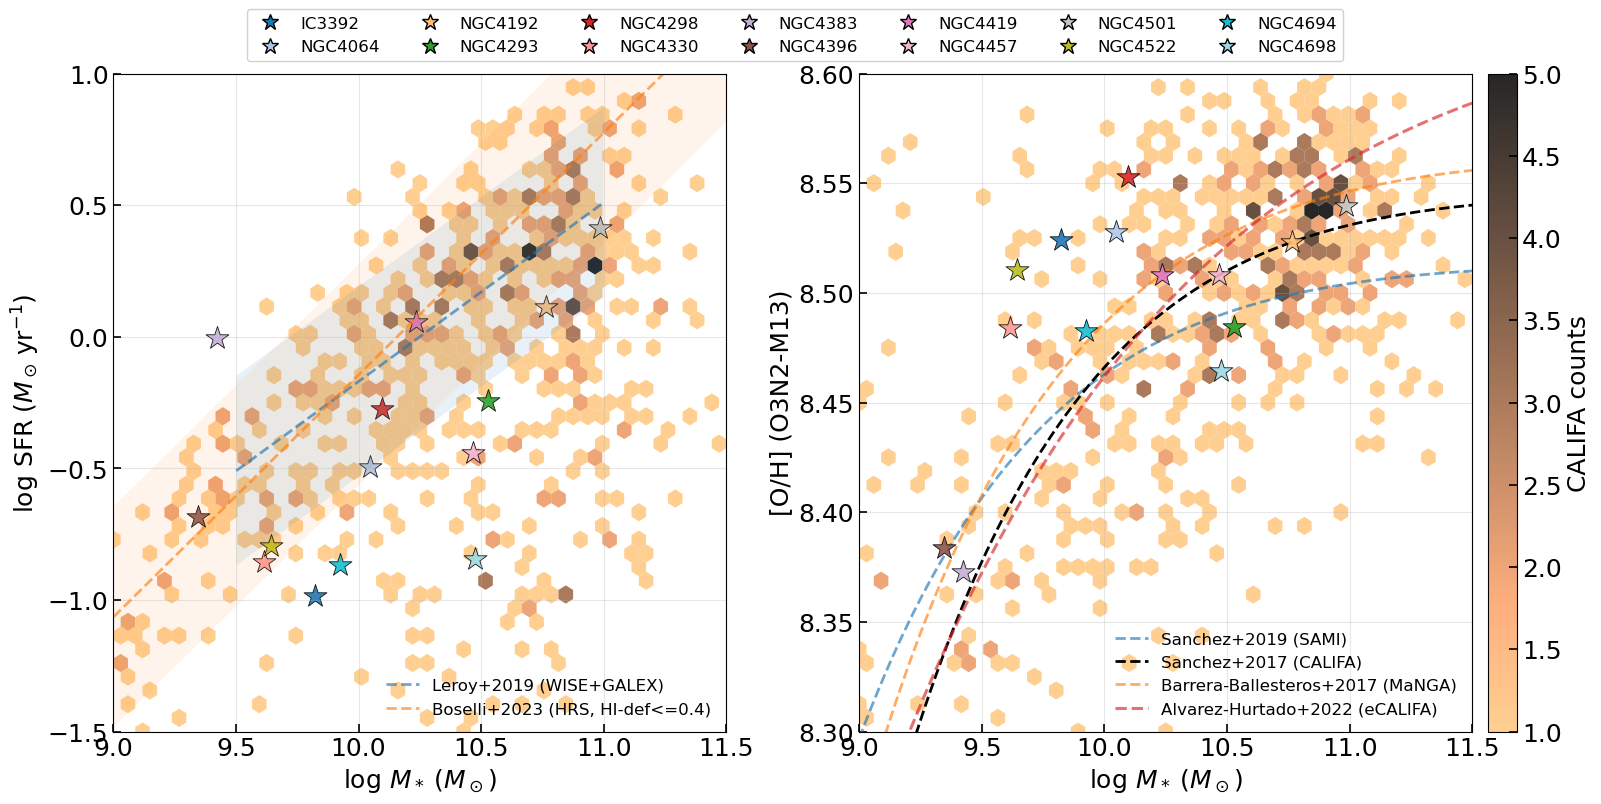

Subplot 1 (Integrated SFMS): Plotted 14 galaxies with valid total mass and SFR data
Subplot 2 (Integrated MZR, O3N2-M13 total region): Plotted 14 galaxies with valid total mass and total-region metallicity data


In [6]:
# ------------------------------------------------------------------
# Combined Plot: Integrated SFMS + Integrated MZR (O3N2-M13 total region)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from mauve_master_loader import load_mauve_master_properties
import re


# ------------------------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits at runtime.
# ------------------------------------------------------------------

GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]

MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")
CALIFA_TABLE_PATH = Path("Sanchez2017TableB1.csv")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


def parse_float(token):
    token = token.strip()
    if token == "":
        return None
    try:
        return float(token)
    except ValueError:
        return None


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


print(f"Loaded MAUVE integrated properties from {MASTER_SAMPLE_PATH}:")
for gal in GALAXIES:
    key = normalize_galaxy_name(gal)
    m = MAUVE_LOGMSTAR.get(key)
    s = MAUVE_LOGSFR.get(key)
    m_str = "MISSING" if m is None else f"{m:.3f} [mauve_master_wiki.fits]"
    s_str = "MISSING" if s is None else f"{s:.3f} [mauve_master_wiki.fits]"
    print(f"  {gal}: logM*={m_str}; logSFR={s_str}")


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from total region in SFR log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-M13: Total metallicity in total region:\s*([\d.-]+)"
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading O3N2-M13 total metallicity log for {galaxy_name}: {e}")
        return None


def load_califa_o3n2_m13(table_path):
    """Load CALIFA integrated properties: COLUMN2 log_Mass, COLUMN4 log_SFR, COLUMN6 OH_O3N2_M13."""
    if not table_path.exists():
        raise FileNotFoundError(f"Missing CALIFA table file: {table_path}")

    data = np.genfromtxt(
        table_path,
        delimiter=",",
        comments="#",
        usecols=(1, 3, 5),
        dtype=float,
        invalid_raise=False,
    )

    if data.ndim == 1:
        data = data.reshape(1, -1)

    logm = data[:, 0]
    logsfr = data[:, 1]
    oh = data[:, 2]
    valid_all = np.isfinite(logm) & np.isfinite(logsfr) & np.isfinite(oh)
    logm_valid = logm[valid_all]
    logsfr_valid = logsfr[valid_all]
    oh_valid = oh[valid_all]
    return logm_valid, logsfr_valid, logm_valid, oh_valid


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def <= 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_sanchez2019(logM, a=8.51, b=0.007, c=3.5):
    """Sanchez+2019 SAMI relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_sanchez2017(logM, a=8.54, b=0.011, c=3.5):
    """Sanchez+2017 CALIFA relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_barrera_ballesteros2017_m13(logM, a=8.56, b=0.005, c=4.0):
    """Barrera-Ballesteros+2017 MaNGA relation (O3N2-M13)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_alvarez_hurtado2022_m13(logM, a=8.63366, b=-17.56889, c=3.5):
    """
    Likely correct implementation of the eCALIFA exponential MZR
    from Alvarez-Hurtado et al. (2022) using the erratum coefficients.

    IMPORTANT:
    Use x = log10(M*/Msun), not x8 = log10(M*/Msun) - 8.
    """
    x = np.asarray(logM, dtype=float)
    t = x - c
    return a + b * t * np.exp(-t)


# ------------------------------------------------------------------
# Build integrated-data containers
# ------------------------------------------------------------------
sfms_masses = []
sfms_sfrs = []
sfms_names = []

mzr_masses = []
mzr_oh_total = []
mzr_names = []

for gal in GALAXIES:
    mass = get_integrated_stellar_mass(gal)
    sfr = get_integrated_sfr(gal)
    oh_total = extract_total_o3n2_m13_total_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_total is not None:
        mzr_masses.append(mass)
        mzr_oh_total.append(oh_total)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_total = np.array(mzr_oh_total)
galaxies = list(GALAXIES)

# Consistent colors across both panels
if len(galaxies) > 0:
    galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
    galaxy_color_dict = dict(zip(galaxies, galaxy_colors))
else:
    galaxy_color_dict = {}

# Build figure with only two integrated subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
califa_logm_sfms, califa_logsfr, califa_logm_mzr, califa_oh = load_califa_o3n2_m13(CALIFA_TABLE_PATH)
print(f"CALIFA entries used (valid mass+SFR+O/H): {len(califa_logm_sfms)}")

# ------------------------------------------------------------------
# SUBPLOT 1: Integrated SFMS
# ------------------------------------------------------------------
hb_sfms = ax1.hexbin(
    califa_logm_sfms,
    califa_logsfr,
    gridsize=42,
    extent=(9.0, 11.5, -1.5, 1.0),
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)
for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, "tab:blue")
    ax1.scatter(mass, sfr, s=300, marker="*", c=[color], alpha=0.9, edgecolors="black", linewidth=0.6)

x_sfms = np.linspace(9.0, 11.5, 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax1.plot(x_sfms, y_l19, lw=2, ls="--", alpha=0.65, label="Leroy+2019 (WISE+GALEX)")
ax1.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, alpha=0.10, linewidth=0)
ax1.plot(x_sfms, y_b23, lw=2, ls="--", alpha=0.65, label="Boselli+2023 (HRS, HI-def<=0.4)")
ax1.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)

ax1.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax1.set_ylabel(r"$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$")
ax1.set_xlim(9.0, 11.5)
ax1.set_ylim(-1.5, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False, loc="lower right")

# ------------------------------------------------------------------
# SUBPLOT 2: Integrated MZR (O3N2-M13 total region)
# ------------------------------------------------------------------
hb_mzr = ax2.hexbin(
    califa_logm_mzr,
    califa_oh,
    gridsize=42,
    extent=(9.0, 11.5, 8.3, 8.6),
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)
sfms_max = np.max(hb_sfms.get_array()) if hb_sfms.get_array().size else 1
mzr_max = np.max(hb_mzr.get_array()) if hb_mzr.get_array().size else 1
shared_vmax = max(sfms_max, mzr_max, 1)
hb_sfms.set_clim(1, shared_vmax)
hb_mzr.set_clim(1, shared_vmax)


for mass, oh_total, gal in zip(mzr_masses, mzr_oh_total, mzr_names):
    color = galaxy_color_dict.get(gal, "tab:orange")
    ax2.scatter(mass, oh_total, s=300, marker="*", c=[color], alpha=0.9, edgecolors="black", linewidth=0.6, zorder=3)

x_mzr = np.linspace(9.0, 11.5, 400)
ax2.plot(x_mzr, mzr_sanchez2019(x_mzr), lw=2, ls='--', alpha=0.65, label='Sanchez+2019 (SAMI)', zorder=2)
ax2.plot(x_mzr, mzr_sanchez2017(x_mzr), lw=2, ls='--', color='black', label='Sanchez+2017 (CALIFA)', zorder=2)
ax2.plot(x_mzr, mzr_barrera_ballesteros2017_m13(x_mzr), lw=2, ls='--', alpha=0.65, label='Barrera-Ballesteros+2017 (MaNGA)', zorder=2)
ax2.plot(x_mzr, mzr_alvarez_hurtado2022_m13(x_mzr), lw=2.2, ls="--", alpha=0.65, color="tab:red", label="Alvarez-Hurtado+2022 (eCALIFA)", zorder=2)

ax2.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax2.set_ylabel(r"[O/H] (O3N2-M13)")
ax2.set_xlim(9.0, 11.5)
ax2.set_ylim(8.3, 8.6)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False, loc="lower right")

# Shared galaxy legend for both subplots
plotted_galaxies = [gal for gal in galaxies if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="*",
        color="none",
        linestyle="None",
        markersize=12,
        markerfacecolor=galaxy_color_dict.get(gal, "gray"),
        markeredgecolor="black",
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=min(len(plotted_galaxies), 7),
        framealpha=0.9,
    )

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
bbox = ax2.get_position()
cax_califa = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.018, bbox.height])
cbar_califa = fig.colorbar(hb_mzr, cax=cax_califa)
cbar_califa.set_label("CALIFA counts")

output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "Integrated_SFMS_MZR_O3N2M13.png", dpi=600, bbox_inches="tight")
fig.savefig(output_dir / "Integrated_SFMS_MZR_O3N2M13.pdf", bbox_inches="tight")
plt.show()

print(f"Subplot 1 (Integrated SFMS): Plotted {len(sfms_names)} galaxies with valid total mass and SFR data")
print(f"Subplot 2 (Integrated MZR, O3N2-M13 total region): Plotted {len(mzr_names)} galaxies with valid total mass and total-region metallicity data")

Loaded MAUVE integrated properties from mauve_master_wiki.fits:
  IC3392: logM*=9.824 [mauve_master_wiki.fits]; logSFR=-0.986 [mauve_master_wiki.fits]
  NGC4064: logM*=10.046 [mauve_master_wiki.fits]; logSFR=-0.494 [mauve_master_wiki.fits]
  NGC4192: logM*=10.764 [mauve_master_wiki.fits]; logSFR=0.114 [mauve_master_wiki.fits]
  NGC4293: logM*=10.527 [mauve_master_wiki.fits]; logSFR=-0.243 [mauve_master_wiki.fits]
  NGC4298: logM*=10.094 [mauve_master_wiki.fits]; logSFR=-0.276 [mauve_master_wiki.fits]
  NGC4330: logM*=9.614 [mauve_master_wiki.fits]; logSFR=-0.856 [mauve_master_wiki.fits]
  NGC4383: logM*=9.424 [mauve_master_wiki.fits]; logSFR=-0.006 [mauve_master_wiki.fits]
  NGC4396: logM*=9.344 [mauve_master_wiki.fits]; logSFR=-0.686 [mauve_master_wiki.fits]
  NGC4419: logM*=10.234 [mauve_master_wiki.fits]; logSFR=0.054 [mauve_master_wiki.fits]
  NGC4457: logM*=10.469 [mauve_master_wiki.fits]; logSFR=-0.441 [mauve_master_wiki.fits]
  NGC4501: logM*=10.984 [mauve_master_wiki.fits]; log

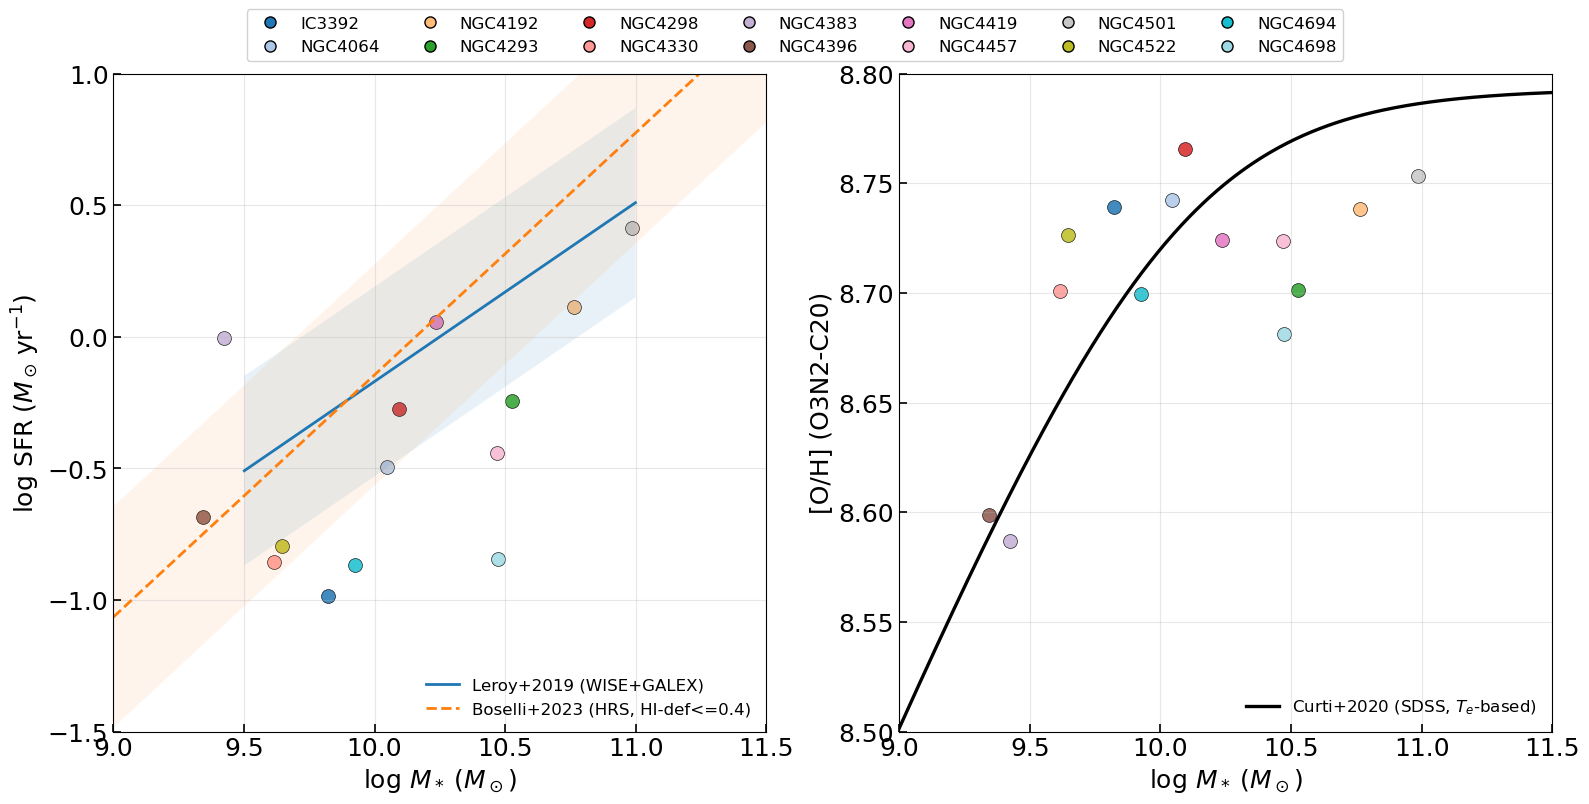

Subplot 1 (Integrated SFMS): Plotted 14 galaxies with valid total mass and SFR data
Subplot 2 (Integrated MZR, O3N2-C20 total region): Plotted 14 galaxies with valid total mass and total-region metallicity data


In [7]:
# ------------------------------------------------------------------
# Combined Plot: Integrated SFMS + Integrated MZR (O3N2-C20 total region)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from mauve_master_loader import load_mauve_master_properties
import re


# ------------------------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits at runtime.
# ------------------------------------------------------------------

GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]

MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


def parse_float(token):
    token = token.strip()
    if token == "":
        return None
    try:
        return float(token)
    except ValueError:
        return None


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


print(f"Loaded MAUVE integrated properties from {MASTER_SAMPLE_PATH}:")
for gal in GALAXIES:
    key = normalize_galaxy_name(gal)
    m = MAUVE_LOGMSTAR.get(key)
    s = MAUVE_LOGSFR.get(key)
    m_str = "MISSING" if m is None else f"{m:.3f} [mauve_master_wiki.fits]"
    s_str = "MISSING" if s is None else f"{s:.3f} [mauve_master_wiki.fits]"
    print(f"  {gal}: logM*={m_str}; logSFR={s_str}")


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def extract_total_o3n2_c20_total_metallicity(galaxy_name):
    """Extract total O3N2-C20 metallicity from total region in SFR log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-C20: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None
        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception as e:
        print(f"Error reading O3N2-C20 total metallicity log for {galaxy_name}: {e}")
        return None


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def <= 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_curti2020(logM, Z0=8.793, logM0=10.02, gamma=0.28, beta=1.2):
    """
    Curti+2020 global MZR, Eq. (2)
    Input: logM = log10(M*/Msun)
    Returns: 12 + log(O/H)
    """
    M = 10 ** np.asarray(logM, dtype=float)
    M0 = 10 ** logM0
    return Z0 - (gamma / beta) * np.log10(1 + (M / M0) ** (-beta))


# ------------------------------------------------------------------
# Build integrated-data containers
# ------------------------------------------------------------------
sfms_masses = []
sfms_sfrs = []
sfms_names = []

mzr_masses = []
mzr_oh_total = []
mzr_names = []

for gal in GALAXIES:
    mass = get_integrated_stellar_mass(gal)
    sfr = get_integrated_sfr(gal)
    oh_total = extract_total_o3n2_c20_total_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_total is not None:
        mzr_masses.append(mass)
        mzr_oh_total.append(oh_total)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_total = np.array(mzr_oh_total)
galaxies = list(GALAXIES)

# Consistent colors across both panels
if len(galaxies) > 0:
    galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
    galaxy_color_dict = dict(zip(galaxies, galaxy_colors))
else:
    galaxy_color_dict = {}

# Build figure with only two integrated subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ------------------------------------------------------------------
# SUBPLOT 1: Integrated SFMS
# ------------------------------------------------------------------
for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, "tab:blue")
    ax1.scatter(mass, sfr, s=100, c=[color], alpha=0.85, edgecolors="black", linewidth=0.5)

x_sfms = np.linspace(9.0, 11.5, 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax1.plot(x_sfms, y_l19, lw=2, ls="-", label="Leroy+2019 (WISE+GALEX)")
ax1.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, alpha=0.10, linewidth=0)
ax1.plot(x_sfms, y_b23, lw=2, ls="--", label="Boselli+2023 (HRS, HI-def<=0.4)")
ax1.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)

ax1.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax1.set_ylabel(r"$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$")
ax1.set_xlim(9.0, 11.5)
ax1.set_ylim(-1.5, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False, loc="lower right")

# ------------------------------------------------------------------
# SUBPLOT 2: Integrated MZR (O3N2-C20 total region)
# ------------------------------------------------------------------
for mass, oh_total, gal in zip(mzr_masses, mzr_oh_total, mzr_names):
    color = galaxy_color_dict.get(gal, "tab:orange")
    ax2.scatter(mass, oh_total, s=100, c=[color], alpha=0.85, edgecolors="black", linewidth=0.5)

x_mzr = np.linspace(9.0, 11.5, 400)
ax2.plot(x_mzr, mzr_curti2020(x_mzr), lw=2.4, ls="-", color="black", label="Curti+2020 (SDSS, $T_e$-based)")

ax2.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax2.set_ylabel(r"[O/H] (O3N2-C20)")
ax2.set_xlim(9.0, 11.5)
ax2.set_ylim(8.5, 8.8)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False, loc="lower right")

# Shared galaxy legend for both subplots
plotted_galaxies = [gal for gal in galaxies if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        linestyle="None",
        markersize=8,
        markerfacecolor=galaxy_color_dict.get(gal, "gray"),
        markeredgecolor="black",
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=min(len(plotted_galaxies), 7),
        framealpha=0.9,
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_dir / "Integrated_SFMS_MZR_O3N2C20.png", dpi=600, bbox_inches="tight")
# fig.savefig(output_dir / "Integrated_SFMS_MZR_O3N2C20.pdf", bbox_inches="tight")
plt.show()

print(f"Subplot 1 (Integrated SFMS): Plotted {len(sfms_names)} galaxies with valid total mass and SFR data")
print(f"Subplot 2 (Integrated MZR, O3N2-C20 total region): Plotted {len(mzr_names)} galaxies with valid total mass and total-region metallicity data")

Curti+2020 FMR residuals (O3N2-C20, total region) for the 14 galaxies
Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.824    -0.986    8.739    8.763     -0.024
NGC4064   10.046    -0.494    8.742    8.759     -0.017
NGC4192   10.764     0.114    8.738    8.775     -0.037
NGC4293   10.527    -0.243    8.701    8.775     -0.073
NGC4298   10.094    -0.276    8.766    8.753     +0.013
NGC4330    9.614    -0.856    8.701    8.732     -0.031
NGC4383    9.424    -0.006    8.587    8.565     +0.022
NGC4396    9.344    -0.686    8.599    8.651     -0.052
NGC4419   10.234     0.054    8.724    8.747     -0.023
NGC4457   10.469    -0.441    8.724    8.776     -0.052
NGC4501   10.984     0.414    8.753    8.776     -0.023
NGC4522    9.644    -0.796    8.726    8.731     -0.005
NGC4694    9.924    -0.866    8.699    8.765     -0.066
NGC4698   10.474    -0.846    8.681    8.778     -0.096

N                = 14
Mean delta_Z     = -0.033 dex
Median delta_Z   = -0.028 dex

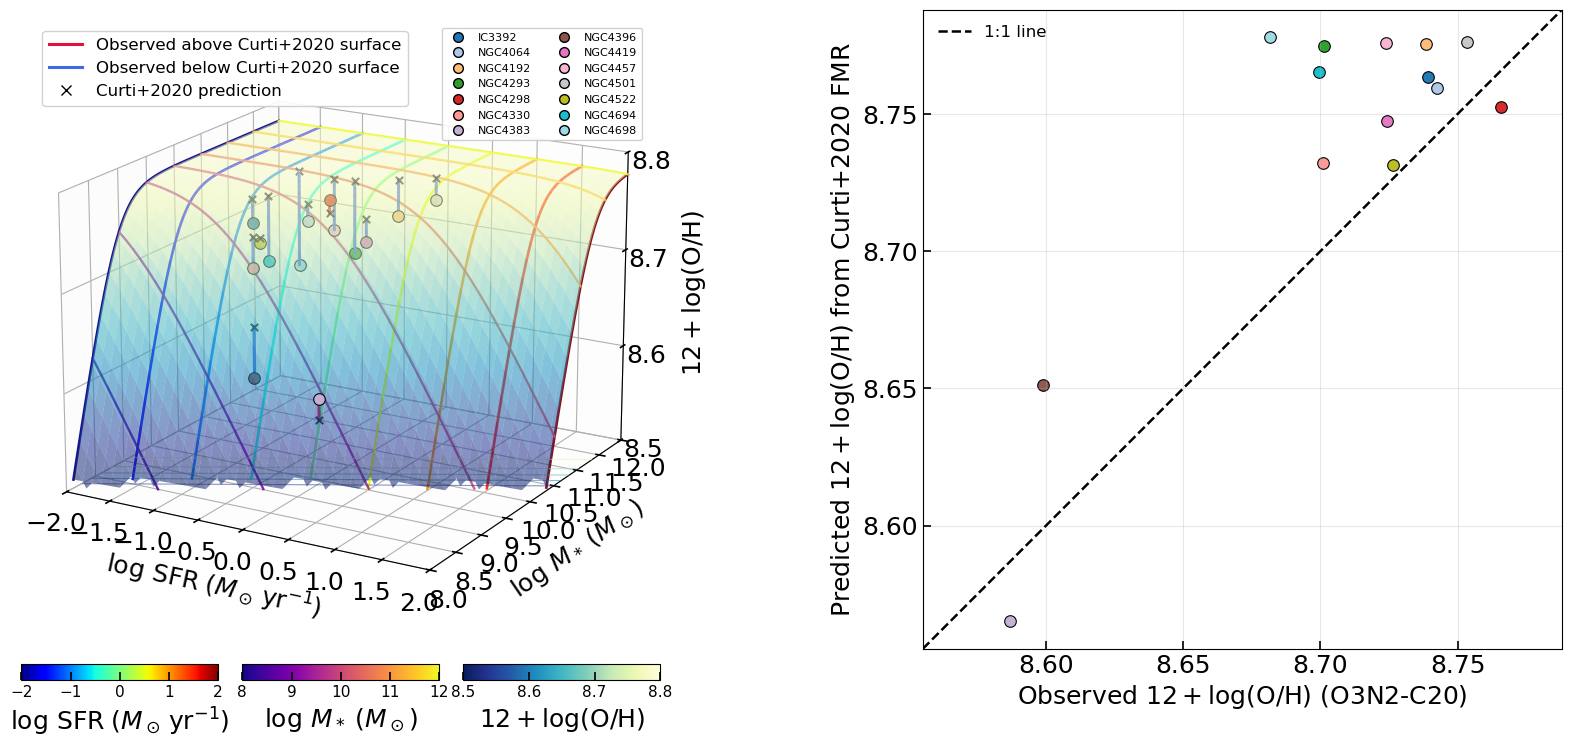

In [8]:
# ================================================================
# 3D Curti+2020 FMR surface + MAUVE/VERTICO 14 galaxies
# with bottom SFR, M*, and metallicity colorbars
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from mauve_master_loader import load_mauve_master_properties

# ------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits so this cell can run standalone.
# ------------------------------------------------
MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def extract_total_o3n2_c20_total_metallicity(galaxy_name):
    """Extract total O3N2-C20 metallicity from total region in SFR log. Returns [O/H] or None."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-C20: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception as e:
        print(f"Error reading O3N2-C20 total metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Curti+2020 total-SFR FMR parameters
# ------------------------------------------------
CURTI_Z0 = 8.779
CURTI_M0 = 10.11
CURTI_M1 = 0.56
CURTI_GAMMA = 0.31
CURTI_BETA = 2.1


def curti2020_fmr_total_sfr(
    logMstar,
    logSFR,
    Z0=CURTI_Z0,
    m0=CURTI_M0,
    m1=CURTI_M1,
    gamma=CURTI_GAMMA,
    beta=CURTI_BETA,
):
    """
    Curti+2020 FMR surface for total SFR.
    Input:
        logMstar = log10(M*/Msun)
        logSFR   = log10(SFR/[Msun/yr])
    Returns:
        predicted 12+log(O/H)
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)

    logM0_sfr = m0 + m1 * logSFR
    term = 10.0 ** (-beta * (logMstar - logM0_sfr))
    return Z0 - (gamma / beta) * np.log10(1.0 + term)


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_c20_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or metallicity")
        continue

    Z_pred = curti2020_fmr_total_sfr(logM, logSFR)
    deltaZ = Z_obs - Z_pred

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(deltaZ),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = [r["gal"] for r in rows]
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])


# ------------------------------------------------
# Print summary
# ------------------------------------------------
print("Curti+2020 FMR residuals (O3N2-C20, total region) for the 14 galaxies")
print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N                = {len(rows)}")
print(f"Mean delta_Z     = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z   = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z      = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")
print(f"Std(delta_Z)     = {np.std(delta_arr, ddof=1):.3f} dex")


# ------------------------------------------------
# Surface grid
# ------------------------------------------------
x_min = min(8.0, np.floor(logM_arr.min() * 10) / 10 - 0.3)
x_max = max(12.0, np.ceil(logM_arr.max() * 10) / 10 + 0.3)
y_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.3)
y_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.3)

x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)
XX, YY = np.meshgrid(x_grid, y_grid)
ZZ = curti2020_fmr_total_sfr(XX, YY)

# Requested display range for metallicity axis
z_floor = 8.5
z_top = 8.8

# Mask out-of-bounds Z values to prevent spilling over the visual limits
ZZ_plot = np.where((ZZ >= z_floor) & (ZZ <= z_top), ZZ, np.nan)

# Colormap normalizations for colorbars
sfr_norm = Normalize(vmin=y_min, vmax=y_max)
mstar_norm = Normalize(vmin=x_min, vmax=x_max)
surface_norm = Normalize(vmin=z_floor, vmax=z_top)
sfr_cmap = plt.get_cmap("jet")
mstar_cmap = plt.get_cmap("plasma")
surface_cmap = plt.get_cmap("YlGnBu_r")


# ------------------------------------------------
# Plot setup: left 3D panel + right comparison panel
# ------------------------------------------------
fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1.0], wspace=0.05)
ax = fig.add_subplot(gs[0, 0], projection="3d")
ax_right = fig.add_subplot(gs[0, 1])

# Surface
surf = ax.plot_surface(
    XX,
    YY,
    ZZ_plot,
    cmap=surface_cmap,
    norm=surface_norm,
    alpha=0.55,
    linewidth=0,
    antialiased=True,
    zorder=1,
)

# Color-coded guide grids (SFR and M*) added back
sfr_slices = np.linspace(y_min, y_max, 9)
for s in sfr_slices:
    z_line = curti2020_fmr_total_sfr(x_grid, np.full_like(x_grid, s))
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        x_grid,
        np.full_like(x_grid, s),
        z_line_plot,
        color=sfr_cmap(sfr_norm(s)),
        lw=1.9,
        alpha=0.92,
        zorder=3,
    )

mstar_slices = np.linspace(x_min, x_max, 9)
for m in mstar_slices:
    z_line = curti2020_fmr_total_sfr(np.full_like(y_grid, m), y_grid)
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        np.full_like(y_grid, m),
        y_grid,
        z_line_plot,
        color=mstar_cmap(mstar_norm(m)),
        lw=1.7,
        alpha=0.88,
        zorder=3,
    )

# Faint metallicity contours projected on the floor plane
ax.contour(
    XX,
    YY,
    ZZ_plot,
    zdir="z",
    offset=z_floor,
    levels=np.linspace(z_floor, z_top, 7),
    cmap=surface_cmap,
    linewidths=0.8,
    alpha=0.55,
)


# ------------------------------------------------
# Galaxy colors
# ------------------------------------------------
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(gal_names)))
galaxy_color_dict = dict(zip(gal_names, galaxy_colors))


# ------------------------------------------------
# Plot points and vertical residual lines
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    x = r["logM"]
    y = r["logSFR"]
    z_obs = r["Z_obs"]
    z_pred = r["Z_pred"]
    dz = r["deltaZ"]
    point_color = galaxy_color_dict[gal]

    line_color = "crimson" if dz > 0 else "royalblue"
    ax.plot(
        [x, x],
        [y, y],
        [z_pred, z_obs],
        color=line_color,
        lw=2.2,
        alpha=0.95,
        zorder=6,
    )

    ax.scatter(
        x,
        y,
        z_pred,
        s=28,
        color="black",
        alpha=0.8,
        marker="x",
        zorder=7,
    )

    ax.scatter(
        x,
        y,
        z_obs,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=8,
    )


# ------------------------------------------------
# Labels, limits, view
# ------------------------------------------------
ax.set_xlabel(r'$\log\,M_* \; (M_\odot)$', labelpad=10)
ax.set_ylabel(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$', labelpad=10)
ax.set_zlabel(r'$12+\log(\mathrm{O/H})$', labelpad=10)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, y_min)
ax.set_zlim(z_floor, z_top)
ax.set_zticks(np.arange(8.5, 8.81, 0.1))

ax.view_init(elev=18, azim=210)

# Put z-axis on the opposite side (right side for this view)
try:
    ax.zaxis._axinfo["juggled"] = (1, 2, 0)
except Exception:
    pass

ax.zaxis.set_tick_params(pad=2)
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)

ax.xaxis.pane.set_alpha(0.10)
ax.yaxis.pane.set_alpha(0.10)
ax.zaxis.pane.set_alpha(0.10)


# ------------------------------------------------
# Legends
# ------------------------------------------------
offset_handles = [
    Line2D([0], [0], color="crimson", lw=2.2, label="Observed above Curti+2020 surface"),
    Line2D([0], [0], color="royalblue", lw=2.2, label="Observed below Curti+2020 surface"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=7, label="Curti+2020 prediction"),
]
leg1 = ax.legend(handles=offset_handles, loc="upper left", bbox_to_anchor=(0.02, 0.98), framealpha=0.9)
ax.add_artist(leg1)

gal_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        linestyle="None",
        markersize=7,
        markerfacecolor=galaxy_color_dict[g],
        markeredgecolor="black",
        label=g,
    )
    for g in gal_names
]
ax.legend(
    handles=gal_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)


# ------------------------------------------------
# Right panel: predicted vs observed metallicity
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    zp = r["Z_pred"]
    zo = r["Z_obs"]
    point_color = galaxy_color_dict[gal]

    ax_right.scatter(
        zo,
        zp,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
    )

line_min = min(np.nanmin(Z_pred_arr), np.nanmin(Z_obs_arr)) - 0.01
line_max = max(np.nanmax(Z_pred_arr), np.nanmax(Z_obs_arr)) + 0.01
ax_right.plot(
    [line_min, line_max],
    [line_min, line_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
)

ax_right.set_xlim(line_min, line_max)
ax_right.set_ylim(line_min, line_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r'Observed $12+\log(\mathrm{O/H})$ (O3N2-C20)')
ax_right.set_ylabel(r'Predicted $12+\log(\mathrm{O/H})$ from Curti+2020 FMR')
ax_right.legend(frameon=False, loc="upper left")
# ax_right.set_title('Predicted FMR Plane vs Observed O3N2-C20')


# Keep room for three bottom colorbars under the left panel.
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.24, top=0.95)


# ------------------------------------------------
# Three colorbars below the left 3D panel
# ------------------------------------------------
bbox = ax.get_position()
cb_h = 0.018
cb_pad = 0.035
cb_gap = 0.012
total_w = bbox.width
cb_w = (total_w - 2 * cb_gap) / 3.0
cb_y = bbox.y0 - cb_pad

cax1 = fig.add_axes([bbox.x0, cb_y, cb_w, cb_h])
cax2 = fig.add_axes([bbox.x0 + cb_w + cb_gap, cb_y, cb_w, cb_h])
cax3 = fig.add_axes([bbox.x0 + 2 * (cb_w + cb_gap), cb_y, cb_w, cb_h])

sm1 = cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sm2 = cm.ScalarMappable(norm=mstar_norm, cmap=mstar_cmap)
sm3 = cm.ScalarMappable(norm=surface_norm, cmap=surface_cmap)
sm1.set_array([])
sm2.set_array([])
sm3.set_array([])

cb1 = fig.colorbar(sm1, cax=cax1, orientation="horizontal")
cb1.set_label(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$')
cb1.ax.tick_params(labelsize=11)

cb2 = fig.colorbar(sm2, cax=cax2, orientation="horizontal")
cb2.set_label(r'$\log\,M_* \; (M_\odot)$')
cb2.ax.tick_params(labelsize=11)

cb3 = fig.colorbar(sm3, cax=cax3, orientation="horizontal")
cb3.set_label(r'$12+\log(\mathrm{O/H})$')
cb3.ax.tick_params(labelsize=11)


# ------------------------------------------------
# Save
# ------------------------------------------------
output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_dir / "Curti2020_FMR_3D_plus_C20_pred_vs_obs.png", dpi=600, bbox_inches="tight")
# fig.savefig(output_dir / "Curti2020_FMR_3D_plus_C20_pred_vs_obs.pdf", bbox_inches="tight")

plt.show()

Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.824    -0.986    8.739    8.763     -0.024
NGC4064   10.046    -0.494    8.742    8.759     -0.017
NGC4192   10.764     0.114    8.738    8.775     -0.037
NGC4293   10.527    -0.243    8.701    8.775     -0.073
NGC4298   10.094    -0.276    8.766    8.753     +0.013
NGC4330    9.614    -0.856    8.701    8.732     -0.031
NGC4383    9.424    -0.006    8.587    8.565     +0.022
NGC4396    9.344    -0.686    8.599    8.651     -0.052
NGC4419   10.234     0.054    8.724    8.747     -0.023
NGC4457   10.469    -0.441    8.724    8.776     -0.052
NGC4501   10.984     0.414    8.753    8.776     -0.023
NGC4522    9.644    -0.796    8.726    8.731     -0.005
NGC4694    9.924    -0.866    8.699    8.765     -0.066
NGC4698   10.474    -0.846    8.681    8.778     -0.096

N              = 14
Mean delta_Z   = -0.033 dex
Median delta_Z = -0.028 dex
RMS delta_Z    = 0.046 dex


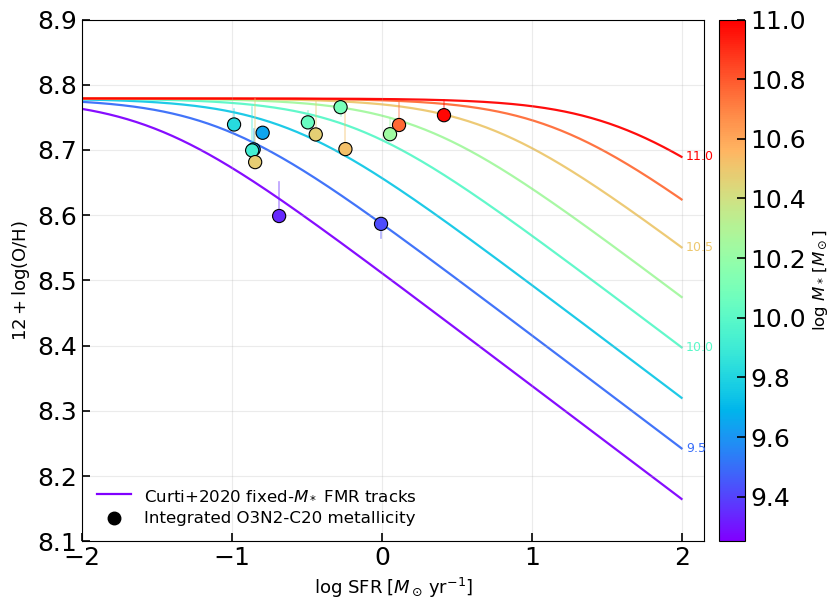

In [9]:
# ================================================================
# 2D Curti+2020 FMR projection:
# integrated SFR vs integrated O/H
# galaxies color-coded by stellar mass
# + fixed-M* Curti+2020 FMR tracks
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from mauve_master_loader import load_mauve_master_properties

# ------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits so this cell can run standalone.
# ------------------------------------------------
MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


# ------------------------------------------------
# Metallicity extractor
# ------------------------------------------------
def extract_total_o3n2_c20_total_metallicity(galaxy_name):
    """
    Extract total O3N2-C20 metallicity from:
    sfr_logs/{galaxy}.log

    Expected line:
    [O/H] O3N2-C20: Total metallicity in total region: ...
    """
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        content = log_file.read_text()
        pattern = r"\[O/H\] O3N2-C20: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None

    except Exception as e:
        print(f"Error reading metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Curti+2020 total-SFR FMR parameters
# ------------------------------------------------
CURTI_Z0 = 8.779
CURTI_M0 = 10.11
CURTI_M1 = 0.56
CURTI_GAMMA = 0.31
CURTI_BETA = 2.1


def curti2020_fmr_total_sfr(
    logMstar,
    logSFR,
    Z0=CURTI_Z0,
    m0=CURTI_M0,
    m1=CURTI_M1,
    gamma=CURTI_GAMMA,
    beta=CURTI_BETA,
):
    """
    Curti+2020 integrated FMR parameterization (total SFR version).

    Returns predicted 12 + log(O/H) for given:
        logMstar = log10(M*/Msun)
        logSFR   = log10(SFR / (Msun/yr))
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)

    logM0_sfr = m0 + m1 * logSFR
    term = 10.0 ** (-beta * (logMstar - logM0_sfr))
    return Z0 - (gamma / beta) * np.log10(1.0 + term)


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_c20_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or Z_obs")
        continue

    Z_pred = curti2020_fmr_total_sfr(logM, logSFR)

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(Z_obs - Z_pred),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = np.array([r["gal"] for r in rows])
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])

print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N              = {len(rows)}")
print(f"Mean delta_Z   = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z    = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")


# ------------------------------------------------
# Plot ranges
# ------------------------------------------------
x_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.2)
x_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.2)

# Use a slightly wider metallicity range, similar to Curti-style plots
y_min = min(8.10, np.floor(Z_obs_arr.min() * 100) / 100 - 0.03)
y_max = max(8.90, np.ceil(Z_obs_arr.max() * 100) / 100 + 0.03)

# Mass range for fixed-M* tracks
m_min = np.floor(logM_arr.min() * 4) / 4
m_max = np.ceil(logM_arr.max() * 4) / 4

# Choose a sequence of fixed-mass tracks
mass_tracks = np.arange(m_min, m_max + 0.001, 0.25)

# Grid in SFR
sfr_grid = np.linspace(x_min, x_max, 400)

# Colormap for stellar mass
cmap = plt.get_cmap("rainbow")
norm = Normalize(vmin=m_min, vmax=m_max)


# ------------------------------------------------
# Plot
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 6.2))

# Fixed-M* Curti+2020 tracks
for i, logM_fixed in enumerate(mass_tracks):
    z_track = curti2020_fmr_total_sfr(logM_fixed, sfr_grid)
    ax.plot(
        sfr_grid,
        z_track,
        color=cmap(norm(logM_fixed)),
        lw=1.6,
        alpha=0.95,
        zorder=1,
        label=r"Curti+2020 fixed-$M_*$ FMR tracks" if i == 0 else None,
    )

    # Optional label at right-hand side for selected tracks
    if np.isclose((logM_fixed * 100) % 50, 0, atol=1e-6):
        x_lab = sfr_grid[-1]
        y_lab = z_track[-1]
        if y_min < y_lab < y_max:
            ax.text(
                x_lab + 0.03,
                y_lab,
                f"{logM_fixed:.1f}",
                color=cmap(norm(logM_fixed)),
                fontsize=9,
                va="center",
            )

# Galaxies
sc = ax.scatter(
    logSFR_arr,
    Z_obs_arr,
    c=logM_arr,
    cmap=cmap,
    norm=norm,
    s=90,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
    label="Integrated O3N2-C20 metallicity",
)

# Optional: faint vertical guide from each point to its own fixed-M* track prediction
for x, zobs, zpred, m in zip(logSFR_arr, Z_obs_arr, Z_pred_arr, logM_arr):
    ax.plot(
        [x, x],
        [zpred, zobs],
        color=cmap(norm(m)),
        lw=1.2,
        alpha=0.45,
        zorder=2,
    )

# Optional: annotate galaxy names
# for g, x, y in zip(gal_names, logSFR_arr, Z_obs_arr):
#     ax.text(x + 0.03, y + 0.004, g, fontsize=8)

ax.set_xlabel(r'$\log\,\mathrm{SFR}\;[M_\odot\,\mathrm{yr}^{-1}]$', fontsize=13)
ax.set_ylabel(r'$12 + \log(\mathrm{O/H})$', fontsize=13)

ax.set_xlim(x_min, x_max + 0.15)
ax.set_ylim(y_min, y_max)

legend_handles = [
    Line2D(
        [0], [0],
        color=cmap(norm(mass_tracks[0])),
        lw=1.6,
        label=r"Curti+2020 fixed-$M_*$ FMR tracks",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=9,
        markerfacecolor="black",
        markeredgecolor="black",
        color="none",
        label="Integrated O3N2-C20 metallicity",
    ),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=12)

ax.grid(alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log\,M_*\,[M_\odot]$', fontsize=12)

plt.tight_layout()
plt.show()

Sánchez+2017 FMR residuals (O3N2-M13, total region) for the 14 galaxies
Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.824    -0.986    8.524    8.409     +0.115
NGC4064   10.046    -0.494    8.528    8.441     +0.087
NGC4192   10.764     0.114    8.523    8.525     -0.001
NGC4293   10.527    -0.243    8.485    8.494     -0.009
NGC4298   10.094    -0.276    8.553    8.450     +0.103
NGC4330    9.614    -0.856    8.484    8.390     +0.094
NGC4383    9.424    -0.006    8.373    8.388     -0.016
NGC4396    9.344    -0.686    8.384    8.367     +0.017
NGC4419   10.234     0.054    8.508    8.471     +0.038
NGC4457   10.469    -0.441    8.508    8.484     +0.024
NGC4501   10.984     0.414    8.539    8.553     -0.013
NGC4522    9.644    -0.796    8.511    8.395     +0.116
NGC4694    9.924    -0.866    8.482    8.421     +0.061
NGC4698   10.474    -0.846    8.464    8.477     -0.012

N                = 14
Mean delta_Z     = +0.043 dex
Median delta_Z   = +0.031 d

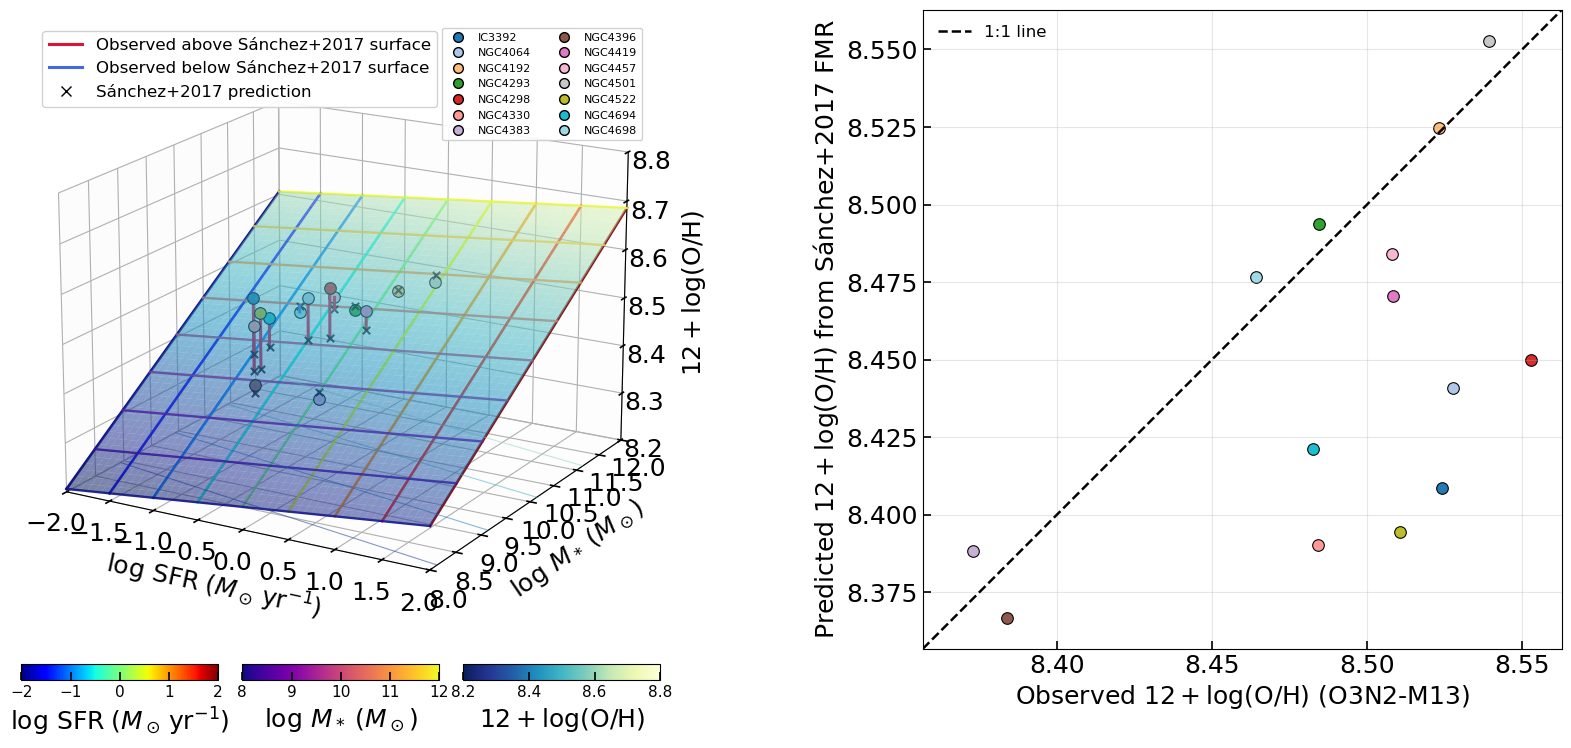

In [10]:
# ================================================================
# 3D Sánchez+2017 FMR surface + MAUVE/VERTICO 14 galaxies
# with bottom SFR, M*, and metallicity colorbars
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from mauve_master_loader import load_mauve_master_properties

# ------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits so this cell can run standalone.
# ------------------------------------------------
MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from total region in SFR log. Returns [O/H] or None."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-M13: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception as e:
        print(f"Error reading O3N2-M13 total metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Sanchez+2017 FMR plane for O3N2-M13
# ------------------------------------------------
def sanchez2017_fp_o3n2_m13(logMstar, logSFR, a=0.10, b=-0.020, c=8.246):
    """
    Sánchez et al. (2017) Eq. (6) FP fit for the O3N2-M13 calibrator.
    12 + log(O/H) = a*(logMstar-8) - b*logSFR + c
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)
    return a * (logMstar-8) - b * logSFR + c


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_m13_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or metallicity")
        continue

    Z_pred = sanchez2017_fp_o3n2_m13(logM, logSFR)
    deltaZ = Z_obs - Z_pred

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(deltaZ),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = [r["gal"] for r in rows]
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])


# ------------------------------------------------
# Print summary
# ------------------------------------------------
print("Sánchez+2017 FMR residuals (O3N2-M13, total region) for the 14 galaxies")
print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N                = {len(rows)}")
print(f"Mean delta_Z     = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z   = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z      = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")
print(f"Std(delta_Z)     = {np.std(delta_arr, ddof=1):.3f} dex")


# ------------------------------------------------
# Surface grid
# ------------------------------------------------
x_min = min(8.0, np.floor(logM_arr.min() * 10) / 10 - 0.3)
x_max = max(12.0, np.ceil(logM_arr.max() * 10) / 10 + 0.3)
y_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.3)
y_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.3)

x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)
XX, YY = np.meshgrid(x_grid, y_grid)
ZZ = sanchez2017_fp_o3n2_m13(XX, YY)

# Requested display range for metallicity axis
z_floor = 8.2
z_top = 8.8

# Mask out-of-bounds Z values to prevent spilling over the visual limits
ZZ_plot = np.where((ZZ >= z_floor) & (ZZ <= z_top), ZZ, np.nan)

# Colormap normalizations for colorbars
sfr_norm = Normalize(vmin=y_min, vmax=y_max)
mstar_norm = Normalize(vmin=x_min, vmax=x_max)
surface_norm = Normalize(vmin=z_floor, vmax=z_top)
sfr_cmap = plt.get_cmap("jet")
mstar_cmap = plt.get_cmap("plasma")
surface_cmap = plt.get_cmap("YlGnBu_r")


# ------------------------------------------------
# Plot setup: left 3D panel + right comparison panel
# ------------------------------------------------
fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1.0], wspace=0.05)
ax = fig.add_subplot(gs[0, 0], projection="3d")
ax_right = fig.add_subplot(gs[0, 1])

# Surface
surf = ax.plot_surface(
    XX,
    YY,
    ZZ_plot,
    cmap=surface_cmap,
    norm=surface_norm,
    alpha=0.55,
    linewidth=0,
    antialiased=True,
    zorder=1,
)

# Color-coded guide grids (SFR and M*) added back
sfr_slices = np.linspace(y_min, y_max, 9)
for s in sfr_slices:
    z_line = sanchez2017_fp_o3n2_m13(x_grid, np.full_like(x_grid, s))
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        x_grid,
        np.full_like(x_grid, s),
        z_line_plot,
        color=sfr_cmap(sfr_norm(s)),
        lw=1.9,
        alpha=0.92,
        zorder=3,
    )

mstar_slices = np.linspace(x_min, x_max, 9)
for m in mstar_slices:
    z_line = sanchez2017_fp_o3n2_m13(np.full_like(y_grid, m), y_grid)
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        np.full_like(y_grid, m),
        y_grid,
        z_line_plot,
        color=mstar_cmap(mstar_norm(m)),
        lw=1.7,
        alpha=0.88,
        zorder=3,
    )

# Faint metallicity contours projected on the floor plane
ax.contour(
    XX,
    YY,
    ZZ_plot,
    zdir="z",
    offset=z_floor,
    levels=np.linspace(z_floor, z_top, 7),
    cmap=surface_cmap,
    linewidths=0.8,
    alpha=0.55,
)


# ------------------------------------------------
# Galaxy colors
# ------------------------------------------------
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(gal_names)))
galaxy_color_dict = dict(zip(gal_names, galaxy_colors))


# ------------------------------------------------
# Plot points and vertical residual lines
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    x = r["logM"]
    y = r["logSFR"]
    z_obs = r["Z_obs"]
    z_pred = r["Z_pred"]
    dz = r["deltaZ"]
    point_color = galaxy_color_dict[gal]

    line_color = "crimson" if dz > 0 else "royalblue"
    ax.plot(
        [x, x],
        [y, y],
        [z_pred, z_obs],
        color=line_color,
        lw=2.2,
        alpha=0.95,
        zorder=6,
    )

    ax.scatter(
        x,
        y,
        z_pred,
        s=28,
        color="black",
        alpha=0.8,
        marker="x",
        zorder=7,
    )

    ax.scatter(
        x,
        y,
        z_obs,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=8,
    )


# ------------------------------------------------
# Labels, limits, view
# ------------------------------------------------
ax.set_xlabel(r'$\log\,M_* \; (M_\odot)$', labelpad=10)
ax.set_ylabel(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$', labelpad=10)
ax.set_zlabel(r'$12+\log(\mathrm{O/H})$', labelpad=10)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, y_min)
ax.set_zlim(z_floor, z_top)
ax.set_zticks(np.arange(8.2, 8.81, 0.1))

ax.view_init(elev=18, azim=210)

# Put z-axis on the opposite side (right side for this view)
try:
    ax.zaxis._axinfo["juggled"] = (1, 2, 0)
except Exception:
    pass

ax.zaxis.set_tick_params(pad=2)
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)

ax.xaxis.pane.set_alpha(0.10)
ax.yaxis.pane.set_alpha(0.10)
ax.zaxis.pane.set_alpha(0.10)


# ------------------------------------------------
# Legends
# ------------------------------------------------
offset_handles = [
    Line2D([0], [0], color="crimson", lw=2.2, label="Observed above Sánchez+2017 surface"),
    Line2D([0], [0], color="royalblue", lw=2.2, label="Observed below Sánchez+2017 surface"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=7, label="Sánchez+2017 prediction"),
]
leg1 = ax.legend(handles=offset_handles, loc="upper left", bbox_to_anchor=(0.02, 0.98), framealpha=0.9)
ax.add_artist(leg1)

gal_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        linestyle="None",
        markersize=7,
        markerfacecolor=galaxy_color_dict[g],
        markeredgecolor="black",
        label=g,
    )
    for g in gal_names
]
ax.legend(
    handles=gal_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)


# ------------------------------------------------
# Right panel: predicted vs observed metallicity
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    zp = r["Z_pred"]
    zo = r["Z_obs"]
    point_color = galaxy_color_dict[gal]

    ax_right.scatter(
        zo,
        zp,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
    )

line_min = min(np.nanmin(Z_pred_arr), np.nanmin(Z_obs_arr)) - 0.01
line_max = max(np.nanmax(Z_pred_arr), np.nanmax(Z_obs_arr)) + 0.01
ax_right.plot(
    [line_min, line_max],
    [line_min, line_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
)

ax_right.set_xlim(line_min, line_max)
ax_right.set_ylim(line_min, line_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r'Observed $12+\log(\mathrm{O/H})$ (O3N2-M13)')
ax_right.set_ylabel(r'Predicted $12+\log(\mathrm{O/H})$ from Sánchez+2017 FMR')
ax_right.legend(frameon=False, loc="upper left")


# Keep room for three bottom colorbars under the left panel.
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.24, top=0.95)


# ------------------------------------------------
# Three colorbars below the left 3D panel
# ------------------------------------------------
bbox = ax.get_position()
cb_h = 0.018
cb_pad = 0.035
cb_gap = 0.012
total_w = bbox.width
cb_w = (total_w - 2 * cb_gap) / 3.0
cb_y = bbox.y0 - cb_pad

cax1 = fig.add_axes([bbox.x0, cb_y, cb_w, cb_h])
cax2 = fig.add_axes([bbox.x0 + cb_w + cb_gap, cb_y, cb_w, cb_h])
cax3 = fig.add_axes([bbox.x0 + 2 * (cb_w + cb_gap), cb_y, cb_w, cb_h])

sm1 = cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sm2 = cm.ScalarMappable(norm=mstar_norm, cmap=mstar_cmap)
sm3 = cm.ScalarMappable(norm=surface_norm, cmap=surface_cmap)
sm1.set_array([])
sm2.set_array([])
sm3.set_array([])

cb1 = fig.colorbar(sm1, cax=cax1, orientation="horizontal")
cb1.set_label(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$')
cb1.ax.tick_params(labelsize=11)

cb2 = fig.colorbar(sm2, cax=cax2, orientation="horizontal")
cb2.set_label(r'$\log\,M_* \; (M_\odot)$')
cb2.ax.tick_params(labelsize=11)

cb3 = fig.colorbar(sm3, cax=cax3, orientation="horizontal")
cb3.set_label(r'$12+\log(\mathrm{O/H})$')
cb3.ax.tick_params(labelsize=11)


# ------------------------------------------------
# Save
# ------------------------------------------------
output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_dir / "Sanchez2017_FMR_3D_plus_M13_pred_vs_obs.png", dpi=600, bbox_inches="tight")
# fig.savefig(output_dir / "Sanchez2017_FMR_3D_plus_M13_pred_vs_obs.pdf", bbox_inches="tight")

plt.show()

Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.824    -0.986    8.524    8.409     +0.115
NGC4064   10.046    -0.494    8.528    8.441     +0.087
NGC4192   10.764     0.114    8.523    8.525     -0.001
NGC4293   10.527    -0.243    8.485    8.494     -0.009
NGC4298   10.094    -0.276    8.553    8.450     +0.103
NGC4330    9.614    -0.856    8.484    8.390     +0.094
NGC4383    9.424    -0.006    8.373    8.388     -0.016
NGC4396    9.344    -0.686    8.384    8.367     +0.017
NGC4419   10.234     0.054    8.508    8.471     +0.038
NGC4457   10.469    -0.441    8.508    8.484     +0.024
NGC4501   10.984     0.414    8.539    8.553     -0.013
NGC4522    9.644    -0.796    8.511    8.395     +0.116
NGC4694    9.924    -0.866    8.482    8.421     +0.061
NGC4698   10.474    -0.846    8.464    8.477     -0.012

N              = 14
Mean delta_Z   = +0.043 dex
Median delta_Z = +0.031 dex
RMS delta_Z    = 0.066 dex


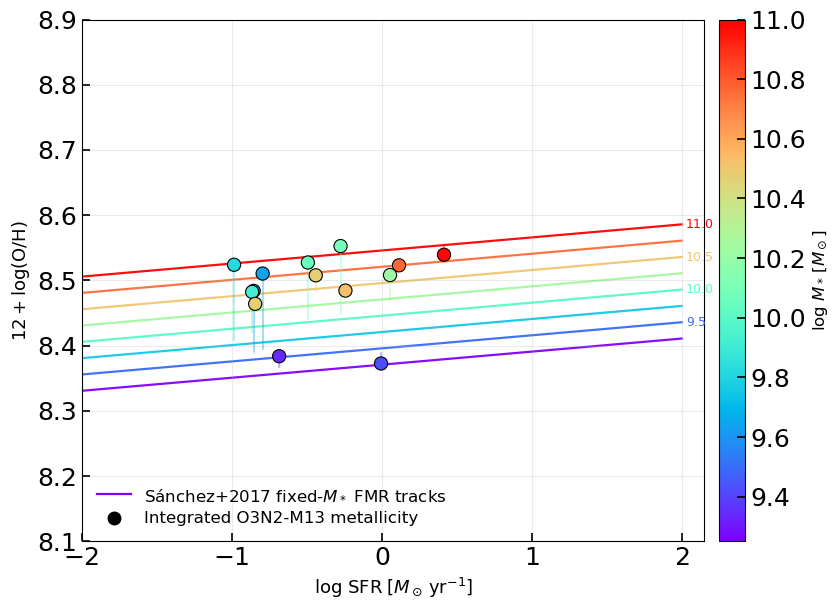

In [11]:
# ================================================================
# 2D Sanchez+2017 FMR projection:
# integrated SFR vs integrated O/H
# galaxies color-coded by stellar mass
# + fixed-M* Sanchez+2017 FMR tracks
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from mauve_master_loader import load_mauve_master_properties

# ------------------------------------------------
# Integrated stellar mass and SFR for MAUVE galaxies are read
# only from mauve_master_wiki.fits so this cell can run standalone.
# ------------------------------------------------
MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


# ------------------------------------------------
# Metallicity extractor
# ------------------------------------------------
def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """
    Extract total O3N2-M13 metallicity from:
    sfr_logs/{galaxy}.log

    Expected line:
    [O/H] O3N2-M13: Total metallicity in total region: ...
    """
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        content = log_file.read_text()
        pattern = r"\[O/H\] O3N2-M13: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None

    except Exception as e:
        print(f"Error reading metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Sanchez+2017 FMR plane for O3N2-M13
# ------------------------------------------------
def sanchez2017_fp_o3n2_m13(logMstar, logSFR, a=0.10, b=-0.020, c=8.246):
    """
    Sánchez et al. (2017) Eq. (6) FP fit for the O3N2-M13 calibrator.
    12 + log(O/H) = a*(logMstar-8) - b*logSFR + c
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)
    return a * (logMstar - 8) - b * logSFR + c


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_m13_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or Z_obs")
        continue

    Z_pred = sanchez2017_fp_o3n2_m13(logM, logSFR)

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(Z_obs - Z_pred),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = np.array([r["gal"] for r in rows])
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])

print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N              = {len(rows)}")
print(f"Mean delta_Z   = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z    = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")


# ------------------------------------------------
# Plot ranges
# ------------------------------------------------
x_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.2)
x_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.2)

# Use a slightly wider metallicity range, similar to Curti-style plots
y_min = min(8.10, np.floor(Z_obs_arr.min() * 100) / 100 - 0.03)
y_max = max(8.90, np.ceil(Z_obs_arr.max() * 100) / 100 + 0.03)

# Mass range for fixed-M* tracks
m_min = np.floor(logM_arr.min() * 4) / 4
m_max = np.ceil(logM_arr.max() * 4) / 4

# Choose a sequence of fixed-mass tracks
mass_tracks = np.arange(m_min, m_max + 0.001, 0.25)

# Grid in SFR
sfr_grid = np.linspace(x_min, x_max, 400)

# Colormap for stellar mass
cmap = plt.get_cmap("rainbow")
norm = Normalize(vmin=m_min, vmax=m_max)


# ------------------------------------------------
# Plot
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 6.2))

# Fixed-M* Sanchez+2017 tracks
for i, logM_fixed in enumerate(mass_tracks):
    z_track = sanchez2017_fp_o3n2_m13(logM_fixed, sfr_grid)
    ax.plot(
        sfr_grid,
        z_track,
        color=cmap(norm(logM_fixed)),
        lw=1.6,
        alpha=0.95,
        zorder=1,
        label=r"Sánchez+2017 fixed-$M_*$ FMR tracks" if i == 0 else None,
    )

    # Optional label at right-hand side for selected tracks
    if np.isclose((logM_fixed * 100) % 50, 0, atol=1e-6):
        x_lab = sfr_grid[-1]
        y_lab = z_track[-1]
        if y_min < y_lab < y_max:
            ax.text(
                x_lab + 0.03,
                y_lab,
                f"{logM_fixed:.1f}",
                color=cmap(norm(logM_fixed)),
                fontsize=9,
                va="center",
            )

# Galaxies
sc = ax.scatter(
    logSFR_arr,
    Z_obs_arr,
    c=logM_arr,
    cmap=cmap,
    norm=norm,
    s=90,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
    label="Integrated O3N2-M13 metallicity",
)

# Optional: faint vertical guide from each point to its own fixed-M* track prediction
for x, zobs, zpred, m in zip(logSFR_arr, Z_obs_arr, Z_pred_arr, logM_arr):
    ax.plot(
        [x, x],
        [zpred, zobs],
        color=cmap(norm(m)),
        lw=1.2,
        alpha=0.45,
        zorder=2,
    )

# Optional: annotate galaxy names
# for g, x, y in zip(gal_names, logSFR_arr, Z_obs_arr):
#     ax.text(x + 0.03, y + 0.004, g, fontsize=8)

ax.set_xlabel(r'$\log\,\mathrm{SFR}\;[M_\odot\,\mathrm{yr}^{-1}]$', fontsize=13)
ax.set_ylabel(r'$12 + \log(\mathrm{O/H})$', fontsize=13)

ax.set_xlim(x_min, x_max + 0.15)
ax.set_ylim(y_min, y_max)

legend_handles = [
    Line2D(
        [0], [0],
        color=cmap(norm(mass_tracks[0])),
        lw=1.6,
        label=r"Sánchez+2017 fixed-$M_*$ FMR tracks",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=9,
        markerfacecolor="black",
        markeredgecolor="black",
        color="none",
        label="Integrated O3N2-M13 metallicity",
    ),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=12)

ax.grid(alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log\,M_*\,[M_\odot]$', fontsize=12)

plt.tight_layout()
plt.show()

Sánchez+2017 FMR residuals (O3N2-M13, total region) for the 14 galaxies
Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.824    -0.986    8.524    8.409     +0.115
NGC4064   10.046    -0.494    8.528    8.441     +0.087
NGC4192   10.764     0.114    8.523    8.525     -0.001
NGC4293   10.527    -0.243    8.485    8.494     -0.009
NGC4298   10.094    -0.276    8.553    8.450     +0.103
NGC4330    9.614    -0.856    8.484    8.390     +0.094
NGC4383    9.424    -0.006    8.373    8.388     -0.016
NGC4396    9.344    -0.686    8.384    8.367     +0.017
NGC4419   10.234     0.054    8.508    8.471     +0.038
NGC4457   10.469    -0.441    8.508    8.484     +0.024
NGC4501   10.984     0.414    8.539    8.553     -0.013
NGC4522    9.644    -0.796    8.511    8.395     +0.116
NGC4694    9.924    -0.866    8.482    8.421     +0.061
NGC4698   10.474    -0.846    8.464    8.477     -0.012

N                = 14
Mean delta_Z     = +0.043 dex
Median delta_Z   = +0.031 d

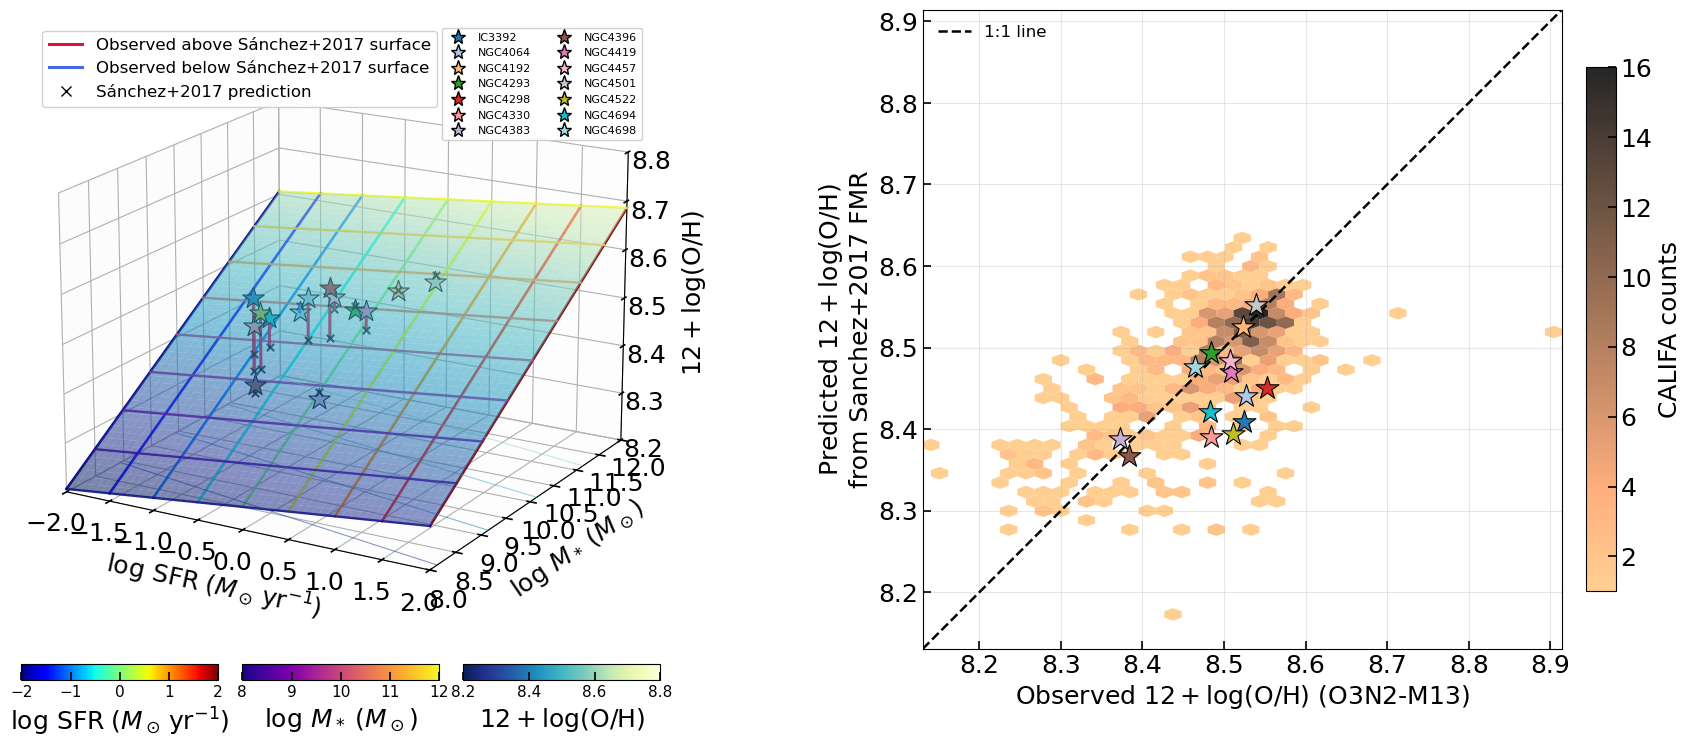

In [12]:
# Update Cell 10 panels: set MAUVE markers to stars and add CALIFA-colored background in predicted-vs-observed metallicity space.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from matplotlib.markers import MarkerStyle
from mpl_toolkits.mplot3d import art3d

if "ax_right" not in globals() or "rows" not in globals():
    raise RuntimeError("Run Cell 10 first so ax_right and rows are defined.")

if "sanchez2017_fp_o3n2_m13" not in globals():
    raise RuntimeError("Run Cell 10 first so sanchez2017_fp_o3n2_m13 is available.")

fig_right = ax_right.figure

# Reprint the Sanchez+2017 residual summary expected from Cell 10.
print("Sánchez+2017 FMR residuals (O3N2-M13, total region) for the 14 galaxies")
print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

delta_arr = np.array([r["deltaZ"] for r in rows], dtype=float)
print()
print(f"N                = {len(rows)}")
print(f"Mean delta_Z     = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z   = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z      = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")
print(f"Std(delta_Z)     = {np.std(delta_arr, ddof=1):.3f} dex")

# Update left panel MAUVE observed points to star markers.
left_ax = None
if "ax_right" in globals():
    for candidate_ax in ax_right.figure.axes:
        if candidate_ax is ax_right:
            continue
        if getattr(candidate_ax, "name", "") == "3d":
            left_ax = candidate_ax
            break
        xlab_candidate = candidate_ax.get_xlabel() if hasattr(candidate_ax, "get_xlabel") else ""
        if len(getattr(candidate_ax, "collections", [])) > 0 and ("SFR" in xlab_candidate or "M_" in xlab_candidate):
            left_ax = candidate_ax
            break
if left_ax is None:
    left_ax = globals().get("ax_left", globals().get("ax"))
if left_ax is not None:
    # Remove prior Cell 12 overlays so reruns stay clean.
    for coll in list(left_ax.collections):
        if hasattr(coll, "get_gid") and coll.get_gid() == "cell12_star_overlay":
            coll.remove()

    # Hide original large observed-circle collections (works for 2D and 3D).
    for coll in left_ax.collections:
        if hasattr(coll, "get_sizes"):
            sizes = np.asarray(coll.get_sizes(), dtype=float)
            if sizes.size > 0 and np.nanmax(sizes) >= 60.0:
                coll.set_alpha(0.0)

    # Match axis orientation if x/y were swapped.
    xlab = left_ax.get_xlabel()
    use_sfr_on_x = "SFR" in xlab
    is_3d = hasattr(left_ax, "zaxis")
    for r in rows:
        x = r["logSFR"] if use_sfr_on_x else r["logM"]
        y = r["logM"] if use_sfr_on_x else r["logSFR"]
        c = galaxy_color_dict.get(r["gal"], "white")
        if is_3d:
            star_coll = left_ax.scatter(
                x,
                y,
                r["Z_obs"],
                s=260,
                marker="*",
                color=c,
                edgecolor="black",
                linewidth=0.8,
                alpha=0.98,
                zorder=9,
            )
        else:
            star_coll = left_ax.scatter(
                x,
                y,
                s=260,
                marker="*",
                color=c,
                edgecolor="black",
                linewidth=0.8,
                alpha=0.98,
                zorder=9,
            )
        star_coll.set_gid("cell12_star_overlay")

    # Galaxy legend in left panel: switch marker symbol to star for consistency.
    leg_gal = left_ax.get_legend()
    if leg_gal is not None:
        for h in leg_gal.legend_handles:
            if hasattr(h, "set_marker"):
                h.set_marker("*")
                h.set_markersize(11)

califa_path = Path("Sanchez2017TableB1.csv")
if not califa_path.exists():
    raise FileNotFoundError(f"Missing CALIFA file: {califa_path}")

califa = np.genfromtxt(
    califa_path,
    delimiter=",",
    comments="#",
    usecols=(1, 3, 5),
    dtype=float,
    invalid_raise=False,
)

if califa.ndim == 1:
    califa = califa.reshape(1, -1)

califa_logm = califa[:, 0]
califa_logsfr = califa[:, 1]
califa_oh_obs = califa[:, 2]
valid = np.isfinite(califa_logm) & np.isfinite(califa_logsfr) & np.isfinite(califa_oh_obs)

califa_logm = califa_logm[valid]
califa_logsfr = califa_logsfr[valid]
califa_oh_obs = califa_oh_obs[valid]
califa_oh_pred = sanchez2017_fp_o3n2_m13(califa_logm, califa_logsfr)
print(f"CALIFA entries used (valid mass+SFR+O/H): {len(califa_logm)}")

ax_right.cla()

hb_califa = ax_right.hexbin(
    califa_oh_obs,
    califa_oh_pred,
    gridsize=36,
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)

for r in rows:
    gal = r["gal"]
    zo = r["Z_obs"]
    zp = r["Z_pred"]
    point_color = galaxy_color_dict.get(gal, "white")
    ax_right.scatter(
        zo,
        zp,
        s=300,
        marker="*",
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=3,
    )

line_min = min(
    np.nanmin(califa_oh_obs),
    np.nanmin(califa_oh_pred),
    np.nanmin(Z_obs_arr),
    np.nanmin(Z_pred_arr),
) - 0.01
line_max = max(
    np.nanmax(califa_oh_obs),
    np.nanmax(califa_oh_pred),
    np.nanmax(Z_obs_arr),
    np.nanmax(Z_pred_arr),
) + 0.01
ax_right.plot(
    [line_min, line_max],
    [line_min, line_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
    zorder=2,
)

ax_right.set_xlim(line_min, line_max)
ax_right.set_ylim(line_min, line_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r"Observed $12+\log(\mathrm{O/H})$ (O3N2-M13)")
ax_right.set_ylabel(r"Predicted $12+\log(\mathrm{O/H})$" "\n" r"from Sanchez+2017 FMR")
ax_right.legend(frameon=False, loc="upper left")

# Replace older right-panel CALIFA colorbar/cax if this cell is re-run.
if "cbar_califa_right" in globals():
    try:
        cbar_califa_right.remove()
    except Exception:
        pass
if "cax_califa_right" in globals():
    try:
        cax_califa_right.remove()
    except Exception:
        pass

bbox = ax_right.get_position()
cbar_h = bbox.height * 0.82
cbar_y = bbox.y0 + 0.5 * (bbox.height - cbar_h)
cax_califa_right = fig_right.add_axes([bbox.x1 + 0.012, cbar_y, 0.015, cbar_h])
cbar_califa_right = fig_right.colorbar(hb_califa, cax=cax_califa_right)
cbar_califa_right.set_label("CALIFA counts")

fig_right.canvas.draw_idle()
display(fig_right)
plt.close(fig_right)

CALIFA entries used (valid mass+SFR+O/H): 612


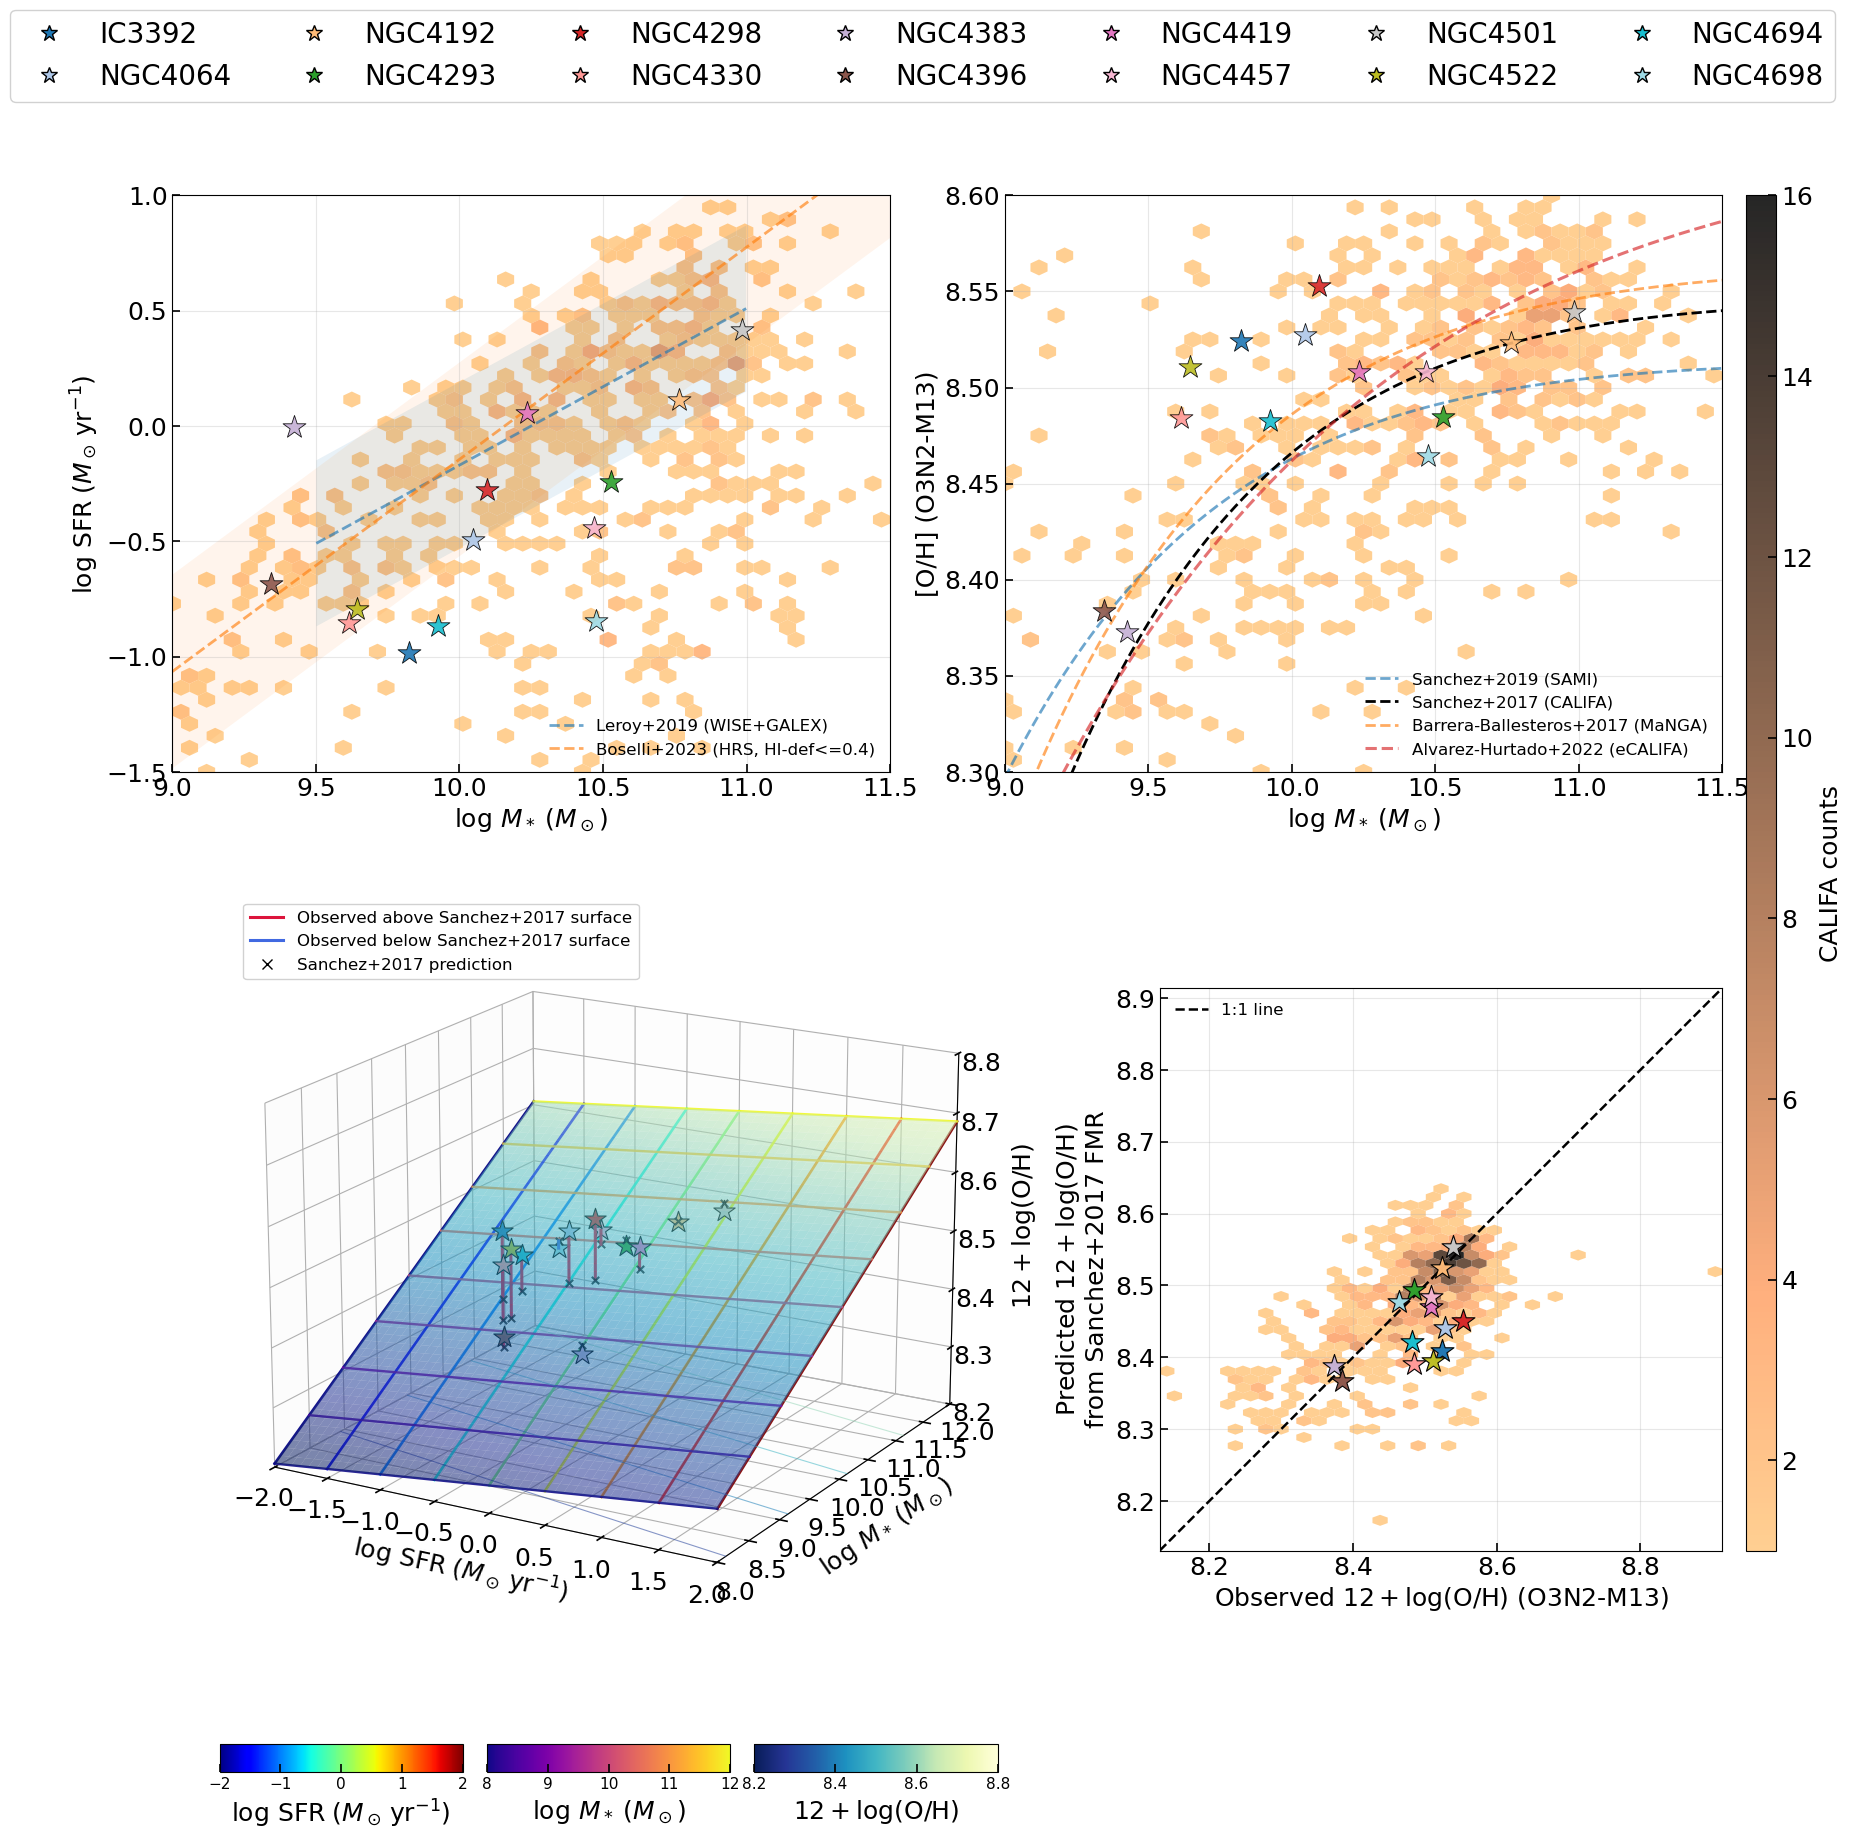

Subplot 1 (Integrated SFMS): 14 galaxies
Subplot 2 (Integrated MZR, O3N2-M13 total region): 14 galaxies
Bottom row (Sanchez+2017 FMR residuals): 14 galaxies


In [13]:
# Combined Cell 6 + Cell 12 into a 2x2 layout
# Requested changes: no subtitles, shared copper colorbar on RHS across two rows,
# and no galaxy legend in the bottom-left panel.
# NOTE: this cell reads all required data from disk each run (no cached plot arrays).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib import cm
from pathlib import Path
from mauve_master_loader import load_mauve_master_properties
import re

# ------------------------------------------------------------------
# Standalone data loading with MAUVE integrated stellar mass and SFR
# read only from mauve_master_wiki.fits.
# ------------------------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]

MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")
CALIFA_TABLE_PATH = Path("Sanchez2017TableB1.csv")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)


def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from total region in SFR log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-M13: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None
        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception:
        return None


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def load_califa_o3n2_m13(table_path):
    """Load CALIFA integrated properties: COLUMN2 log_Mass, COLUMN4 log_SFR, COLUMN6 OH_O3N2_M13."""
    if not table_path.exists():
        raise FileNotFoundError(f"Missing CALIFA table file: {table_path}")

    data = np.genfromtxt(
        table_path,
        delimiter=",",
        comments="#",
        usecols=(1, 3, 5),
        dtype=float,
        invalid_raise=False,
    )

    if data.ndim == 1:
        data = data.reshape(1, -1)

    logm = data[:, 0]
    logsfr = data[:, 1]
    oh = data[:, 2]
    valid_all = np.isfinite(logm) & np.isfinite(logsfr) & np.isfinite(oh)
    logm_valid = logm[valid_all]
    logsfr_valid = logsfr[valid_all]
    oh_valid = oh[valid_all]
    return logm_valid, logsfr_valid, logm_valid, oh_valid


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def <= 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_sanchez2019(logM, a=8.51, b=0.007, c=3.5):
    """Sanchez+2019 SAMI relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_sanchez2017(logM, a=8.54, b=0.011, c=3.5):
    """Sanchez+2017 CALIFA relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_barrera_ballesteros2017_m13(logM, a=8.56, b=0.005, c=4.0):
    """Barrera-Ballesteros+2017 MaNGA relation (O3N2-M13)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_alvarez_hurtado2022_m13(logM, a=8.63366, b=-17.56889, c=3.5):
    """eCALIFA exponential MZR (erratum coefficients), using x = log10(M*/Msun)."""
    x = np.asarray(logM, dtype=float)
    t = x - c
    return a + b * t * np.exp(-t)


def sanchez2017_fp_o3n2_m13(logMstar, logSFR, a=0.10, b=-0.020, c=8.246):
    """Sanchez+2017 Eq. (6) FP fit for O3N2-M13 calibrator."""
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)
    return a * (logMstar - 8) - b * logSFR + c


# Build integrated-data containers from mauve_master_wiki.fits and local metallicity logs.
sfms_masses = []
sfms_sfrs = []
sfms_names = []

mzr_masses = []
mzr_oh_total = []
mzr_names = []

for gal in GALAXIES:
    mass = get_integrated_stellar_mass(gal)
    sfr = get_integrated_sfr(gal)
    oh_total = extract_total_o3n2_m13_total_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_total is not None:
        mzr_masses.append(mass)
        mzr_oh_total.append(oh_total)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_total = np.array(mzr_oh_total)

galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(GALAXIES)))
galaxy_color_dict = dict(zip(GALAXIES, galaxy_colors))

# Build FMR rows from mauve_master_wiki.fits and local metallicity logs.
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_m13_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        continue

    Z_pred = sanchez2017_fp_o3n2_m13(logM, logSFR)
    deltaZ = Z_obs - Z_pred

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(deltaZ),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found from mauve_master_wiki.fits and local metallicity logs.")

Z_obs_arr = np.array([r["Z_obs"] for r in rows], dtype=float)
Z_pred_arr = np.array([r["Z_pred"] for r in rows], dtype=float)

# ---------- Figure layout (2x2) ----------
fig = plt.figure(figsize=(20, 19))
gs_outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.35], hspace=0.16)
gs_top = gs_outer[0].subgridspec(1, 2, width_ratios=[1.0, 1.0], wspace=0.16)
gs_bottom = gs_outer[1].subgridspec(1, 2, width_ratios=[1.55, 1.0], wspace=0.16)
ax_sfms = fig.add_subplot(gs_top[0, 0])
ax_mzr = fig.add_subplot(gs_top[0, 1])
ax_left = fig.add_subplot(gs_bottom[0, 0], projection="3d")
ax_right = fig.add_subplot(gs_bottom[0, 1])

# ---------- Shared CALIFA data ----------
califa_logm_sfms, califa_logsfr, califa_logm_mzr, califa_oh = load_califa_o3n2_m13(CALIFA_TABLE_PATH)
califa_oh_pred = sanchez2017_fp_o3n2_m13(califa_logm_sfms, califa_logsfr)
print(f"CALIFA entries used (valid mass+SFR+O/H): {len(califa_logm_sfms)}")

# ---------- Top-left: Integrated SFMS (Cell 6 style) ----------
hb_sfms = ax_sfms.hexbin(
    califa_logm_sfms,
    califa_logsfr,
    gridsize=42,
    extent=(9.0, 11.5, -1.5, 1.0),
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)
for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, "tab:blue")
    ax_sfms.scatter(mass, sfr, s=300, marker="*", c=[color], alpha=0.9, edgecolors="black", linewidth=0.6, zorder=3)

x_sfms = np.linspace(9.0, 11.5, 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax_sfms.plot(x_sfms, y_l19, lw=2, ls="--", alpha=0.65, label="Leroy+2019 (WISE+GALEX)")
ax_sfms.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, alpha=0.10, linewidth=0)
ax_sfms.plot(x_sfms, y_b23, lw=2, ls="--", alpha=0.65, label="Boselli+2023 (HRS, HI-def<=0.4)")
ax_sfms.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)
ax_sfms.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax_sfms.set_ylabel(r"$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$")
ax_sfms.set_xlim(9.0, 11.5)
ax_sfms.set_ylim(-1.5, 1.0)
ax_sfms.grid(True, alpha=0.3)
ax_sfms.legend(frameon=False, loc="lower right")

# ---------- Top-right: Integrated MZR (Cell 6 style) ----------
hb_mzr = ax_mzr.hexbin(
    califa_logm_mzr,
    califa_oh,
    gridsize=42,
    extent=(9.0, 11.5, 8.3, 8.6),
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)
for mass, oh_total, gal in zip(mzr_masses, mzr_oh_total, mzr_names):
    color = galaxy_color_dict.get(gal, "tab:orange")
    ax_mzr.scatter(mass, oh_total, s=300, marker="*", c=[color], alpha=0.9, edgecolors="black", linewidth=0.6, zorder=3)

x_mzr = np.linspace(9.0, 11.5, 400)
ax_mzr.plot(x_mzr, mzr_sanchez2019(x_mzr), lw=2, ls="--", alpha=0.65, label="Sanchez+2019 (SAMI)", zorder=2)
ax_mzr.plot(x_mzr, mzr_sanchez2017(x_mzr), lw=2, ls="--", color="black", label="Sanchez+2017 (CALIFA)", zorder=2)
ax_mzr.plot(x_mzr, mzr_barrera_ballesteros2017_m13(x_mzr), lw=2, ls="--", alpha=0.65, label="Barrera-Ballesteros+2017 (MaNGA)", zorder=2)
ax_mzr.plot(x_mzr, mzr_alvarez_hurtado2022_m13(x_mzr), lw=2.2, ls="--", alpha=0.65, color="tab:red", label="Alvarez-Hurtado+2022 (eCALIFA)", zorder=2)
ax_mzr.set_xlabel(r"$\log\,M_* \; (M_\odot)$")
ax_mzr.set_ylabel(r"[O/H] (O3N2-M13)")
ax_mzr.set_xlim(9.0, 11.5)
ax_mzr.set_ylim(8.3, 8.6)
ax_mzr.grid(True, alpha=0.3)
ax_mzr.legend(frameon=False, loc="lower right")

# Keep Cell 6's shared galaxy legend behavior (top-level figure legend).
plotted_galaxies = [gal for gal in GALAXIES if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0], [0], marker="*", color="none", linestyle="None", markersize=12,
        markerfacecolor=galaxy_color_dict.get(gal, "gray"), markeredgecolor="black"
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=min(len(plotted_galaxies), 7),
        fontsize=20,
        framealpha=0.9,
    )

# ---------- Bottom-left: 3D Sanchez+2017 FMR surface (Cell 12/10 style) ----------
logM_arr = np.array([r["logM"] for r in rows], dtype=float)
logSFR_arr = np.array([r["logSFR"] for r in rows], dtype=float)

delta_arr_local = np.array([r["deltaZ"] for r in rows], dtype=float)

x_min = min(8.0, np.floor(logM_arr.min() * 10) / 10 - 0.3)
x_max = max(12.0, np.ceil(logM_arr.max() * 10) / 10 + 0.3)
y_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.3)
y_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.3)

x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)
XX, YY = np.meshgrid(x_grid, y_grid)
ZZ = sanchez2017_fp_o3n2_m13(XX, YY)

z_floor = 8.2
z_top = 8.8
ZZ_plot = np.where((ZZ >= z_floor) & (ZZ <= z_top), ZZ, np.nan)

sfr_norm = Normalize(vmin=y_min, vmax=y_max)
mstar_norm = Normalize(vmin=x_min, vmax=x_max)
surface_norm = Normalize(vmin=z_floor, vmax=z_top)
sfr_cmap = plt.get_cmap("jet")
mstar_cmap = plt.get_cmap("plasma")
surface_cmap = plt.get_cmap("YlGnBu_r")

ax_left.plot_surface(
    XX,
    YY,
    ZZ_plot,
    cmap=surface_cmap,
    norm=surface_norm,
    alpha=0.55,
    linewidth=0,
    antialiased=True,
    zorder=1,
)

sfr_slices = np.linspace(y_min, y_max, 9)
for s in sfr_slices:
    z_line = sanchez2017_fp_o3n2_m13(x_grid, np.full_like(x_grid, s))
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax_left.plot(
        x_grid,
        np.full_like(x_grid, s),
        z_line_plot,
        color=sfr_cmap(sfr_norm(s)),
        lw=1.9,
        alpha=0.92,
        zorder=3,
    )

mstar_slices = np.linspace(x_min, x_max, 9)
for m in mstar_slices:
    z_line = sanchez2017_fp_o3n2_m13(np.full_like(y_grid, m), y_grid)
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax_left.plot(
        np.full_like(y_grid, m),
        y_grid,
        z_line_plot,
        color=mstar_cmap(mstar_norm(m)),
        lw=1.7,
        alpha=0.88,
        zorder=3,
    )

ax_left.contour(
    XX,
    YY,
    ZZ_plot,
    zdir="z",
    offset=z_floor,
    levels=np.linspace(z_floor, z_top, 7),
    cmap=surface_cmap,
    linewidths=0.8,
    alpha=0.55,
)

for r in rows:
    gal = r["gal"]
    x = r["logM"]
    y = r["logSFR"]
    z_obs = r["Z_obs"]
    z_pred = r["Z_pred"]
    dz = r["deltaZ"]
    point_color = galaxy_color_dict.get(gal, "white")

    line_color = "crimson" if dz > 0 else "royalblue"
    ax_left.plot(
        [x, x],
        [y, y],
        [z_pred, z_obs],
        color=line_color,
        lw=2.2,
        alpha=0.95,
        zorder=6,
    )

    ax_left.scatter(
        x,
        y,
        z_pred,
        s=28,
        color="black",
        alpha=0.8,
        marker="x",
        zorder=7,
    )

    ax_left.scatter(
        x,
        y,
        z_obs,
        s=260,
        marker="*",
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=8,
    )

ax_left.set_xlabel(r"$\log\,M_* \; (M_\odot)$", labelpad=10)
ax_left.set_ylabel(r"$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$", labelpad=10)
ax_left.set_zlabel(r"$12+\log(\mathrm{O/H})$", labelpad=10)
ax_left.set_xlim(x_min, x_max)
ax_left.set_ylim(y_max, y_min)
ax_left.set_zlim(z_floor, z_top)
ax_left.set_zticks(np.arange(8.2, 8.81, 0.1))
ax_left.view_init(elev=18, azim=210)

try:
    ax_left.zaxis._axinfo["juggled"] = (1, 2, 0)
except Exception:
    pass

ax_left.zaxis.set_tick_params(pad=2)
ax_left.zaxis.set_rotate_label(False)
ax_left.zaxis.label.set_rotation(90)
ax_left.xaxis.pane.set_alpha(0.10)
ax_left.yaxis.pane.set_alpha(0.10)
ax_left.zaxis.pane.set_alpha(0.10)

offset_handles = [
    Line2D([0], [0], color="crimson", lw=2.2, label="Observed above Sanchez+2017 surface"),
    Line2D([0], [0], color="royalblue", lw=2.2, label="Observed below Sanchez+2017 surface"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=7, label="Sanchez+2017 prediction"),
]
ax_left.legend(handles=offset_handles, loc="upper left", bbox_to_anchor=(0.02, 0.98), framealpha=0.9)

# NOTE: requested removal of bottom-left galaxy legend.

# ---------- Bottom-right: Predicted vs observed (Cell 12 style) ----------
hb_right = ax_right.hexbin(
    califa_oh,
    califa_oh_pred,
    gridsize=36,
    mincnt=1,
    cmap="copper_r",
    linewidths=0,
    alpha=0.85,
    zorder=0,
)

for r in rows:
    gal = r["gal"]
    zo = r["Z_obs"]
    zp = r["Z_pred"]
    point_color = galaxy_color_dict.get(gal, "white")
    ax_right.scatter(
        zo,
        zp,
        s=300,
        marker="*",
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=3,
    )

line_min = min(
    np.nanmin(califa_oh),
    np.nanmin(califa_oh_pred),
    np.nanmin(Z_obs_arr),
    np.nanmin(Z_pred_arr),
) - 0.01
line_max = max(
    np.nanmax(califa_oh),
    np.nanmax(califa_oh_pred),
    np.nanmax(Z_obs_arr),
    np.nanmax(Z_pred_arr),
) + 0.01
ax_right.plot(
    [line_min, line_max],
    [line_min, line_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
    zorder=2,
)
ax_right.set_xlim(line_min, line_max)
ax_right.set_ylim(line_min, line_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r"Observed $12+\log(\mathrm{O/H})$ (O3N2-M13)")
ax_right.set_ylabel(r"Predicted $12+\log(\mathrm{O/H})$" "\n" r"from Sanchez+2017 FMR")
ax_right.legend(frameon=False, loc="upper left")

# ---------- One shared copper colorbar on RHS across the two right-column subplots ----------
def _hex_max(hb):
    arr = hb.get_array()
    if arr is None or arr.size == 0:
        return 1.0
    return float(np.nanmax(arr))


shared_vmax = max(_hex_max(hb_sfms), _hex_max(hb_mzr), _hex_max(hb_right), 1.0)
hb_sfms.set_clim(1, shared_vmax)
hb_mzr.set_clim(1, shared_vmax)
hb_right.set_clim(1, shared_vmax)

bbox_top_right = ax_mzr.get_position()
bbox_bottom_right = ax_right.get_position()
cax_califa_shared = fig.add_axes([
    bbox_top_right.x1 + 0.012,
    bbox_bottom_right.y0,
    0.015,
    bbox_top_right.y1 - bbox_bottom_right.y0,
])
cbar_califa_shared = fig.colorbar(hb_right, cax=cax_califa_shared)
cbar_califa_shared.set_label("CALIFA counts")

# ---------- Keep Cell 10's bottom-left trio of physical colorbars ----------
bbox_left = ax_left.get_position()
cb_h = 0.015
cb_gap = 0.012
cb_w = (bbox_left.width - 2 * cb_gap) / 3.0
cb_y = max(0.03, bbox_left.y0 - 0.06)

cax1 = fig.add_axes([bbox_left.x0, cb_y, cb_w, cb_h])
cax2 = fig.add_axes([bbox_left.x0 + cb_w + cb_gap, cb_y, cb_w, cb_h])
cax3 = fig.add_axes([bbox_left.x0 + 2 * (cb_w + cb_gap), cb_y, cb_w, cb_h])

sm1 = cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sm2 = cm.ScalarMappable(norm=mstar_norm, cmap=mstar_cmap)
sm3 = cm.ScalarMappable(norm=surface_norm, cmap=surface_cmap)
sm1.set_array([])
sm2.set_array([])
sm3.set_array([])

cb1 = fig.colorbar(sm1, cax=cax1, orientation="horizontal")
cb1.set_label(r"$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$")
cb1.ax.tick_params(labelsize=11)

cb2 = fig.colorbar(sm2, cax=cax2, orientation="horizontal")
cb2.set_label(r"$\log\,M_* \; (M_\odot)$")
cb2.ax.tick_params(labelsize=11)

cb3 = fig.colorbar(sm3, cax=cax3, orientation="horizontal")
cb3.set_label(r"$12+\log(\mathrm{O/H})$")
cb3.ax.tick_params(labelsize=11)

# Requested: no subtitles/titles added.
fig.canvas.draw_idle()
plt.show()

print(f"Subplot 1 (Integrated SFMS): {len(sfms_names)} galaxies")
print(f"Subplot 2 (Integrated MZR, O3N2-M13 total region): {len(mzr_names)} galaxies")
print(f"Bottom row (Sanchez+2017 FMR residuals): {len(rows)} galaxies")

Loaded MAUVE integrated properties from mauve_master_wiki.fits:
  IC3392: logM*=9.824 [mauve_master_wiki.fits]; logSFR=-0.986 [mauve_master_wiki.fits]
  NGC4064: logM*=10.046 [mauve_master_wiki.fits]; logSFR=-0.494 [mauve_master_wiki.fits]
  NGC4192: logM*=10.764 [mauve_master_wiki.fits]; logSFR=0.114 [mauve_master_wiki.fits]
  NGC4293: logM*=10.527 [mauve_master_wiki.fits]; logSFR=-0.243 [mauve_master_wiki.fits]
  NGC4298: logM*=10.094 [mauve_master_wiki.fits]; logSFR=-0.276 [mauve_master_wiki.fits]
  NGC4330: logM*=9.614 [mauve_master_wiki.fits]; logSFR=-0.856 [mauve_master_wiki.fits]
  NGC4383: logM*=9.424 [mauve_master_wiki.fits]; logSFR=-0.006 [mauve_master_wiki.fits]
  NGC4396: logM*=9.344 [mauve_master_wiki.fits]; logSFR=-0.686 [mauve_master_wiki.fits]
  NGC4419: logM*=10.234 [mauve_master_wiki.fits]; logSFR=0.054 [mauve_master_wiki.fits]
  NGC4457: logM*=10.469 [mauve_master_wiki.fits]; logSFR=-0.441 [mauve_master_wiki.fits]
  NGC4501: logM*=10.984 [mauve_master_wiki.fits]; log

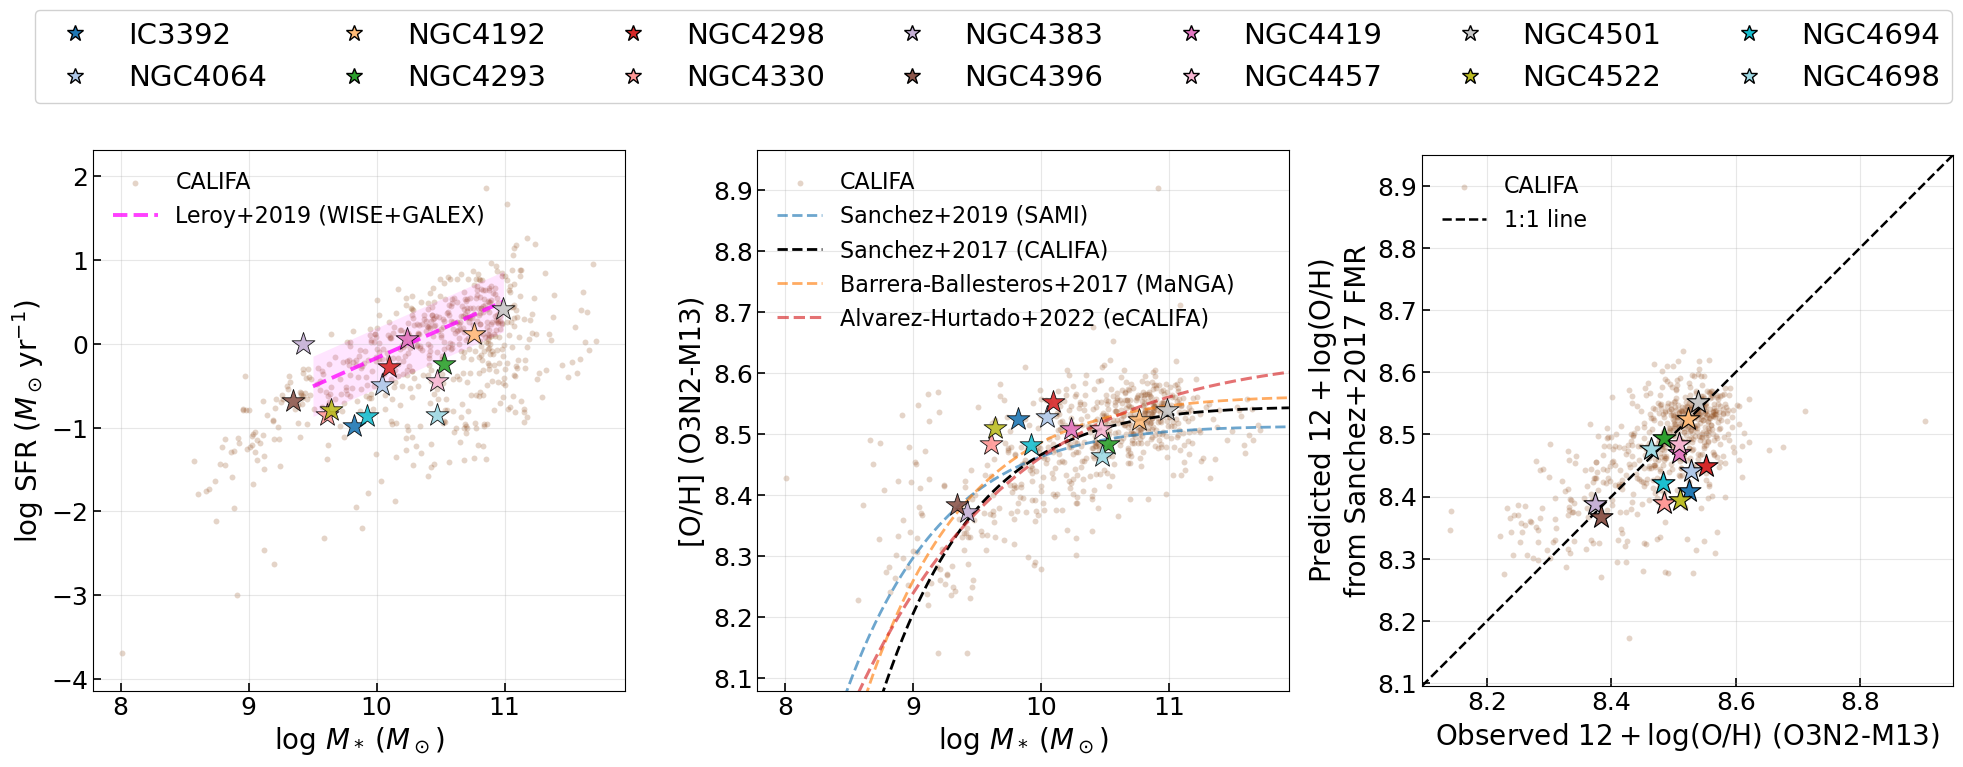

Subplot 1 (Integrated SFMS): 14 galaxies
Subplot 2 (Integrated MZR, O3N2-M13 total region): 14 galaxies
Subplot 3 (Predicted vs observed O/H): 14 galaxies


In [14]:
# Cell 13 variant: 3-panel row, CALIFA points (not density), no 3D panel,
# and axis limits derived from CALIFA distributions.
# NOTE: this cell reads all required data from disk each run (no cached plot arrays).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from mauve_master_loader import load_mauve_master_properties
import re

# ------------------------------------------------------------------
# Standalone data loading with MAUVE integrated stellar mass and SFR
# read only from mauve_master_wiki.fits.
# ------------------------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]

MASTER_SAMPLE_PATH = Path("mauve_master_wiki.fits")
CALIFA_TABLE_PATH = Path("Sanchez2017TableB1.csv")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


MAUVE_LOGMSTAR, MAUVE_LOGSFR = load_mauve_master_properties(MASTER_SAMPLE_PATH)

print(f"Loaded MAUVE integrated properties from {MASTER_SAMPLE_PATH}:")
for gal in GALAXIES:
    key = normalize_galaxy_name(gal)
    m = MAUVE_LOGMSTAR.get(key)
    s = MAUVE_LOGSFR.get(key)
    m_str = "MISSING" if m is None else f"{m:.3f} [mauve_master_wiki.fits]"
    s_str = "MISSING" if s is None else f"{s:.3f} [mauve_master_wiki.fits]"
    print(f"  {gal}: logM*={m_str}; logSFR={s_str}")


def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from total region in SFR log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-M13: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None
        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception:
        return None


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun) from mauve_master_wiki.fits only."""
    return MAUVE_LOGMSTAR.get(normalize_galaxy_name(galaxy_name))


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1) from mauve_master_wiki.fits only."""
    return MAUVE_LOGSFR.get(normalize_galaxy_name(galaxy_name))


def load_califa_o3n2_m13(table_path):
    """Load CALIFA integrated properties: COLUMN2 log_Mass, COLUMN4 log_SFR, COLUMN6 OH_O3N2_M13."""
    if not table_path.exists():
        raise FileNotFoundError(f"Missing CALIFA table file: {table_path}")

    data = np.genfromtxt(
        table_path,
        delimiter=",",
        comments="#",
        usecols=(1, 3, 5),
        dtype=float,
        invalid_raise=False,
    )

    if data.ndim == 1:
        data = data.reshape(1, -1)

    logm = data[:, 0]
    logsfr = data[:, 1]
    oh = data[:, 2]
    valid_all = np.isfinite(logm) & np.isfinite(logsfr) & np.isfinite(oh)
    logm_valid = logm[valid_all]
    logsfr_valid = logsfr[valid_all]
    oh_valid = oh[valid_all]
    return logm_valid, logsfr_valid, logm_valid, oh_valid


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def <= 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_sanchez2019(logM, a=8.51, b=0.007, c=3.5):
    """Sanchez+2019 SAMI relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_sanchez2017(logM, a=8.54, b=0.011, c=3.5):
    """Sanchez+2017 CALIFA relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_barrera_ballesteros2017_m13(logM, a=8.56, b=0.005, c=4.0):
    """Barrera-Ballesteros+2017 MaNGA relation (O3N2-M13)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_alvarez_hurtado2022_m13(logM, a=8.63366, b=-17.56889, c=3.5):
    """eCALIFA exponential MZR (erratum coefficients), using x = log10(M*/Msun)."""
    x = np.asarray(logM, dtype=float)
    t = x - c
    return a + b * t * np.exp(-t)


def sanchez2017_fp_o3n2_m13(logMstar, logSFR, a=0.10, b=-0.020, c=8.246):
    """Sanchez+2017 Eq. (6) FP fit for O3N2-M13 calibrator."""
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)
    return a * (logMstar - 8) - b * logSFR + c


# Build integrated-data containers from mauve_master_wiki.fits and local metallicity logs.
sfms_masses = []
sfms_sfrs = []
sfms_names = []

mzr_masses = []
mzr_oh_total = []
mzr_names = []

for gal in GALAXIES:
    mass = get_integrated_stellar_mass(gal)
    sfr = get_integrated_sfr(gal)
    oh_total = extract_total_o3n2_m13_total_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_total is not None:
        mzr_masses.append(mass)
        mzr_oh_total.append(oh_total)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_total = np.array(mzr_oh_total)

galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(GALAXIES)))
galaxy_color_dict = dict(zip(GALAXIES, galaxy_colors))

# Build FMR rows from mauve_master_wiki.fits and local metallicity logs.
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_m13_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        continue

    Z_pred = sanchez2017_fp_o3n2_m13(logM, logSFR)
    deltaZ = Z_obs - Z_pred

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(deltaZ),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found from mauve_master_wiki.fits and local metallicity logs.")

# Shared CALIFA data
califa_logm_sfms, califa_logsfr, califa_logm_mzr, califa_oh = load_califa_o3n2_m13(CALIFA_TABLE_PATH)
califa_oh_pred = sanchez2017_fp_o3n2_m13(califa_logm_sfms, califa_logsfr)
print(f"CALIFA entries used (valid mass+SFR+O/H): {len(califa_logm_sfms)}")


def califa_limits(values, frac_pad=0.06, min_pad=0.02):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0.0, 1.0)
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    span = vmax - vmin
    if span == 0:
        pad = max(min_pad, 0.05 * max(1.0, abs(vmin)))
    else:
        pad = max(min_pad, frac_pad * span)
    return (vmin - pad, vmax + pad)


sfms_xlim = califa_limits(califa_logm_sfms, frac_pad=0.06, min_pad=0.05)
sfms_ylim = califa_limits(califa_logsfr, frac_pad=0.08, min_pad=0.08)
mzr_xlim = califa_limits(califa_logm_mzr, frac_pad=0.06, min_pad=0.05)
mzr_ylim = califa_limits(califa_oh, frac_pad=0.08, min_pad=0.01)
right_min, right_max = califa_limits(
    np.concatenate([
        np.asarray(califa_oh, dtype=float),
        np.asarray(califa_oh_pred, dtype=float),
    ]),
    frac_pad=0.06,
    min_pad=0.01,
)

fig, (ax_sfms, ax_mzr, ax_right) = plt.subplots(
    1, 3, figsize=(24, 7.4), gridspec_kw={"wspace": 0.25}
)

# ---------- Panel 1: Integrated SFMS (CALIFA points + MAUVE stars) ----------
ax_sfms.scatter(
    califa_logm_sfms,
    califa_logsfr,
    s=18,
    color="saddlebrown",
    alpha=0.23,
    linewidths=0,
    zorder=0,
    label="CALIFA",
)

for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, "tab:blue")
    ax_sfms.scatter(
        mass,
        sfr,
        s=300,
        marker="*",
        c=[color],
        alpha=0.9,
        edgecolors="black",
        linewidth=0.6,
        zorder=3,
    )

x_sfms = np.linspace(sfms_xlim[0], sfms_xlim[1], 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax_sfms.plot(x_sfms, y_l19, lw=2.8, ls="--", color="magenta", alpha=0.75, label="Leroy+2019 (WISE+GALEX)")
ax_sfms.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, color="magenta", alpha=0.10, linewidth=0)
# ax_sfms.plot(x_sfms, y_b23, lw=2, ls="--", alpha=0.65, label="Boselli+2023 (HRS, HI-def<=0.4)")
# ax_sfms.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)
ax_sfms.set_xlabel(r"$\log\,M_* \; (M_\odot)$", fontsize=20)
ax_sfms.set_ylabel(r"$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$", fontsize=20)
ax_sfms.set_xlim(*sfms_xlim)
ax_sfms.set_ylim(*sfms_ylim)
ax_sfms.grid(True, alpha=0.3)
ax_sfms.legend(frameon=False, loc="upper left", fontsize=16)

# ---------- Panel 2: Integrated MZR (CALIFA points + MAUVE stars) ----------
ax_mzr.scatter(
    califa_logm_mzr,
    califa_oh,
    s=18,
    color="saddlebrown",
    alpha=0.23,
    linewidths=0,
    zorder=0,
    label="CALIFA",
)

for mass, oh_total, gal in zip(mzr_masses, mzr_oh_total, mzr_names):
    color = galaxy_color_dict.get(gal, "tab:orange")
    ax_mzr.scatter(
        mass,
        oh_total,
        s=300,
        marker="*",
        c=[color],
        alpha=0.9,
        edgecolors="black",
        linewidth=0.6,
        zorder=3,
    )

x_mzr = np.linspace(mzr_xlim[0], mzr_xlim[1], 400)
ax_mzr.plot(x_mzr, mzr_sanchez2019(x_mzr), lw=2, ls="--", alpha=0.65, label="Sanchez+2019 (SAMI)", zorder=2)
ax_mzr.plot(x_mzr, mzr_sanchez2017(x_mzr), lw=2, ls="--", color="black", label="Sanchez+2017 (CALIFA)", zorder=2)
ax_mzr.plot(x_mzr, mzr_barrera_ballesteros2017_m13(x_mzr), lw=2, ls="--", alpha=0.65, label="Barrera-Ballesteros+2017 (MaNGA)", zorder=2)
ax_mzr.plot(x_mzr, mzr_alvarez_hurtado2022_m13(x_mzr), lw=2.2, ls="--", alpha=0.65, color="tab:red", label="Alvarez-Hurtado+2022 (eCALIFA)", zorder=2)
ax_mzr.set_xlabel(r"$\log\,M_* \; (M_\odot)$", fontsize=20)
ax_mzr.set_ylabel(r"[O/H] (O3N2-M13)", fontsize=20)
ax_mzr.set_xlim(*mzr_xlim)
ax_mzr.set_ylim(*mzr_ylim)
ax_mzr.grid(True, alpha=0.3)
ax_mzr.legend(frameon=False, loc="upper left", fontsize=16)

# ---------- Panel 3: Predicted vs observed (CALIFA points + MAUVE stars) ----------
ax_right.scatter(
    califa_oh,
    califa_oh_pred,
    s=18,
    color="saddlebrown",
    alpha=0.23,
    linewidths=0,
    zorder=0,
    label="CALIFA",
)

for r in rows:
    gal = r["gal"]
    zo = r["Z_obs"]
    zp = r["Z_pred"]
    point_color = galaxy_color_dict.get(gal, "white")
    ax_right.scatter(
        zo,
        zp,
        s=300,
        marker="*",
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=3,
    )

ax_right.plot(
    [right_min, right_max],
    [right_min, right_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
    zorder=2,
)
ax_right.set_xlim(right_min, right_max)
ax_right.set_ylim(right_min, right_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r"Observed $12+\log(\mathrm{O/H})$ (O3N2-M13)", fontsize=20)
ax_right.set_ylabel(r"Predicted $12+\log(\mathrm{O/H})$" "\n" r"from Sanchez+2017 FMR", fontsize=20)
ax_right.legend(frameon=False, loc="upper left", fontsize=16)

# Keep Cell 6's shared galaxy legend behavior (top-level figure legend).
plotted_galaxies = [gal for gal in GALAXIES if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0], [0], marker="*", color="none", linestyle="None", markersize=12,
        markerfacecolor=galaxy_color_dict.get(gal, "gray"), markeredgecolor="black"
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=min(len(plotted_galaxies), 7),
        fontsize=21,
        framealpha=0.9,
    )

fig.subplots_adjust(top=0.84, wspace=0.25)
fig.canvas.draw_idle()
# plt.savefig(output_dir / "SFMS_MZR_FMR_comparison.png", dpi=600, bbox_inches="tight")
# plt.savefig(output_dir / "SFMS_MZR_FMR_comparison.pdf", bbox_inches="tight")
plt.show()

print(f"Subplot 1 (Integrated SFMS): {len(sfms_names)} galaxies")
print(f"Subplot 2 (Integrated MZR, O3N2-M13 total region): {len(mzr_names)} galaxies")
print(f"Subplot 3 (Predicted vs observed O/H): {len(rows)} galaxies")

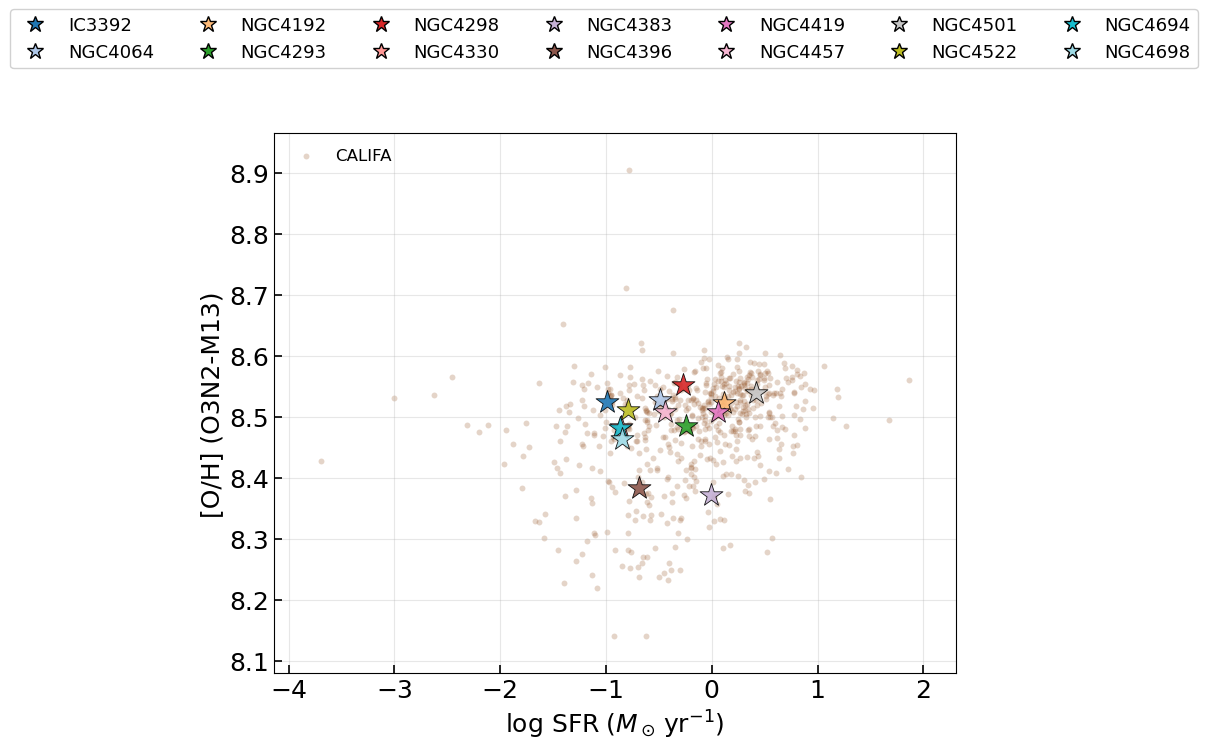

O/H vs SFR plot: 14 galaxies


In [15]:
# Cell 14 extension: O/H vs SFR using integrated values (CALIFA points + MAUVE stars)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if "rows" not in globals() or "galaxy_color_dict" not in globals():
    raise RuntimeError(
        "Run Cell 14 first so integrated arrays (rows, galaxy_color_dict) are available."
    )
if "califa_logsfr" not in globals() or "califa_oh" not in globals():
    raise RuntimeError(
        "Run Cell 14 first so CALIFA arrays (califa_logsfr, califa_oh) are available."
    )

def limits_with_padding(values, frac_pad=0.08, min_pad=0.02):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0.0, 1.0)
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    span = vmax - vmin
    if span == 0:
        pad = max(min_pad, 0.05 * max(1.0, abs(vmin)))
    else:
        pad = max(min_pad, frac_pad * span)
    return (vmin - pad, vmax + pad)

fig, ax = plt.subplots(figsize=(8.8, 7.4))

ax.scatter(
    califa_logsfr,
    califa_oh,
    s=18,
    color="saddlebrown",
    alpha=0.23,
    linewidths=0,
    zorder=0,
    label="CALIFA",
)

for r in rows:
    gal = r["gal"]
    x_sfr = r["logSFR"]
    y_oh = r["Z_obs"]
    point_color = galaxy_color_dict.get(gal, "tab:blue")
    ax.scatter(
        x_sfr,
        y_oh,
        s=300,
        marker="*",
        c=[point_color],
        alpha=0.9,
        edgecolors="black",
        linewidth=0.6,
        zorder=3,
    )

ax.set_xlim(*limits_with_padding(califa_logsfr, frac_pad=0.08, min_pad=0.08))
ax.set_ylim(*limits_with_padding(califa_oh, frac_pad=0.08, min_pad=0.01))
ax.set_xlabel(r"$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$")
ax.set_ylabel(r"[O/H] (O3N2-M13)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, loc="upper left")

if "GALAXIES" in globals():
    plotted_galaxies = [gal for gal in GALAXIES if any(r["gal"] == gal for r in rows)]
else:
    plotted_galaxies = sorted({r["gal"] for r in rows})

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="*",
        color="none",
        linestyle="None",
        markersize=12,
        markerfacecolor=galaxy_color_dict.get(gal, "gray"),
        markeredgecolor="black",
    )
    for gal in plotted_galaxies
]

if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(len(plotted_galaxies), 7),
        fontsize=13,
        framealpha=0.9,
    )

fig.subplots_adjust(top=0.84)
plt.show()

print(f"O/H vs SFR plot: {len(rows)} galaxies")

Simulation sample with finite propagated uncertainties: 769918
Fraction retained after requiring finite propagated uncertainties: 1.000
The same 6 global mass bins are used for the observed sample and all null realizations.
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.91-  7.24     7.074     53702     -0.3169      0.0027      0.0077      0.0128
  2    7.24-  7.57     7.407     89438     -0.1873      0.0108      0.0137      0.0166
  3    7.57-  7.91     7.740    173644      0.1106      0.0049      0.0070      0.0094
  4    7.91-  8.24     8.073    211465      0.2576      0.0008      0.0033      0.0056
  5    8.24-  8.57     8.406    127062      0.2928     -0.0040     -0.0009      0.0022
  6    8.57-  8.91     8.739     76111      0.2432     -0.0053     -0.0015      0.0022


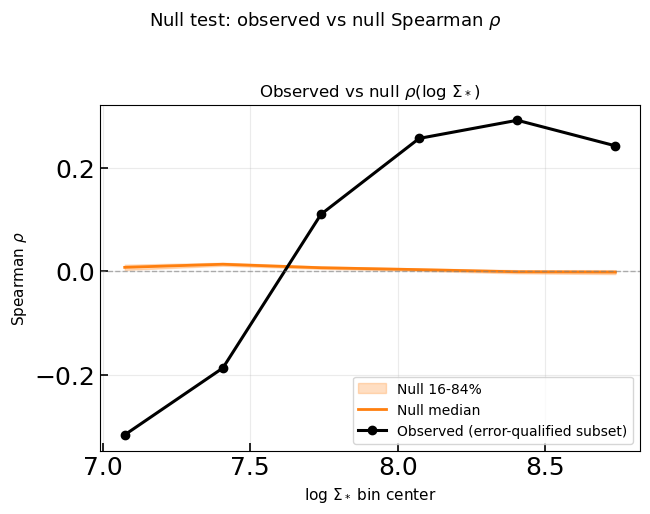

Saved: Plot_Paper_1_referee/sec34_null_test_global.png


In [16]:
# ------------------------------------------------------------------
# Strengthened null test following Sanchez et al. (2021) Sec. 3.4 (Spearman rho only)
# Self-contained: loads data and builds reference curve inside this cell
# ------------------------------------------------------------------
import importlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import sec34_null_test as sec34

# Ensure the latest on-disk helper code is used in this kernel session.
sec34 = importlib.reload(sec34)
compute_rho_curve_from_pipeline = sec34.compute_rho_curve_from_pipeline
load_o3n2_m13_hii_sample_with_errors = sec34.load_o3n2_m13_hii_sample_with_errors
make_percentile_mass_bin_edges = sec34.make_percentile_mass_bin_edges
mask_sample = sec34.mask_sample
plot_sec34_style_null_test = sec34.plot_sec34_style_null_test
print_sec34_summary = sec34.print_sec34_summary
run_sec34_style_null_test = sec34.run_sec34_style_null_test

sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})

finite_obs_mask = (
    np.isfinite(sec34_full["log_sigma_star"])
    & np.isfinite(sec34_full["log_sigma_sfr"])
    & np.isfinite(sec34_full["oh"])
)
sec34_obs = mask_sample(sec34_full, finite_obs_mask)

global_mass_bin_edges = make_percentile_mass_bin_edges(
    sec34_obs["log_sigma_star"],
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)

global_check = compute_rho_curve_from_pipeline(
    sec34_obs["log_sigma_star"],
    sec34_obs["log_sigma_sfr"],
    sec34_obs["oh"],
    mass_bin_edges=global_mass_bin_edges,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

global_sigM = np.asarray(sec34_obs["log_sigma_star"], dtype=float)
global_sigSFR = np.asarray(sec34_obs["log_sigma_sfr"], dtype=float)
global_oh = np.asarray(sec34_obs["oh"], dtype=float)
global_bin_centers = np.asarray(global_check["centers"], dtype=float)
global_rho_values = np.asarray(global_check["rho"], dtype=float)

finite_error_mask = (
    finite_obs_mask
    & np.isfinite(sec34_full["sigma_log_sfr"])
    & np.isfinite(sec34_full["sigma_oh"])
)
sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print(f"Simulation sample with finite propagated uncertainties: {sec34_sample['log_sigma_star'].size}")
print(
    "Fraction retained after requiring finite propagated uncertainties: "
    f"{sec34_sample['log_sigma_star'].size / max(global_sigM.size, 1):.3f}"
)
print("The same 6 global mass bins are used for the observed sample and all null realizations.")
print("=" * 100)

sec34_result = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result)
fig = plot_sec34_style_null_test(sec34_result, panel_mode="rho_only")
if fig is None:
    fig = plt.gcf()

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "sec34_null_test_global.png", dpi=600, bbox_inches="tight")
fig.savefig(save_dir / "sec34_null_test_global.pdf", bbox_inches="tight")
print(f"Saved: {save_dir / 'sec34_null_test_global.png'}")

/Users/Igniz/Desktop/ICRAR/extended/sec34_null_test.py:495: RuntimeWarning: All-NaN slice encountered
  "median_rho": np.nanmedian(rho_matrix, axis=0),
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


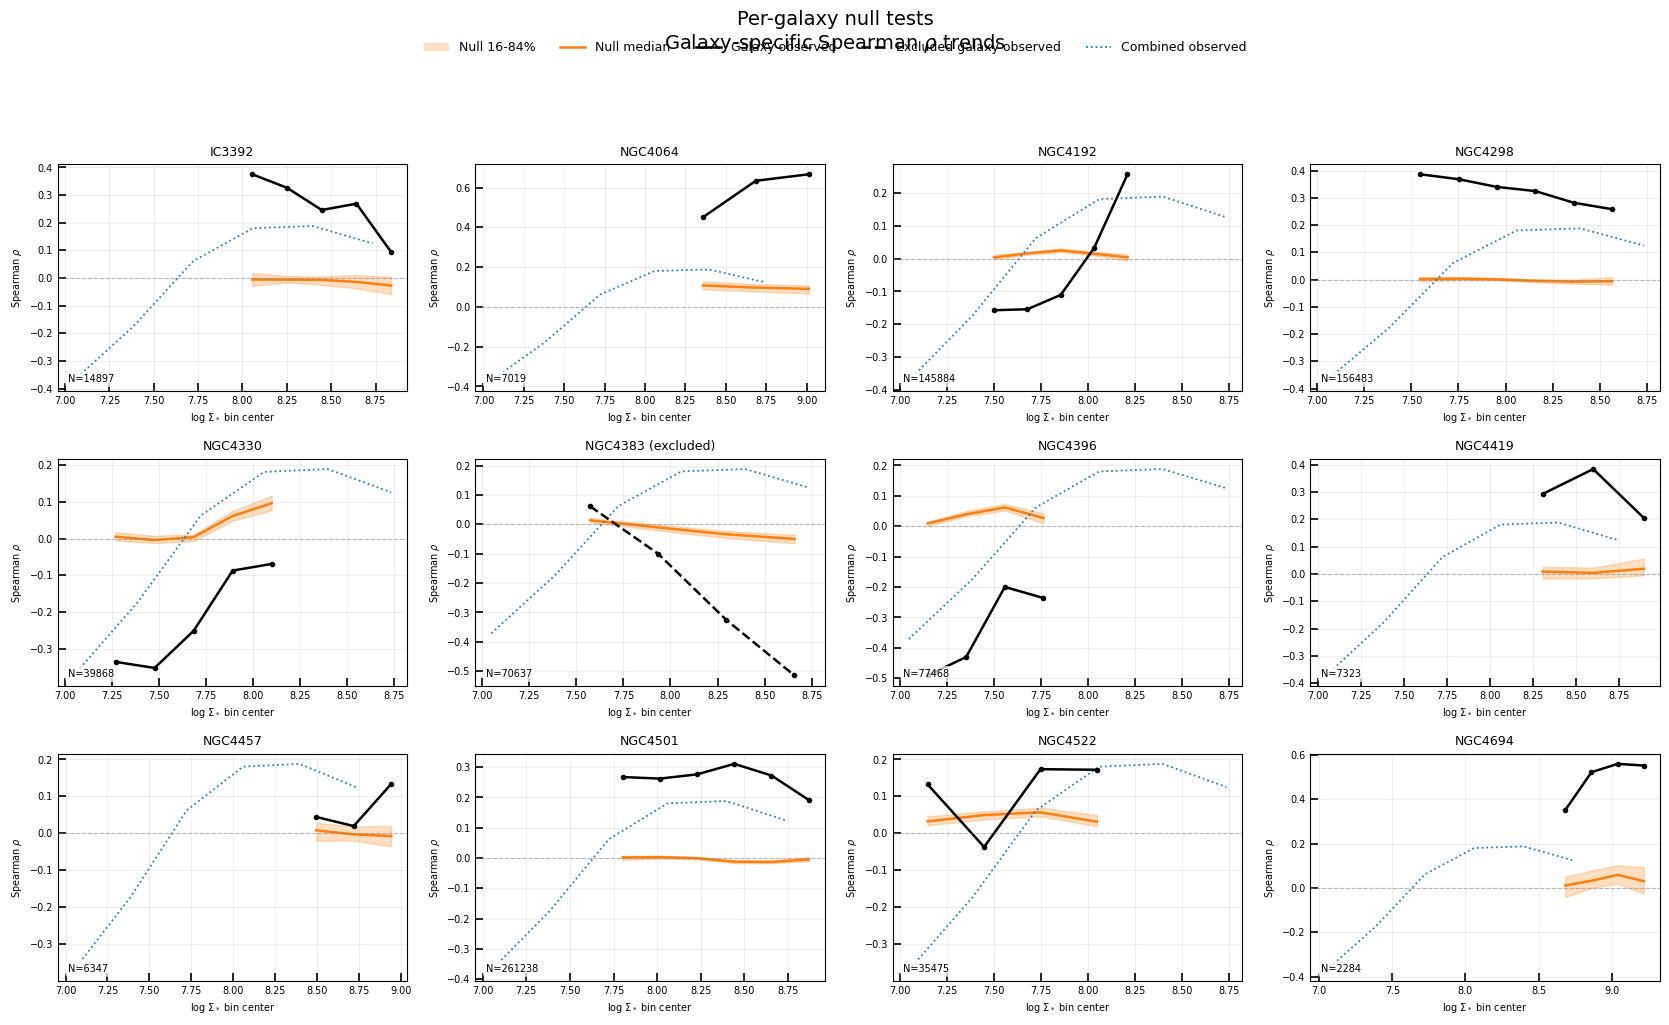

Saved: Plot_Paper_1_referee/sec34_per_galaxy_grid.png


In [17]:
# ------------------------------------------------------------------
# Per-galaxy Sec. 3.4-style null tests (Spearman rho only)
# Self-contained: computes combined observed reference curve in-cell
# ------------------------------------------------------------------
import importlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import sec34_null_test as sec34

# Ensure the latest on-disk helper code is used in this kernel session.
sec34 = importlib.reload(sec34)
compute_rho_curve_from_pipeline = sec34.compute_rho_curve_from_pipeline
list_available_galaxies = sec34.list_available_galaxies
load_o3n2_m13_hii_sample_with_errors = sec34.load_o3n2_m13_hii_sample_with_errors
make_percentile_mass_bin_edges = sec34.make_percentile_mass_bin_edges
mask_sample = sec34.mask_sample
plot_sec34_galaxy_grid = sec34.plot_sec34_galaxy_grid
run_sec34_style_null_test_by_galaxy = sec34.run_sec34_style_null_test_by_galaxy

all_sec34 = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies=())

finite_obs_mask_all = (
    np.isfinite(all_sec34["log_sigma_star"])
    & np.isfinite(all_sec34["log_sigma_sfr"])
    & np.isfinite(all_sec34["oh"])
)
all_sec34_obs = mask_sample(all_sec34, finite_obs_mask_all)

finite_error_mask_all = (
    finite_obs_mask_all
    & np.isfinite(all_sec34["sigma_log_sfr"])
    & np.isfinite(all_sec34["sigma_oh"])
)
all_sec34 = mask_sample(all_sec34, finite_error_mask_all)

global_mass_bin_edges_all = make_percentile_mass_bin_edges(
    all_sec34_obs["log_sigma_star"],
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)
combined_check = compute_rho_curve_from_pipeline(
    all_sec34_obs["log_sigma_star"],
    all_sec34_obs["log_sigma_sfr"],
    all_sec34_obs["oh"],
    mass_bin_edges=global_mass_bin_edges_all,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

galaxy_order = [g for g in list_available_galaxies() if g not in ("NGC4293", "NGC4698")]
per_gal_sec34 = run_sec34_style_null_test_by_galaxy(
    all_sec34,
    galaxy_order=galaxy_order,
    n_bins=6,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.05,
)

combined_curve = {
    "centers": np.asarray(combined_check["centers"], dtype=float),
    "rho": np.asarray(combined_check["rho"], dtype=float),
    "label": "Combined observed",
}

fig = plot_sec34_galaxy_grid(
    per_gal_sec34["galaxy_results"],
    galaxy_order=per_gal_sec34["galaxy_order"],
    combined_curve=combined_curve,
    excluded_galaxies={"NGC4383"},
    max_cols=12,
    panel_mode="rho_only",
)
if fig is None:
    fig = plt.gcf()

if fig.legends:
    # Move the top legend lower by adjusting bbox_to_anchor
    fig.legends[0].set_bbox_to_anchor((0.5, 0.93))

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "sec34_per_galaxy_grid.png", dpi=600, bbox_inches="tight")
fig.savefig(save_dir / "sec34_per_galaxy_grid.pdf", bbox_inches="tight")
print(f"Saved: {save_dir / 'sec34_per_galaxy_grid.png'}")

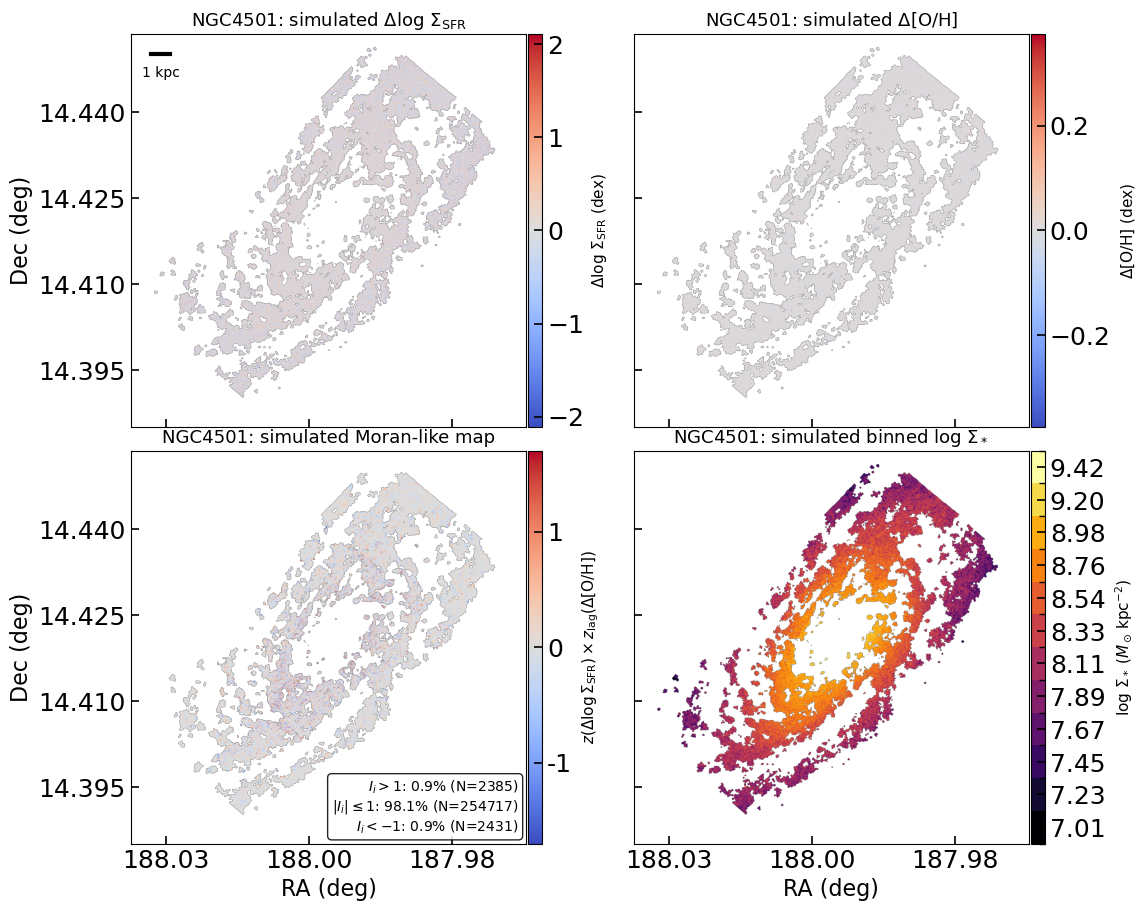

Saved: Plot_Paper_1_referee/sec34_simulated_moran_2x2_NGC4501.png


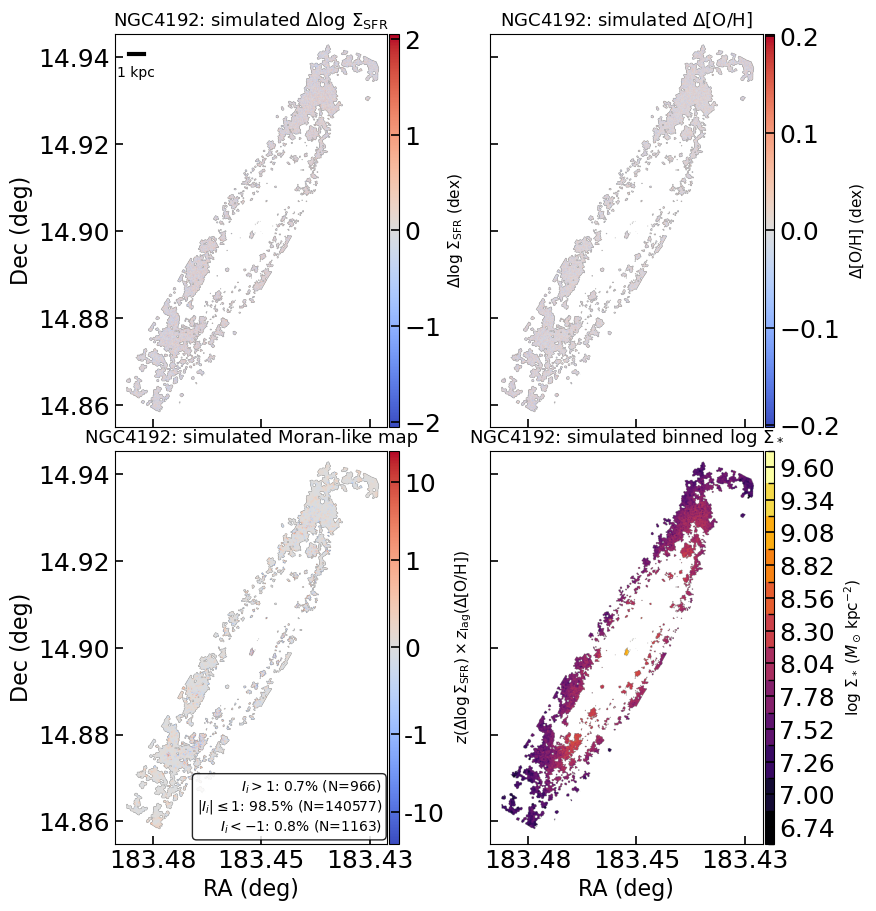

Saved: Plot_Paper_1_referee/sec34_simulated_moran_2x2_NGC4192.png


In [18]:
# ------------------------------------------------------------------
# Simulated 2x2 Moran-style maps for selected galaxies
# ------------------------------------------------------------------
from pathlib import Path
import matplotlib.pyplot as plt
from sec34_null_test import build_simulated_moran_maps_for_galaxy, plot_simulated_moran_2x2

simulated_moran_targets = {
    "NGC4501": 4501,
    "NGC4192": 4192,
}

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)

simulated_moran_results = {}
for galaxy, seed in simulated_moran_targets.items():
    simulated_moran_results[galaxy] = build_simulated_moran_maps_for_galaxy(
        galaxy,
        random_seed=seed,
        null_n_bins=6,
        offset_n_bins=12,
        include_mass_error_proxy=True,
        mass_error_base=0.05,
        neighbourhood="queen",
        threshold=1.0,
    )
    fig = plot_simulated_moran_2x2(simulated_moran_results[galaxy])
    if fig is None:
        fig = plt.gcf()

    fig.savefig(save_dir / f"sec34_simulated_moran_2x2_{galaxy}.png", dpi=600, bbox_inches="tight")
    fig.savefig(save_dir / f"sec34_simulated_moran_2x2_{galaxy}.pdf", bbox_inches="tight")
    print(f"Saved: {save_dir / f'sec34_simulated_moran_2x2_{galaxy}.png'}")

Simulation sample with finite propagated uncertainties: 769918
Fraction retained after requiring finite propagated uncertainties: 1.000
The same 6 global mass bins are used for the observed sample and all null realizations.
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.91-  7.24     7.074     53702     -0.3169      0.0027      0.0076      0.0128
  2    7.24-  7.57     7.407     89438     -0.1873      0.0109      0.0138      0.0166
  3    7.57-  7.91     7.740    173644      0.1106      0.0049      0.0070      0.0094
  4    7.91-  8.24     8.073    211465      0.2576      0.0009      0.0034      0.0056
  5    8.24-  8.57     8.406    127062      0.2928     -0.0041     -0.0008      0.0022
  6    8.57-  8.91     8.739     76111      0.2432     -0.0052     -0.0015      0.0023
Direct correlated error fit: sigma([O/H]) = 0.001091 + 1.065824 * sigma(log Sigma_SFR)
Simulated error scale factor: x1


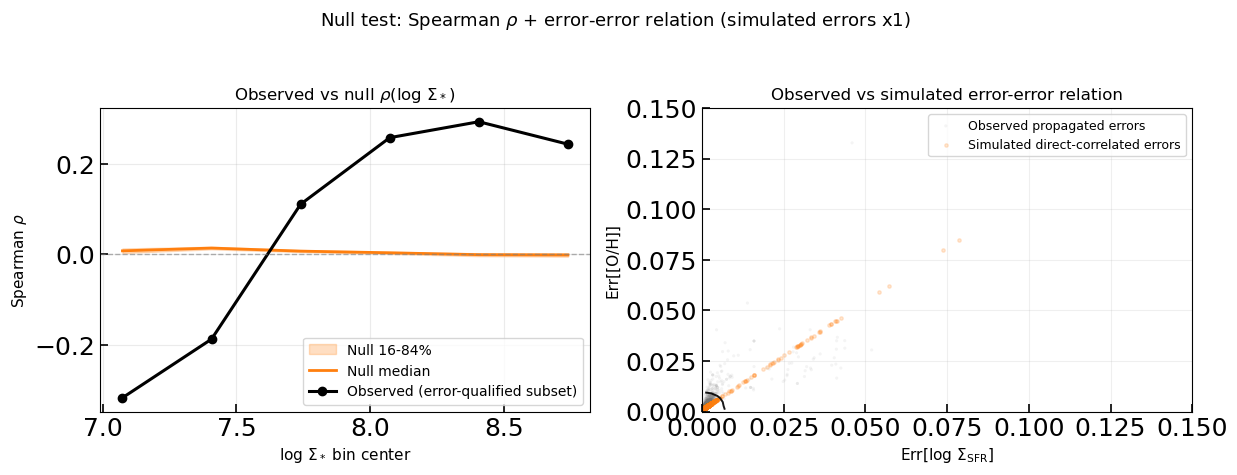

Saved: Plot_Paper_1_referee/sec34_null_test_x1.png


In [19]:
# ------------------------------------------------------------------
# Strengthened null test following Sanchez et al. (2021) Sec. 3.4
# (20260408 module variant, Spearman rho + error-error only)
# ------------------------------------------------------------------
import importlib
import numpy as np
from pathlib import Path

import sec34_null_test_20260408 as sec34

# Ensure the latest on-disk helper code is used in this kernel session.
sec34 = importlib.reload(sec34)

sec34_full = sec34.load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})

finite_obs_mask = (
    np.isfinite(sec34_full["log_sigma_star"])
    & np.isfinite(sec34_full["log_sigma_sfr"])
    & np.isfinite(sec34_full["oh"])
)
sec34_obs = sec34.mask_sample(sec34_full, finite_obs_mask)

global_mass_bin_edges = sec34.make_percentile_mass_bin_edges(
    sec34_obs["log_sigma_star"],
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)

global_check = sec34.compute_rho_curve_from_pipeline(
    sec34_obs["log_sigma_star"],
    sec34_obs["log_sigma_sfr"],
    sec34_obs["oh"],
    mass_bin_edges=global_mass_bin_edges,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

global_sigM = np.asarray(sec34_obs["log_sigma_star"], dtype=float)
global_bin_centers = np.asarray(global_check["centers"], dtype=float)
global_rho_values = np.asarray(global_check["rho"], dtype=float)

finite_error_mask = (
    finite_obs_mask
    & np.isfinite(sec34_full["sigma_log_sfr"])
    & np.isfinite(sec34_full["sigma_oh"])
)
sec34_sample = sec34.mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print(f"Simulation sample with finite propagated uncertainties: {sec34_sample['log_sigma_star'].size}")
print(
    "Fraction retained after requiring finite propagated uncertainties: "
    f"{sec34_sample['log_sigma_star'].size / max(global_sigM.size, 1):.3f}"
)
print("The same 6 global mass bins are used for the observed sample and all null realizations.")
print("=" * 100)

sec34_result = sec34.run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

sec34.print_sec34_summary(sec34_result)
fig = sec34.plot_sec34_style_null_test(sec34_result, panel_mode="rho_and_error")

if fig is None or len(getattr(fig, "axes", [])) == 0:
    raise RuntimeError("plot_sec34_style_null_test did not return a valid figure handle.")

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "sec34_null_test_x1.png", dpi=600, bbox_inches="tight")
fig.savefig(save_dir / "sec34_null_test_x1.pdf", bbox_inches="tight")
print(f"Saved: {save_dir / 'sec34_null_test_x1.png'}")

Running direct correlated error stress test with simulated errors x10
Sec. 3.4-style null test summary
Bin       Mass range    center         N     obs rho    null p16    null med    null p84
  1    6.91-  7.24     7.074     53702     -0.3169      0.0030      0.0077      0.0116
  2    7.24-  7.57     7.407     89438     -0.1873      0.0104      0.0128      0.0160
  3    7.57-  7.91     7.740    173644      0.1106      0.0044      0.0067      0.0088
  4    7.91-  8.24     8.073    211465      0.2576      0.0006      0.0029      0.0055
  5    8.24-  8.57     8.406    127062      0.2928     -0.0039     -0.0011      0.0024
  6    8.57-  8.91     8.739     76111      0.2432     -0.0053     -0.0011      0.0023
Direct correlated error fit: sigma([O/H]) = 0.001091 + 1.065824 * sigma(log Sigma_SFR)
Simulated error scale factor: x10


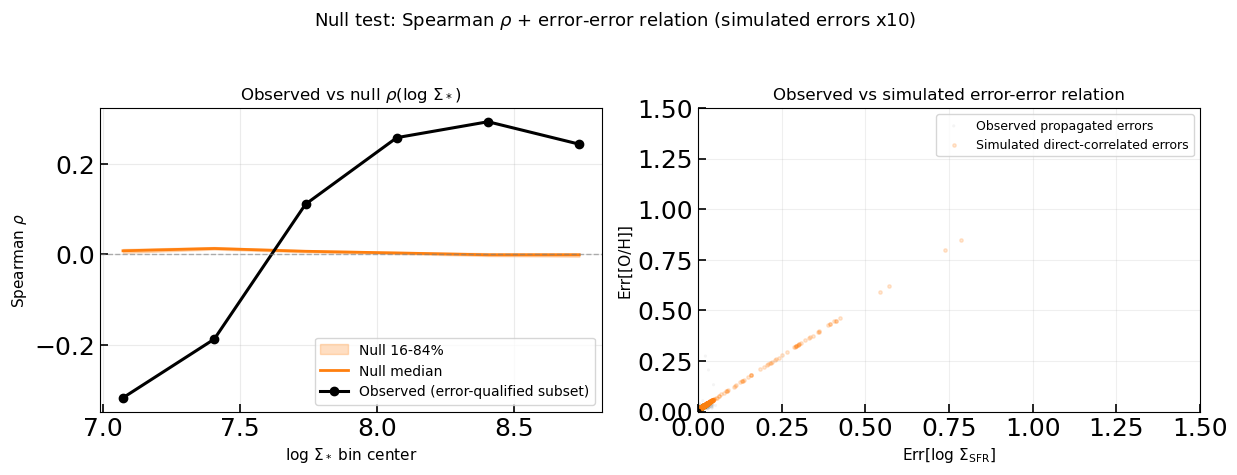

Saved: Plot_Paper_1_referee/sec34_null_test_x10.png


In [20]:
# ------------------------------------------------------------------
# Direct correlated error stress test: simulated errors x10 (Spearman rho + error-error only)
# Self-contained: loads sample and computes mass bins inside this cell
# ------------------------------------------------------------------
import importlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import sec34_null_test_20260408 as sec34

# Ensure the latest on-disk helper code is used in this kernel session.
sec34 = importlib.reload(sec34)
compute_rho_curve_from_pipeline = sec34.compute_rho_curve_from_pipeline
load_o3n2_m13_hii_sample_with_errors = sec34.load_o3n2_m13_hii_sample_with_errors
make_percentile_mass_bin_edges = sec34.make_percentile_mass_bin_edges
mask_sample = sec34.mask_sample
plot_sec34_style_null_test = sec34.plot_sec34_style_null_test
print_sec34_summary = sec34.print_sec34_summary
run_sec34_style_null_test = sec34.run_sec34_style_null_test

sec34_full = load_o3n2_m13_hii_sample_with_errors(excluded_galaxies={"NGC4383"})

finite_obs_mask = (
    np.isfinite(sec34_full["log_sigma_star"])
    & np.isfinite(sec34_full["log_sigma_sfr"])
    & np.isfinite(sec34_full["oh"])
)
sec34_obs = mask_sample(sec34_full, finite_obs_mask)

global_mass_bin_edges = make_percentile_mass_bin_edges(
    sec34_obs["log_sigma_star"],
    n_bins=6,
    lower_percentile=2.5,
    upper_percentile=97.5,
)
combined_check = compute_rho_curve_from_pipeline(
    sec34_obs["log_sigma_star"],
    sec34_obs["log_sigma_sfr"],
    sec34_obs["oh"],
    mass_bin_edges=global_mass_bin_edges,
    bin_width=0.2,
    min_unique=20,
    min_trend_points=3,
)

finite_error_mask = (
    finite_obs_mask
    & np.isfinite(sec34_full["sigma_log_sfr"])
    & np.isfinite(sec34_full["sigma_oh"])
)
sec34_sample = mask_sample(sec34_full, finite_error_mask)

print("=" * 100)
print("Running direct correlated error stress test with simulated errors x10")
print("=" * 100)

sec34_result_x10 = run_sec34_style_null_test(
    sec34_sample,
    mass_bin_edges=global_mass_bin_edges,
    n_realizations=100,
    random_seed=726,
    error_scale=10.0,
    include_mass_error_proxy=True,
    mass_error_base=0.01,
)

print_sec34_summary(sec34_result_x10)
fig = plot_sec34_style_null_test(sec34_result_x10, panel_mode="rho_and_error")

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "sec34_null_test_x10.png", dpi=600, bbox_inches="tight")
fig.savefig(save_dir / "sec34_null_test_x10.pdf", bbox_inches="tight")
print(f"Saved: {save_dir / 'sec34_null_test_x10.png'}")

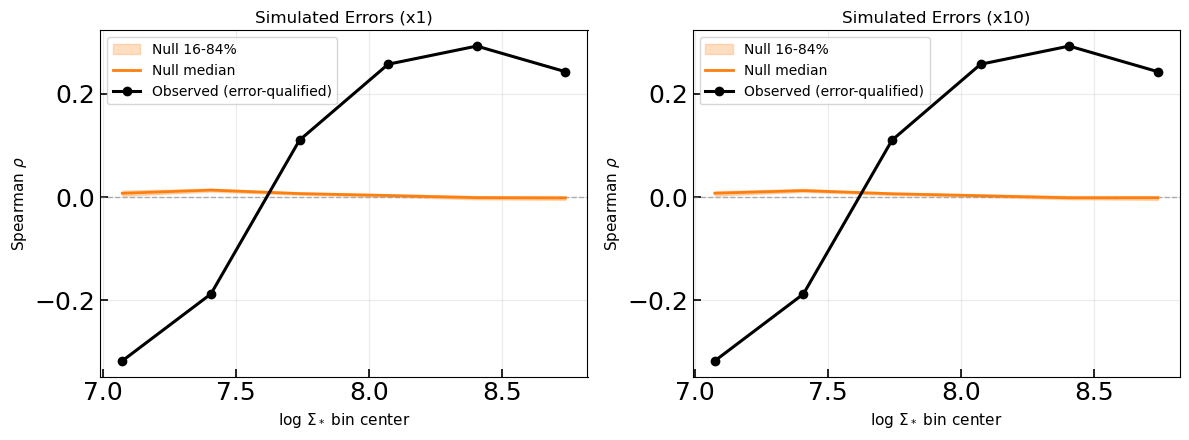

Saved combined plot to Plot_Paper_1_referee/sec34_null_test_x1_x10.png


In [21]:
# ------------------------------------------------------------------
# Combined Null Test Plot (1x2): rho vs log_sigma_* for x1 and x10
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
from pathlib import Path

def plot_rho_on_ax(ax, result, title):
    observed = result["observed"]
    centers = observed["centers"]
    
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.fill_between(
        centers,
        result["null"]["p16_rho"],
        result["null"]["p84_rho"],
        color="tab:orange",
        alpha=0.25,
        label="Null 16-84%",
    )
    ax.plot(
        centers,
        result["null"]["median_rho"],
        color="tab:orange",
        linewidth=2.0,
        label="Null median",
    )
    ax.plot(
        centers,
        observed["rho"],
        color="black",
        linewidth=2.2,
        marker="o",
        label="Observed (error-qualified)",
    )
    ax.set_xlabel(r"$\log\,\Sigma_*$ bin center", fontsize=11)
    ax.set_ylabel(r"Spearman $\rho$", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=10)

fig_combined, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

plot_rho_on_ax(ax1, sec34_result, "Simulated Errors (x1)")
plot_rho_on_ax(ax2, sec34_result_x10, "Simulated Errors (x10)")

plt.tight_layout()
plt.show()

output_dir = Path("Plot_Paper_1_referee")
save_dir = output_dir
save_dir.mkdir(parents=True, exist_ok=True)
fig_combined.savefig(save_dir / "sec34_null_test_x1_x10.png", dpi=600, bbox_inches="tight")
fig_combined.savefig(save_dir / "sec34_null_test_x1_x10.pdf", bbox_inches="tight")
print(f"Saved combined plot to {save_dir / 'sec34_null_test_x1_x10.png'}")

SNR200 root: /Users/Igniz/Desktop/ICRAR/extended/SNR200
Original search roots:
  /Users/Igniz/Desktop/ICRAR/extended
  /Users/Igniz/Desktop/ICRAR
  /Users/Igniz/Desktop


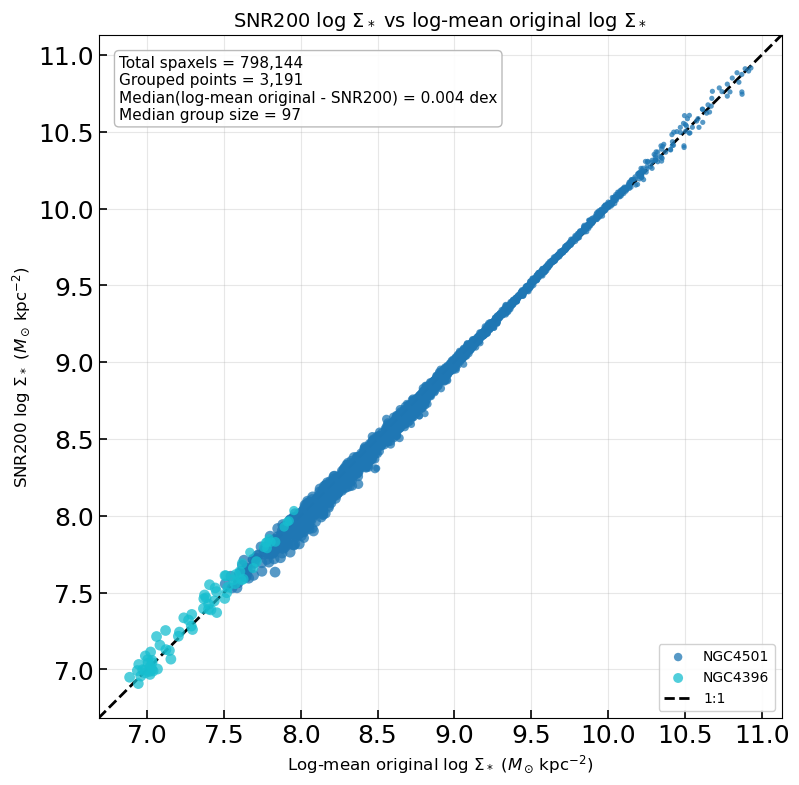

Matched original files:
  NGC4501: /Users/Igniz/Desktop/ICRAR/extended/NGC4501_spatial_binning_maps_extended.fits (643,053 spaxels -> 3,120 grouped points)
  NGC4396: /Users/Igniz/Desktop/ICRAR/extended/NGC4396_spatial_binning_maps_extended.fits (155,091 spaxels -> 71 grouped points)


In [22]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def dedupe_paths(paths):
    unique_paths = []
    seen = set()
    for path in paths:
        path = path.resolve()
        if path.exists() and path not in seen:
            unique_paths.append(path)
            seen.add(path)
    return unique_paths

def find_snr200_root():
    cwd = Path.cwd().resolve()
    candidate_dirs = [cwd, cwd / 'SNR200', cwd.parent / 'SNR200']
    for directory in dedupe_paths(candidate_dirs):
        if any(directory.glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits')):
            return directory
    raise FileNotFoundError('Could not find any *_v3tk_SNR200_spatial_binning_maps_extended.fits files.')

def find_original_file(gal, roots):
    direct_names = [
        f'{gal}_v3tk_spatial_binning_maps_extended.fits',
        f'{gal}_spatial_binning_maps_extended.fits',
    ]

    for root in roots:
        for name in direct_names:
            candidate = root / name
            if candidate.exists():
                return candidate

    for root in roots:
        for name in direct_names:
            matches = sorted(
                path for path in root.rglob(name)
                if 'SNR200' not in path.name and 'SNR200' not in str(path.parent)
            )
            if matches:
                return matches[0]

    return None

def log_mean_from_log_values(log_values):
    linear_values = np.power(10.0, log_values)
    return np.log10(np.mean(linear_values))

SNR200_ROOT = find_snr200_root()
ORIGINAL_ROOTS = dedupe_paths([
    SNR200_ROOT.parent,
    SNR200_ROOT.parent / 'original',
    Path.cwd(),
    *list(Path.cwd().parents)[:2],
])

snr200_files = sorted(SNR200_ROOT.glob('*_v3tk_SNR200_spatial_binning_maps_extended.fits'))
galaxies = [path.name.split('_')[0] for path in snr200_files]

print(f'SNR200 root: {SNR200_ROOT}')
print('Original search roots:')
for root in ORIGINAL_ROOTS:
    print(f'  {root}')

matched = []
missing = []

for gal in galaxies:
    snr200_file = SNR200_ROOT / f'{gal}_v3tk_SNR200_spatial_binning_maps_extended.fits'
    original_file = find_original_file(gal, ORIGINAL_ROOTS)

    if original_file is None:
        missing.append(gal)
        continue

    with fits.open(original_file) as h_orig, fits.open(snr200_file) as h_snr:
        original_mass = h_orig['LOGMASS_SURFACE_DENSITY'].data
        snr200_mass = h_snr['LOGMASS_SURFACE_DENSITY'].data

    common_mask = np.isfinite(original_mass) & np.isfinite(snr200_mass)
    if np.any(common_mask):
        original_mass_valid = original_mass[common_mask].ravel()
        snr200_mass_valid = snr200_mass[common_mask].ravel()

        sort_idx = np.argsort(snr200_mass_valid, kind='stable')
        snr200_mass_sorted = snr200_mass_valid[sort_idx]
        original_mass_sorted = original_mass_valid[sort_idx]

        unique_snr200_mass, start_idx, group_counts = np.unique(
            snr200_mass_sorted,
            return_index=True,
            return_counts=True,
        )
        grouped_original_log_mean = np.array([
            log_mean_from_log_values(original_mass_sorted[start:start + count])
            for start, count in zip(start_idx, group_counts)
        ])

        matched.append({
            'gal': gal,
            'original_file': original_file,
            'snr200_mass': unique_snr200_mass,
            'original_log_mean': grouped_original_log_mean,
            'group_counts': group_counts,
            'spaxel_count': len(original_mass_valid),
        })

if not matched:
    tried_names = ', '.join(f'{gal}_v3tk_spatial_binning_maps_extended.fits' for gal in galaxies)
    raise FileNotFoundError(
        'No original spatial-binning extended FITS files were found. '
        'Put the original files near the SNR200 directory or edit ORIGINAL_ROOTS in this cell. '
        f'Tried names like: {tried_names}'
    )

matched = sorted(matched, key=lambda item: (item['gal'] == 'NGC4396', item['gal']))

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(matched), 1)))

all_original_log_mean = []
all_snr200 = []
all_group_counts = []
total_spaxels = 0

for color, item in zip(colors, matched):
    x = item['original_log_mean']
    y = item['snr200_mass']
    counts = item['group_counts']

    all_original_log_mean.append(x)
    all_snr200.append(y)
    all_group_counts.append(counts)
    total_spaxels += item['spaxel_count']

    zorder = 5 if item['gal'] == 'NGC4396' else 4
    point_sizes = np.clip(10 + 2 * np.sqrt(counts), 14, 60)
    ax.scatter(
        x,
        y,
        s=point_sizes,
        alpha=0.75,
        color=color,
        edgecolors='none',
        rasterized=True,
        zorder=zorder,
        label=item['gal'],
    )

all_original_log_mean = np.concatenate(all_original_log_mean)
all_snr200 = np.concatenate(all_snr200)
all_group_counts = np.concatenate(all_group_counts)
delta_mass = all_original_log_mean - all_snr200

min_mass = np.nanmin([all_original_log_mean.min(), all_snr200.min()])
max_mass = np.nanmax([all_original_log_mean.max(), all_snr200.max()])
pad = 0.05 * (max_mass - min_mass if max_mass > min_mass else 1.0)
plot_limits = (min_mass - pad, max_mass + pad)

ax.plot(plot_limits, plot_limits, 'k--', linewidth=2, label='1:1')
ax.set_xlim(*plot_limits)
ax.set_ylim(*plot_limits)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'Log-mean original $\log\,\Sigma_*$ ($M_\odot\,\mathrm{kpc}^{-2}$)', fontsize=12)
ax.set_ylabel(r'SNR200 $\log\,\Sigma_*$ ($M_\odot\,\mathrm{kpc}^{-2}$)', fontsize=12)
ax.set_title(r'SNR200 $\log\,\Sigma_*$ vs log-mean original $\log\,\Sigma_*$', fontsize=14)

summary_text = (
    f'Total spaxels = {total_spaxels:,}\n'
    f'Grouped points = {len(all_snr200):,}\n'
    f'Median(log-mean original - SNR200) = {np.nanmedian(delta_mass):.3f} dex\n'
    f'Median group size = {int(np.nanmedian(all_group_counts))}'
)
ax.text(
    0.03,
    0.97,
    summary_text,
    transform=ax.transAxes,
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='0.7'),
)

ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig(output_dir / "original_logmean_vs_snr200_mass_comparison.png", dpi=600, bbox_inches="tight")
plt.savefig(output_dir / "original_logmean_vs_snr200_mass_comparison.pdf", bbox_inches="tight")
plt.show()

print('Matched original files:')
for item in matched:
    print(
        f"  {item['gal']}: {item['original_file']} "
        f"({item['spaxel_count']:,} spaxels -> {len(item['snr200_mass']):,} grouped points)"
    )
if missing:
    print(f"Missing original files for: {', '.join(missing)}")


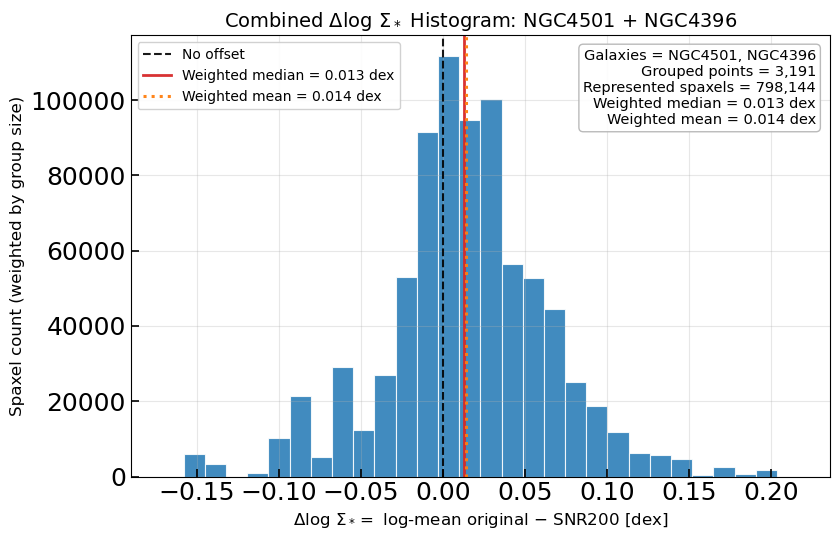

Included galaxies:
  NGC4501: 643,053 spaxels, 3,120 grouped points
  NGC4396: 155,091 spaxels, 71 grouped points


In [23]:
# ------------------------------------------------------------------
# COMBINED DELTA LOG SIGMA* HISTOGRAM FOR NGC4501 + NGC4396
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if 'matched' not in globals():
    raise RuntimeError('Run the previous mass-comparison cell first so `matched` is defined.')

def weighted_median(values, weights):
    order = np.argsort(values)
    values_sorted = values[order]
    weights_sorted = weights[order]
    cumulative = np.cumsum(weights_sorted)
    cutoff = 0.5 * np.sum(weights_sorted)
    return values_sorted[np.searchsorted(cumulative, cutoff, side='left')]

selected_galaxies = ['NGC4501', 'NGC4396']
selected_items = [item for item in matched if item['gal'] in selected_galaxies]
missing_selected = [gal for gal in selected_galaxies if gal not in {item['gal'] for item in selected_items}]
if missing_selected:
    raise FileNotFoundError(f'Missing matched data for: {", ".join(missing_selected)}')

delta_values = np.concatenate([
    item['original_log_mean'] - item['snr200_mass']
    for item in selected_items
])
delta_weights = np.concatenate([
    item['group_counts'].astype(float)
    for item in selected_items
])

good = np.isfinite(delta_values) & np.isfinite(delta_weights) & (delta_weights > 0)
delta_values = delta_values[good]
delta_weights = delta_weights[good]

if delta_values.size == 0:
    raise RuntimeError('No finite Δlog Σ* values found for the selected galaxies.')

n_bins = min(30, max(16, int(np.sqrt(delta_values.size))))
delta_min = float(np.min(delta_values))
delta_max = float(np.max(delta_values))
pad = 0.05 * (delta_max - delta_min if delta_max > delta_min else 1.0)
bin_edges = np.linspace(delta_min - pad, delta_max + pad, n_bins + 1)

weighted_mean = float(np.average(delta_values, weights=delta_weights))
weighted_med = float(weighted_median(delta_values, delta_weights))
represented_spaxels = int(np.sum(delta_weights))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(
    delta_values,
    bins=bin_edges,
    weights=delta_weights,
    color='tab:blue',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
)
ax.axvline(0.0, color='k', linestyle='--', linewidth=1.5, alpha=0.9, label='No offset')
ax.axvline(weighted_med, color='tab:red', linestyle='-', linewidth=2.0, alpha=0.95, label=f'Weighted median = {weighted_med:.3f} dex')
ax.axvline(weighted_mean, color='tab:orange', linestyle=':', linewidth=2.2, alpha=0.95, label=f'Weighted mean = {weighted_mean:.3f} dex')
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'Δlog $\Sigma_* =$ log-mean original $-$ SNR200 [dex]', fontsize=12)
ax.set_ylabel('Spaxel count (weighted by group size)', fontsize=12)
ax.set_title(r'Combined Δlog $\Sigma_*$ Histogram: NGC4501 + NGC4396', fontsize=14)

summary_text = (
    f'Galaxies = {", ".join(selected_galaxies)}\n'
    f'Grouped points = {delta_values.size:,}\n'
    f'Represented spaxels = {represented_spaxels:,}\n'
    f'Weighted median = {weighted_med:.3f} dex\n'
    f'Weighted mean = {weighted_mean:.3f} dex'
)
ax.text(
    0.98,
    0.97,
    summary_text,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10.5,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='0.7'),
)

ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
plt.tight_layout()

hist_output_dir = Path(output_dir) if 'output_dir' in globals() else Path('.')
plt.savefig(hist_output_dir / 'delta_logsigma_hist_ngc4501_ngc4396_combined.png', dpi=600, bbox_inches='tight')
plt.savefig(hist_output_dir / 'delta_logsigma_hist_ngc4501_ngc4396_combined.pdf', bbox_inches='tight')
plt.show()

print('Included galaxies:')
for item in selected_items:
    print(
        f"  {item['gal']}: {item['spaxel_count']:,} spaxels, "
        f"{len(item['snr200_mass']):,} grouped points"
    )


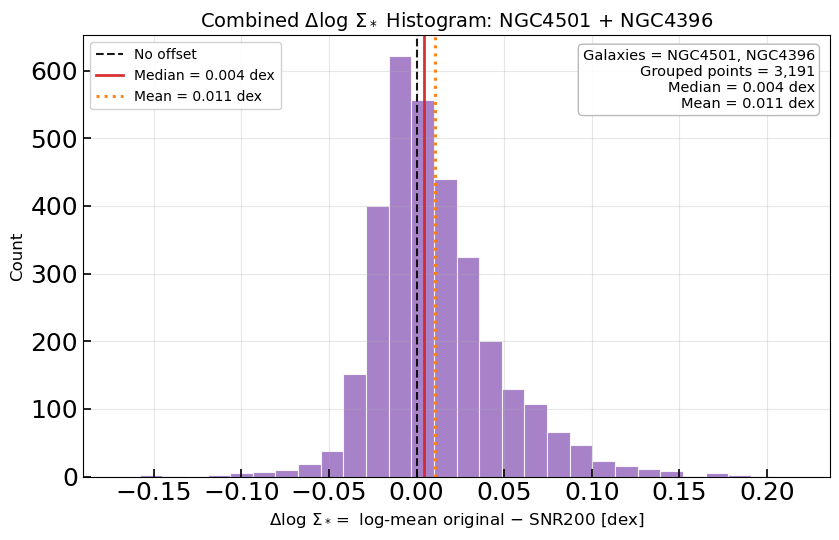

Included galaxies (unweighted histogram):
  NGC4501: 3,120 grouped points
  NGC4396: 71 grouped points


In [24]:
# ------------------------------------------------------------------
# COMBINED DELTA LOG SIGMA* HISTOGRAM FOR NGC4501 + NGC4396
# UNWEIGHTED BY GROUP SIZE
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

if 'matched' not in globals():
    raise RuntimeError('Run the mass-comparison cell first so `matched` is defined.')

selected_galaxies_unweighted = ['NGC4501', 'NGC4396']
selected_items_unweighted = [item for item in matched if item['gal'] in selected_galaxies_unweighted]
missing_selected_unweighted = [
    gal for gal in selected_galaxies_unweighted
    if gal not in {item['gal'] for item in selected_items_unweighted}
]
if missing_selected_unweighted:
    raise FileNotFoundError(f'Missing matched data for: {", ".join(missing_selected_unweighted)}')

delta_values_unweighted = np.concatenate([
    item['original_log_mean'] - item['snr200_mass']
    for item in selected_items_unweighted
])
delta_values_unweighted = delta_values_unweighted[np.isfinite(delta_values_unweighted)]

if delta_values_unweighted.size == 0:
    raise RuntimeError('No finite Δlog Σ* values found for the selected galaxies.')

n_bins_unweighted = min(30, max(16, int(np.sqrt(delta_values_unweighted.size))))
delta_min_unweighted = float(np.min(delta_values_unweighted))
delta_max_unweighted = float(np.max(delta_values_unweighted))
pad_unweighted = 0.05 * (delta_max_unweighted - delta_min_unweighted if delta_max_unweighted > delta_min_unweighted else 1.0)
bin_edges_unweighted = np.linspace(delta_min_unweighted - pad_unweighted, delta_max_unweighted + pad_unweighted, n_bins_unweighted + 1)

mean_unweighted = float(np.mean(delta_values_unweighted))
median_unweighted = float(np.median(delta_values_unweighted))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(
    delta_values_unweighted,
    bins=bin_edges_unweighted,
    color='tab:purple',
    alpha=0.82,
    edgecolor='white',
    linewidth=0.8,
)
ax.axvline(0.0, color='k', linestyle='--', linewidth=1.5, alpha=0.9, label='No offset')
ax.axvline(median_unweighted, color='tab:red', linestyle='-', linewidth=2.0, alpha=0.95, label=f'Median = {median_unweighted:.3f} dex')
ax.axvline(mean_unweighted, color='tab:orange', linestyle=':', linewidth=2.2, alpha=0.95, label=f'Mean = {mean_unweighted:.3f} dex')
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'Δlog $\Sigma_* =$ log-mean original $-$ SNR200 [dex]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(r'Combined Δlog $\Sigma_*$ Histogram: NGC4501 + NGC4396', fontsize=14)

summary_text_unweighted = (
    f'Galaxies = {", ".join(selected_galaxies_unweighted)}\n'
    f'Grouped points = {delta_values_unweighted.size:,}\n'
    f'Median = {median_unweighted:.3f} dex\n'
    f'Mean = {mean_unweighted:.3f} dex'
)
ax.text(
    0.98,
    0.97,
    summary_text_unweighted,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10.5,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='0.7'),
)

ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

print('Included galaxies (unweighted histogram):')
for item in selected_items_unweighted:
    print(f"  {item['gal']}: {len(item['snr200_mass']):,} grouped points")


Detected HII SFR pixels: 840,842


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32712/1986439850.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


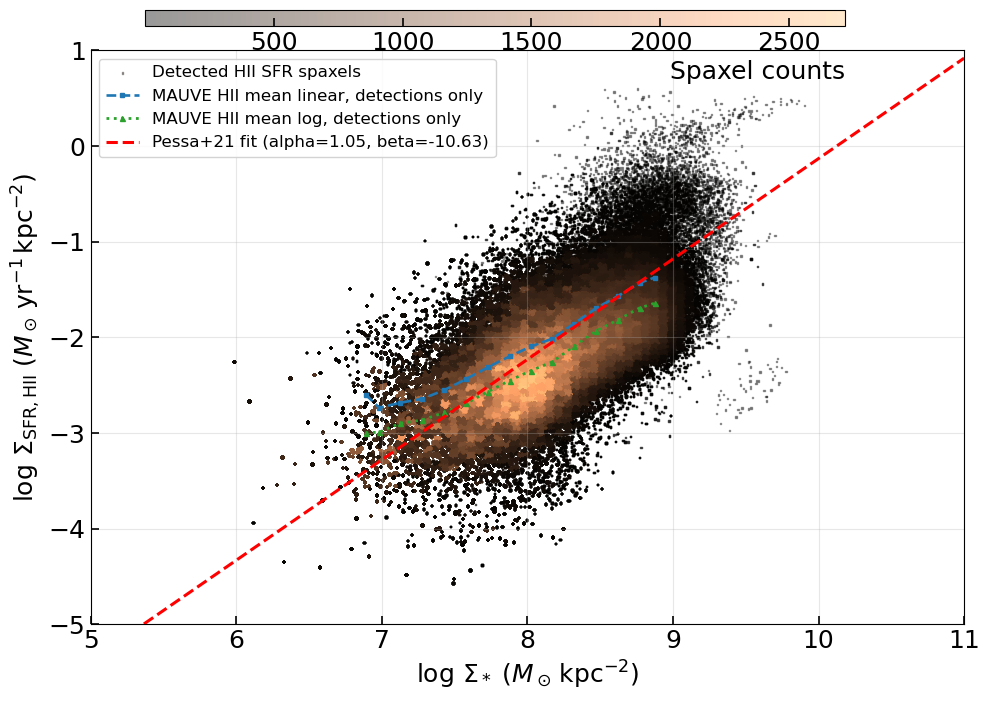

In [25]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS using detected HII SFR pixels only
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)

# 0 · discover galaxies
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]


def load_maps(gal):
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
    return sigM, sigSFR_HII


# 1 · collect finite HII-detected SFR pixels only.
all_x = []
all_y = []
galaxy_counts = {}

for gal in galaxies:
    sigM, sigSFR_HII = load_maps(gal)
    detected_hii = np.isfinite(sigM) & np.isfinite(sigSFR_HII)

    if np.any(detected_hii):
        x_det, y_det = sigM[detected_hii], sigSFR_HII[detected_hii]
        all_x.extend(x_det.ravel())
        all_y.extend(y_det.ravel())
        galaxy_counts[gal] = int(x_det.size)
    else:
        galaxy_counts[gal] = 0
        print(f"Skipping {gal}: no finite HII SFR detections")

all_x = np.asarray(all_x, dtype=float)
all_y = np.asarray(all_y, dtype=float)

if all_x.size == 0:
    raise RuntimeError("No valid HII rSFMS data found for the combined plot.")

print(f"Detected HII SFR pixels: {all_y.size:,}")

fig, ax_combined = plt.subplots(figsize=(10, 8))

# 2 · density-colored scatter of detected HII SFR pixels.
H, xedges, yedges = np.histogram2d(all_x, all_y, bins=100, range=[[5, 11], [-5, 1]])
x_idx = np.clip(np.digitize(all_x, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x,
    all_y,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="Detected HII SFR spaxels",
)

# 3 · Detected-pixel binning. With no N/D term, the linear-space mean is the
# Pessa blue-style quantity: log10(mean(Sigma_SFR,HII)) in each mass bin.
# The trend curves are restricted to the central 95% of the HII-detected
# stellar-mass distribution to avoid noisy low-/high-mass tails.
bin_width = 0.15
min_pixels_per_bin = 10
trend_lo, trend_hi = np.nanpercentile(all_x, [2.5, 97.5])
trend_population = (all_x >= trend_lo) & (all_x <= trend_hi)
trend_x_data = all_x[trend_population]
trend_y_data = all_y[trend_population]
edge_min = np.floor(np.nanmin(trend_x_data) / bin_width) * bin_width
edge_max = np.ceil(np.nanmax(trend_x_data) / bin_width) * bin_width
trend_edges = np.arange(edge_min, edge_max + 0.5 * bin_width, bin_width)

trend_x = []
mean_linear_hii = []
mean_log_hii = []

for lo, hi in zip(trend_edges[:-1], trend_edges[1:]):
    in_bin = (trend_x_data >= lo) & (trend_x_data < hi)
    if np.count_nonzero(in_bin) < min_pixels_per_bin:
        continue

    x_bin = trend_x_data[in_bin]
    y_bin = trend_y_data[in_bin]
    sfr_linear = 10 ** y_bin

    trend_x.append(np.mean(x_bin))
    mean_linear_hii.append(np.log10(np.mean(sfr_linear)))
    mean_log_hii.append(np.mean(y_bin))

trend_x = np.asarray(trend_x)
mean_linear_hii = np.asarray(mean_linear_hii)
mean_log_hii = np.asarray(mean_log_hii)

ax_combined.plot(
    trend_x,
    mean_linear_hii,
    color="tab:blue",
    linestyle="--",
    marker="s",
    markersize=3.2,
    linewidth=1.9,
    label="MAUVE HII mean linear, detections only",
    zorder=7,
)

ax_combined.plot(
    trend_x,
    mean_log_hii,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE HII mean log, detections only",
    zorder=7,
)

# 4 · Published Pessa+21 overall rSFMS fit at 100 pc. Pessa report alpha=1.05
# and intercept=-10.63 for log surface densities in kpc^-2 units.
pessa_alpha = 1.05
pessa_intercept = -10.63
x_pessa = np.linspace(5, 11, 200)
y_pessa = pessa_alpha * x_pessa + pessa_intercept
ax_combined.plot(
    x_pessa,
    y_pessa,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)

# 5 · Plot formatting.
ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(r"$\log\,\Sigma_{\mathrm{SFR,HII}}\; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$")
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(loc="upper left", ncol=1, frameon=True, framealpha=0.85)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig(output_dir / "rSFMS_combined.png", dpi=600, bbox_inches="tight")
plt.savefig(output_dir / "rSFMS_combined.pdf", bbox_inches="tight")
plt.show()
